# **Machine Learning-Based Prediction of Wine Quality Using Physicochemical Properties**

# **Problem Statement**

Wine quality assessment traditionally relies on sensory evaluation performed by expert wine tasters. Although this approach provides valuable insights, it is subjective, time-consuming, resource-intensive, and may produce inconsistent results due to differences in human perception. As wine production continues to increase worldwide, wineries require objective and data-driven approaches that can support consistent quality assessment while reducing dependence on manual evaluation.

Machine learning offers an opportunity to model the complex relationships between measurable physicochemical properties and wine quality scores. By learning patterns from historical laboratory measurements, predictive models can estimate wine quality objectively and assist quality control laboratories in making faster and more consistent decisions.

The primary challenge addressed in this project is determining which machine learning regression algorithm provides the most accurate prediction of wine quality while identifying the physicochemical properties that contribute most significantly to those predictions. Developing an interpretable predictive framework can support production optimization, quality assurance, and evidence-based decision-making within the wine industry.

This study utilizes the publicly available **UCI Wine Quality Dataset**, containing physicochemical measurements of Portuguese Vinho Verde red wines. Multiple regression algorithms including **Linear Regression, Decision Tree Regression, Random Forest Regression, Gradient Boosting Regression, and Extreme Gradient Boosting (XGBoost)** will be developed, compared, and evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²)**. Model explainability techniques such as **SHAP (SHapley Additive exPlanations)** will be used to identify the most influential physicochemical properties contributing to wine quality predictions.

The findings of this study are expected to demonstrate how explainable machine learning can support objective wine quality assessment, improve production consistency, and provide actionable insights for data-driven quality management.

# **The Project Structure**

1. Problem Statement
2. Research Objectives
3. Research Questions
4. Dataset Description
5. Import Libraries
6. Load Dataset
7. Data Quality Assessment
8. Exploratory Data Analysis (EDA)
9. Data Preprocessing
10. Feature Engineering
11. Model Development
12. Model Evaluation
13. Hyperparameter Optimization
14. Model Comparison
15. Explainable AI (SHAP)
16. Business Insights & Recommendations
17. Conclusion

# **Research Objectives**

The primary objective of this study is to develop and compare multiple machine learning regression models for predicting wine quality using physicochemical properties obtained from the UCI Wine Quality Dataset.

The specific objectives are:

1. Identify the physicochemical properties that significantly influence wine quality.

2. Develop multiple machine learning regression models capable of predicting wine quality using physicochemical characteristics.

3. Compare the predictive performance of Linear Regression, Decision Tree Regression, Random Forest Regression, Gradient Boosting Regression, and XGBoost Regression.

4. Determine the best-performing regression model using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²).

5. Interpret the contribution of individual physicochemical properties using explainable artificial intelligence (XAI) techniques such as SHAP.

6. Demonstrate how explainable machine learning can support objective wine quality assessment, production optimization, and data-driven decision-making within the wine industry.


# **Research Questions**

This study seeks to answer the following research questions:

**RQ1.** Which physicochemical properties significantly influence wine quality?

**RQ2.** How accurately can machine learning regression models predict wine quality using physicochemical properties?

**RQ3.** Which machine learning regression model provides the best predictive performance for wine quality prediction?

**RQ4.** Which physicochemical properties contribute the most to the predictive performance of the best-performing machine learning model?

# **Dataset Selection Justification**

The UCI Wine Quality Dataset was selected because it provides a well-documented and widely used benchmark for evaluating machine learning methods in wine quality prediction. It contains laboratory-measured physicochemical properties and corresponding sensory quality scores for Portuguese *Vinho Verde* red wines, making it directly relevant to the study objective of predicting red wine quality using measurable chemical characteristics.

The dataset is particularly suitable for this project because it includes 11 numerical predictor variables and a clearly defined quality target, allowing consistent comparison of linear, tree-based, ensemble, and boosting regression models. Its public availability also supports transparency, reproducibility, and comparison with previous research.

The study is intentionally limited to red wine because the proposed solution is designed as a red wine quality prediction and decision-support framework. The UCI dataset therefore serves as the benchmark development dataset rather than representing every commercial red wine production environment.

A key limitation is that the model is trained and validated using a single public dataset from one wine type and production context. Its performance may therefore vary when applied to red wines from different grape varieties, regions, laboratory methods, or manufacturing conditions. The current findings should not be interpreted as universal validation across the wine industry. Future external validation should use independent laboratory measurements from commercial wineries containing the same physicochemical variables before operational deployment.

```text
Research Problem Definition
            │
            ▼
Dataset Collection
(UCI Wine Quality Dataset)
            │
            ▼
Data Quality Assessment
• Missing Value Check
• Duplicate Identification
• Data Type Verification
            │
            ▼
Data Preprocessing
• Duplicate Removal
• Train-Test Split (80:20)
• Stratified Sampling
• Feature Scaling (Linear Regression)
• Data Leakage Prevention
            │
            ▼
Exploratory Data Analysis (EDA)
• Descriptive Statistics
• Distribution Analysis
• Correlation Analysis
• Outlier Analysis
            │
            ▼
Feature Analysis
• Mutual Information
• VIF Analysis
• PCA Assessment
• Feature Importance
            │
            ▼
Baseline Model Development
• Linear Regression
• Decision Tree Regression
• Random Forest Regression
• Gradient Boosting Regression
• XGBoost Regression
            │
            ▼
Model Evaluation
• MAE
• RMSE
• R²
• Five-Fold Cross Validation
• Residual Analysis
• Actual vs Predicted Analysis
            │
            ▼
Hyperparameter Optimization
(RandomizedSearchCV)
• Decision Tree
• Random Forest
• Gradient Boosting
• XGBoost
            │
            ▼
Optimized Model Comparison
            │
            ▼
Final Model Selection
(Tuned Random Forest)
            │
            ▼
SHAP Explainability
• SHAP Summary Plot
• SHAP Feature Importance
• SHAP Dependence Analysis
            │
            ▼
Research Findings
Business Interpretation
Recommendations
```

# **Import Required Libraries**

The following libraries are imported to support data manipulation, visualization, exploratory data analysis, machine learning model development, model evaluation, hyperparameter optimization, and model explainability.

In [1]:
# ============================================================
# QM640 Data Analytics Capstone
# Import Required Libraries
# ============================================================

# -------------------------------
# General Libraries
# -------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# -------------------------------
# Visualization
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Figure settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,5)

# -------------------------------
# Machine Learning
# -------------------------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -------------------------------
# Explainable AI
# -------------------------------
import shap

# -------------------------------
# Utility
# -------------------------------
import os

print("All libraries imported successfully.")

All libraries imported successfully.


### **Observation**

All required Python libraries were imported successfully, confirming that the computational environment is correctly configured for data preprocessing, exploratory data analysis (EDA), machine learning model development, hyperparameter optimization, model evaluation, and SHAP explainability analysis. Successful library initialization ensures that the subsequent workflow can be executed without dependency-related issues.

# **Connect the Colab Environment to the GitHub Repository**

The project repository is cloned into the Google Colab runtime so that the notebook can access the raw dataset and later save processed files, figures, and outputs using the same project structure maintained in GitHub.

In [2]:
# ============================================================
# Clone the GitHub Repository into Google Colab
# ============================================================

import os

REPO_URL = "https://github.com/MBG0903/QM640-Wine-Quality-Capstone.git"
REPO_NAME = "QM640-Wine-Quality-Capstone"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}
    print("Repository cloned successfully.")
else:
    print("Repository already exists in the Colab session.")

Cloning into 'QM640-Wine-Quality-Capstone'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 55 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.67 MiB | 9.02 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Repository cloned successfully.


### **Observation**

The GitHub repository was cloned successfully into the Google Colab environment, enabling direct access to the project files, datasets, notebooks, and supporting resources. Integrating GitHub with the development environment ensures version control, reproducibility, and centralized management of all project artifacts.

### **Interpretation**

Using GitHub throughout the project promotes transparent and reproducible research practices by maintaining a single source of truth for the code, raw and processed datasets, and documentation. It also simplifies collaboration, progress tracking, and future updates to the project.

In [3]:
# ============================================================
# Set the Project Working Directory
# ============================================================

PROJECT_PATH = f"/content/{REPO_NAME}"
os.chdir(PROJECT_PATH)

print("Current working directory:")
print(os.getcwd())

Current working directory:
/content/QM640-Wine-Quality-Capstone


### **Observation**

The project working directory was successfully configured to the cloned GitHub repository, ensuring that all project files, datasets, notebooks, and generated outputs are accessed from a consistent and version-controlled location. This establishes a reliable environment for executing the complete data analytics workflow.

In [4]:
# ============================================================
# Load the Raw Wine Quality Dataset
# ============================================================

DATA_PATH = "data/raw/winequality-red.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (1599, 12)


### **Observation**

The raw UCI Red Wine Quality dataset was successfully loaded into the analysis environment. The dataset contains **1,599 observations** and **12 variables**, providing a sufficiently large and structured dataset for exploratory data analysis, data preprocessing, and the development of machine learning regression models for wine quality prediction.

# **1. Dataset Overview**

This section provides an initial overview of the Wine Quality dataset, including its dimensions, variables, data types, and sample observations. Understanding the dataset structure is an essential first step before assessing data quality and performing exploratory data analysis.

In [5]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nNumber of Records (Rows): {df.shape[0]}")
print(f"Number of Variables (Columns): {df.shape[1]}")

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

print("\nFirst Five Records:")
display(df.head())

DATASET OVERVIEW

Number of Records (Rows): 1599
Number of Variables (Columns): 12

Column Names:
 1. fixed acidity
 2. volatile acidity
 3. citric acid
 4. residual sugar
 5. chlorides
 6. free sulfur dioxide
 7. total sulfur dioxide
 8. density
 9. pH
10. sulphates
11. alcohol
12. quality

First Five Records:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### **Observation**

The dataset consists of **1,599 wine samples** described by **11 physicochemical attributes** and one target variable (**quality**). The first five records confirm that the dataset has been loaded correctly, the variables are appropriately structured, and the target variable is available for supervised machine learning. The dataset is therefore ready for data quality assessment and exploratory data analysis.

In [6]:
# ============================================================
# Dataset Structure
# ============================================================

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

df.info()

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### **Observation**

The dataset structure confirms that all **12 variables contain complete observations with no missing values**. The predictor variables are stored as numerical (float) data types, while the target variable (**quality**) is represented as an integer. This consistent data structure is well suited for statistical analysis and machine learning, reducing the need for extensive data type conversions or missing value imputation.

In [7]:
# ============================================================
# Dataset Summary Table
# ============================================================

summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Missing Values": df.isnull().sum().values
})

display(summary)

,Variable,Data Type,Non-Null Count,Missing Values
0,fixed acidity,float64,1599,0
1,volatile acidity,float64,1599,0
2,citric acid,float64,1599,0
3,residual sugar,float64,1599,0
4,chlorides,float64,1599,0
5,free sulfur dioxide,float64,1599,0
6,total sulfur dioxide,float64,1599,0
7,density,float64,1599,0
8,pH,float64,1599,0
9,sulphates,float64,1599,0


### **Observation**

The data quality assessment confirms that all variables contain **1,599 non-null observations** with **no missing values**. As a result, no missing value imputation is required, allowing the analysis to proceed directly to duplicate detection, exploratory data analysis, and feature preprocessing without introducing bias from missing data treatment.

## **Data Quality Assessment**

Before developing machine learning models, it is essential to evaluate the quality of the dataset. This section examines missing values, duplicate records, and basic data integrity to ensure that the dataset is suitable for predictive modeling. Any issues identified during this assessment will be addressed before exploratory data analysis and model development.

In [8]:
# ============================================================
# Check Missing Values
# ============================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().mean()*100).round(2)
})

display(missing)

,Missing Values,Percentage (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


### **Observation**

The missing value analysis confirms that **all variables have 0% missing data**, indicating a complete dataset. This eliminates the need for imputation techniques and ensures that all 1,599 wine samples can be retained for subsequent preprocessing, model training, and evaluation without any loss of information.

In [9]:
# ============================================================
# Check Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate records: 240
Percentage of duplicates: 15.01%


### **Observation**

A total of **240 duplicate records (15.01%)** were identified in the dataset, indicating that a notable proportion of observations were repeated. Removing these duplicates helps eliminate redundant information, reduces potential bias during model training, and ensures that the predictive models are developed using unique wine samples, thereby improving the reliability and generalizability of the results.

In [10]:
# ============================================================
# Investigate Duplicate Records
# ============================================================

duplicate_rows = df[df.duplicated(keep=False)]

print(f"Duplicate observations (including first occurrence): {duplicate_rows.shape[0]}")

display(duplicate_rows.head(20))

Duplicate observations (including first occurrence): 460


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
39,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
64,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5


### **Observation**

The duplicate inspection confirms that the identified duplicate records are exact repetitions across all predictor variables and the target variable. A total of **460 observations** belong to duplicate groups, resulting in **240 redundant records** after retaining the first occurrence of each unique sample. This validates the decision to remove duplicate entries while preserving one representative record from each group for subsequent analysis.

In [11]:
# Number of unique duplicate groups

duplicate_groups = duplicate_rows.groupby(list(df.columns)).size().reset_index(name="Frequency")

duplicate_groups = duplicate_groups.sort_values(
    "Frequency",
    ascending=False
)

display(duplicate_groups.head(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Frequency
22,6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,6,4
81,7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,6,4
63,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,4
52,7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,4
40,7.0,0.690,0.07,2.5,0.091,15.0,21.0,0.99572,3.38,0.60,11.3,6,3
5,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,3
60,7.2,0.630,0.00,1.9,0.097,14.0,38.0,0.99675,3.37,0.58,9.0,6,3
39,7.0,0.650,0.02,2.1,0.066,8.0,25.0,0.99720,3.47,0.67,9.5,6,3
12,6.4,0.640,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8,5,3
131,8.3,0.650,0.10,2.9,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,3


### **Observations**

During data quality assessment, 240 duplicate observations (15.01% of the dataset) were identified. Examination confirmed that these records contained identical predictor values and identical target labels. Because duplicate observations do not contribute additional information and may bias model learning by disproportionately weighting repeated samples, they were removed prior to model development. The cleaned dataset contained 1,359 unique observations, which remained substantially larger than the minimum required sample size calculated using Cochran's formula.

## **Duplicate Handling Strategy**

Duplicate records were identified before model development because repeated observations can bias the learning process by over-representing specific wine samples. Since the duplicates in this dataset are exact repetitions across all predictor variables and the target variable, only the first occurrence of each duplicate group is retained while the remaining records are removed. This preserves all unique information without introducing sampling bias.

In [12]:
# ============================================================
# Remove Duplicate Records
# ============================================================

df_clean = df.drop_duplicates().reset_index(drop=True)

print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

print(f"Duplicate records removed: {df.shape[0] - df_clean.shape[0]}")

Original Dataset Shape : (1599, 12)
Cleaned Dataset Shape  : (1359, 12)
Duplicate records removed: 240


### **Observation**

After removing duplicate records, the dataset size was reduced from **1,599** to **1,359 unique wine samples**, eliminating **240 redundant observations** while preserving all unique information. This preprocessing step improves data quality by preventing repeated samples from disproportionately influencing the learning process, resulting in a more reliable and generalizable machine learning model.

In [13]:
# ============================================================
# Save Cleaned Dataset
# ============================================================

import os

os.makedirs("data/processed", exist_ok=True)

output_path = "data/processed/winequality-red-clean.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved successfully.")
print(f"Location: {output_path}")
print(f"Shape: {df_clean.shape}")

Processed dataset saved successfully.
Location: data/processed/winequality-red-clean.csv
Shape: (1359, 12)


### **Observation**

The cleaned dataset containing **1,359 unique wine samples** was successfully saved to the project's processed data directory. Maintaining a separate processed dataset preserves the integrity of the original raw data while ensuring that all subsequent analyses and model development are performed on a consistent, reproducible, and version-controlled dataset.

In [14]:
# ============================================================
# Unique Values
# ============================================================

unique_values = pd.DataFrame({
    "Variable": df_clean.columns,
    "Unique Values": df.nunique().values
})

display(unique_values)

,Variable,Unique Values
0,fixed acidity,96
1,volatile acidity,143
2,citric acid,80
3,residual sugar,91
4,chlorides,153
5,free sulfur dioxide,60
6,total sulfur dioxide,144
7,density,436
8,pH,89
9,sulphates,96


### **Observation**

The dataset exhibits a good level of variability across the predictor variables, with the number of unique values ranging from **60** to **436**, indicating sufficient diversity for regression modelling. The target variable (**quality**) contains **six distinct quality ratings**, confirming that the study aims to predict wine quality across multiple ordinal levels rather than performing a binary classification task.

In [15]:
# ============================================================
# Descriptive Statistics
# ============================================================

display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


### **Observation**

The descriptive statistics indicate that the cleaned dataset exhibits substantial variability across the physicochemical properties of red wine, providing a strong basis for predictive modelling. The target variable (**quality**) has a mean score of **5.62** (SD = **0.82**) with values ranging from **3 to 8**, suggesting that most wine samples are concentrated around average quality levels. Additionally, the noticeable differences between the minimum and maximum values of several variables (e.g., alcohol, sulphates, and total sulfur dioxide) indicate the presence of diverse wine characteristics, warranting further distribution and outlier analysis.

# **2. Exploratory Data Analysis (EDA)**

## **2.1 - Target Variable Analysis**

The target variable (**quality**) represents the wine quality score assigned by expert tasters. Before developing predictive models, it is important to understand the distribution of the target variable, identify the most common quality levels, and assess whether class imbalance may influence model performance.

In [16]:
# ============================================================
# Distribution of Wine Quality Scores
# ============================================================

quality_distribution = (
    df_clean["quality"]
    .value_counts()
    .sort_index()
    .reset_index()
)

quality_distribution.columns = ["Quality Score", "Frequency"]
quality_distribution["Percentage (%)"] = (
    quality_distribution["Frequency"] /
    quality_distribution["Frequency"].sum() * 100
).round(2)

display(quality_distribution)

,Quality Score,Frequency,Percentage (%)
0,3,10,0.74
1,4,53,3.90
2,5,577,42.46
3,6,535,39.37
4,7,167,12.29
5,8,17,1.25


### **Observation**

The target variable (**wine quality**) exhibits an imbalanced distribution, with approximately **81.8%** of the samples belonging to quality scores **5 (42.46%)** and **6 (39.37%)**. In contrast, extreme quality scores (3, 4, and 8) are relatively underrepresented. This indicates that the developed regression models will primarily learn patterns associated with average-quality wines, while predictions for rare quality levels may be comparatively less accurate. This class imbalance should be considered when interpreting model performance and generalizability.

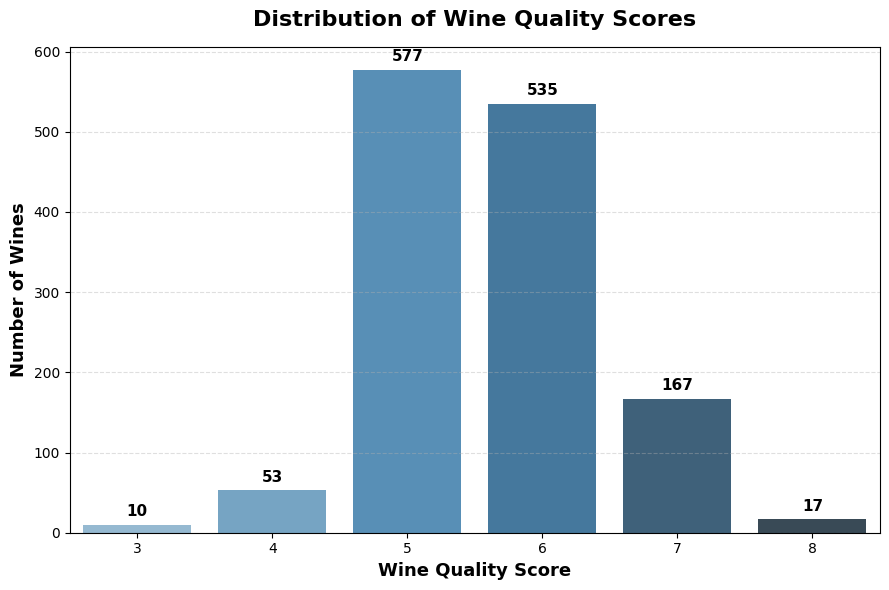

In [17]:
# ============================================================
# Distribution of Wine Quality Scores
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count the quality scores
quality_counts = (
    df_clean["quality"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=quality_counts.index,
    y=quality_counts.values,
    palette="Blues_d"
)

# Add data labels
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0,4),
        textcoords='offset points'
    )

# Titles and labels
plt.title(
    "Distribution of Wine Quality Scores",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Wine Quality Score",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Number of Wines",
    fontsize=13,
    fontweight='bold'
)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### **Observation**

The distribution of wine quality scores shows that the dataset is centered around **quality scores 5 and 6**, while very low (3–4) and very high (8) quality wines occur infrequently. This indicates that the dataset predominantly represents average-quality red wines, which is consistent with real-world wine production. The observed class imbalance should be considered when interpreting model predictions, particularly for the less frequent quality scores.

In [18]:
# ============================================================
# Summary Statistics of Target Variable
# ============================================================

display(df_clean["quality"].describe())

,quality
count,1359.000000
mean,5.623252
std,0.823578
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


### **Observations**

The cleaned dataset contains 1,359 unique wine samples, with quality scores ranging from 3 to 8. The average quality score is 5.62, while the median is 6, indicating that most wines are rated around the average quality level. The relatively low standard deviation (0.82) suggests limited variation in wine quality across the dataset. Furthermore, the interquartile range (5-6) indicates that the majority of wines are concentrated within a narrow quality band. This concentration is consistent with the distribution observed in the bar chart, where quality scores of 5 and 6 dominate the dataset. The relatively small number of observations with extreme quality scores (3, 4, 7, and 8) may make these quality levels more challenging for predictive models to estimate accurately. Consequently, model evaluation should consider not only overall prediction accuracy but also the model's ability to generalize across less frequently occurring quality scores.

## **2.2 - Univariate Analysis of Predictor Variables**

This section examines the distribution of each physicochemical property independently. Understanding the distribution, central tendency, variability, skewness, and kurtosis of predictor variables provides valuable insights into data characteristics and helps identify variables that may require transformation or special treatment before model development.

In [19]:
# ============================================================
# Skewness and Kurtosis Analysis
# ============================================================

distribution_summary = pd.DataFrame({
    "Mean": df_clean.mean(),
    "Median": df_clean.median(),
    "Standard Deviation": df_clean.std(),
    "Skewness": df_clean.skew(),
    "Kurtosis": df_clean.kurtosis()
})

display(distribution_summary.round(3))

,Mean,Median,Standard Deviation,Skewness,Kurtosis
fixed acidity,8.311,7.900,1.737,0.941,1.050
volatile acidity,0.529,0.520,0.183,0.729,1.249
citric acid,0.272,0.260,0.196,0.313,-0.789
residual sugar,2.523,2.200,1.352,4.548,29.365
chlorides,0.088,0.079,0.049,5.502,38.625
free sulfur dioxide,15.893,14.000,10.447,1.227,1.893
total sulfur dioxide,46.826,38.000,33.409,1.540,4.042
density,0.997,0.997,0.002,0.045,0.831
pH,3.310,3.310,0.155,0.232,0.880
sulphates,0.659,0.620,0.171,2.407,11.102


### **Observation**

The univariate statistical analysis indicates that most variables exhibit **positive skewness**, suggesting the presence of higher-value observations and potential outliers. Variables such as **residual sugar**, **chlorides**, and **sulphates** show relatively high skewness and kurtosis, indicating heavy-tailed distributions that warrant further investigation during outlier analysis. In contrast, variables such as **density**, **pH**, and **quality** are closer to a symmetric distribution, making them more stable for predictive modelling.

In [20]:
# ============================================================
# Distribution Classification
# ============================================================

def classify_kurtosis(x):

    if x < -1:
        return "Platykurtic"

    elif x <= 1:
        return "Mesokurtic"

    else:
        return "Leptokurtic"

distribution_summary["Kurtosis Type"] = (
    distribution_summary["Kurtosis"]
    .apply(classify_kurtosis)
)

display(distribution_summary.round(3))

,Mean,Median,Standard Deviation,Skewness,Kurtosis,Kurtosis Type
fixed acidity,8.311,7.900,1.737,0.941,1.050,Leptokurtic
volatile acidity,0.529,0.520,0.183,0.729,1.249,Leptokurtic
citric acid,0.272,0.260,0.196,0.313,-0.789,Mesokurtic
residual sugar,2.523,2.200,1.352,4.548,29.365,Leptokurtic
chlorides,0.088,0.079,0.049,5.502,38.625,Leptokurtic
free sulfur dioxide,15.893,14.000,10.447,1.227,1.893,Leptokurtic
total sulfur dioxide,46.826,38.000,33.409,1.540,4.042,Leptokurtic
density,0.997,0.997,0.002,0.045,0.831,Mesokurtic
pH,3.310,3.310,0.155,0.232,0.880,Mesokurtic
sulphates,0.659,0.620,0.171,2.407,11.102,Leptokurtic


### **Observation**

The kurtosis analysis indicates that several variables, including **residual sugar, chlorides, sulphates, fixed acidity, volatile acidity, free sulfur dioxide, and total sulfur dioxide**, are **leptokurtic**, suggesting the presence of heavier tails and a higher likelihood of extreme observations. In contrast, **citric acid, density, pH, alcohol, and quality** exhibit a more moderate (mesokurtic) distribution. These findings support conducting a detailed outlier analysis before model development to understand the influence of extreme values on predictive performance.

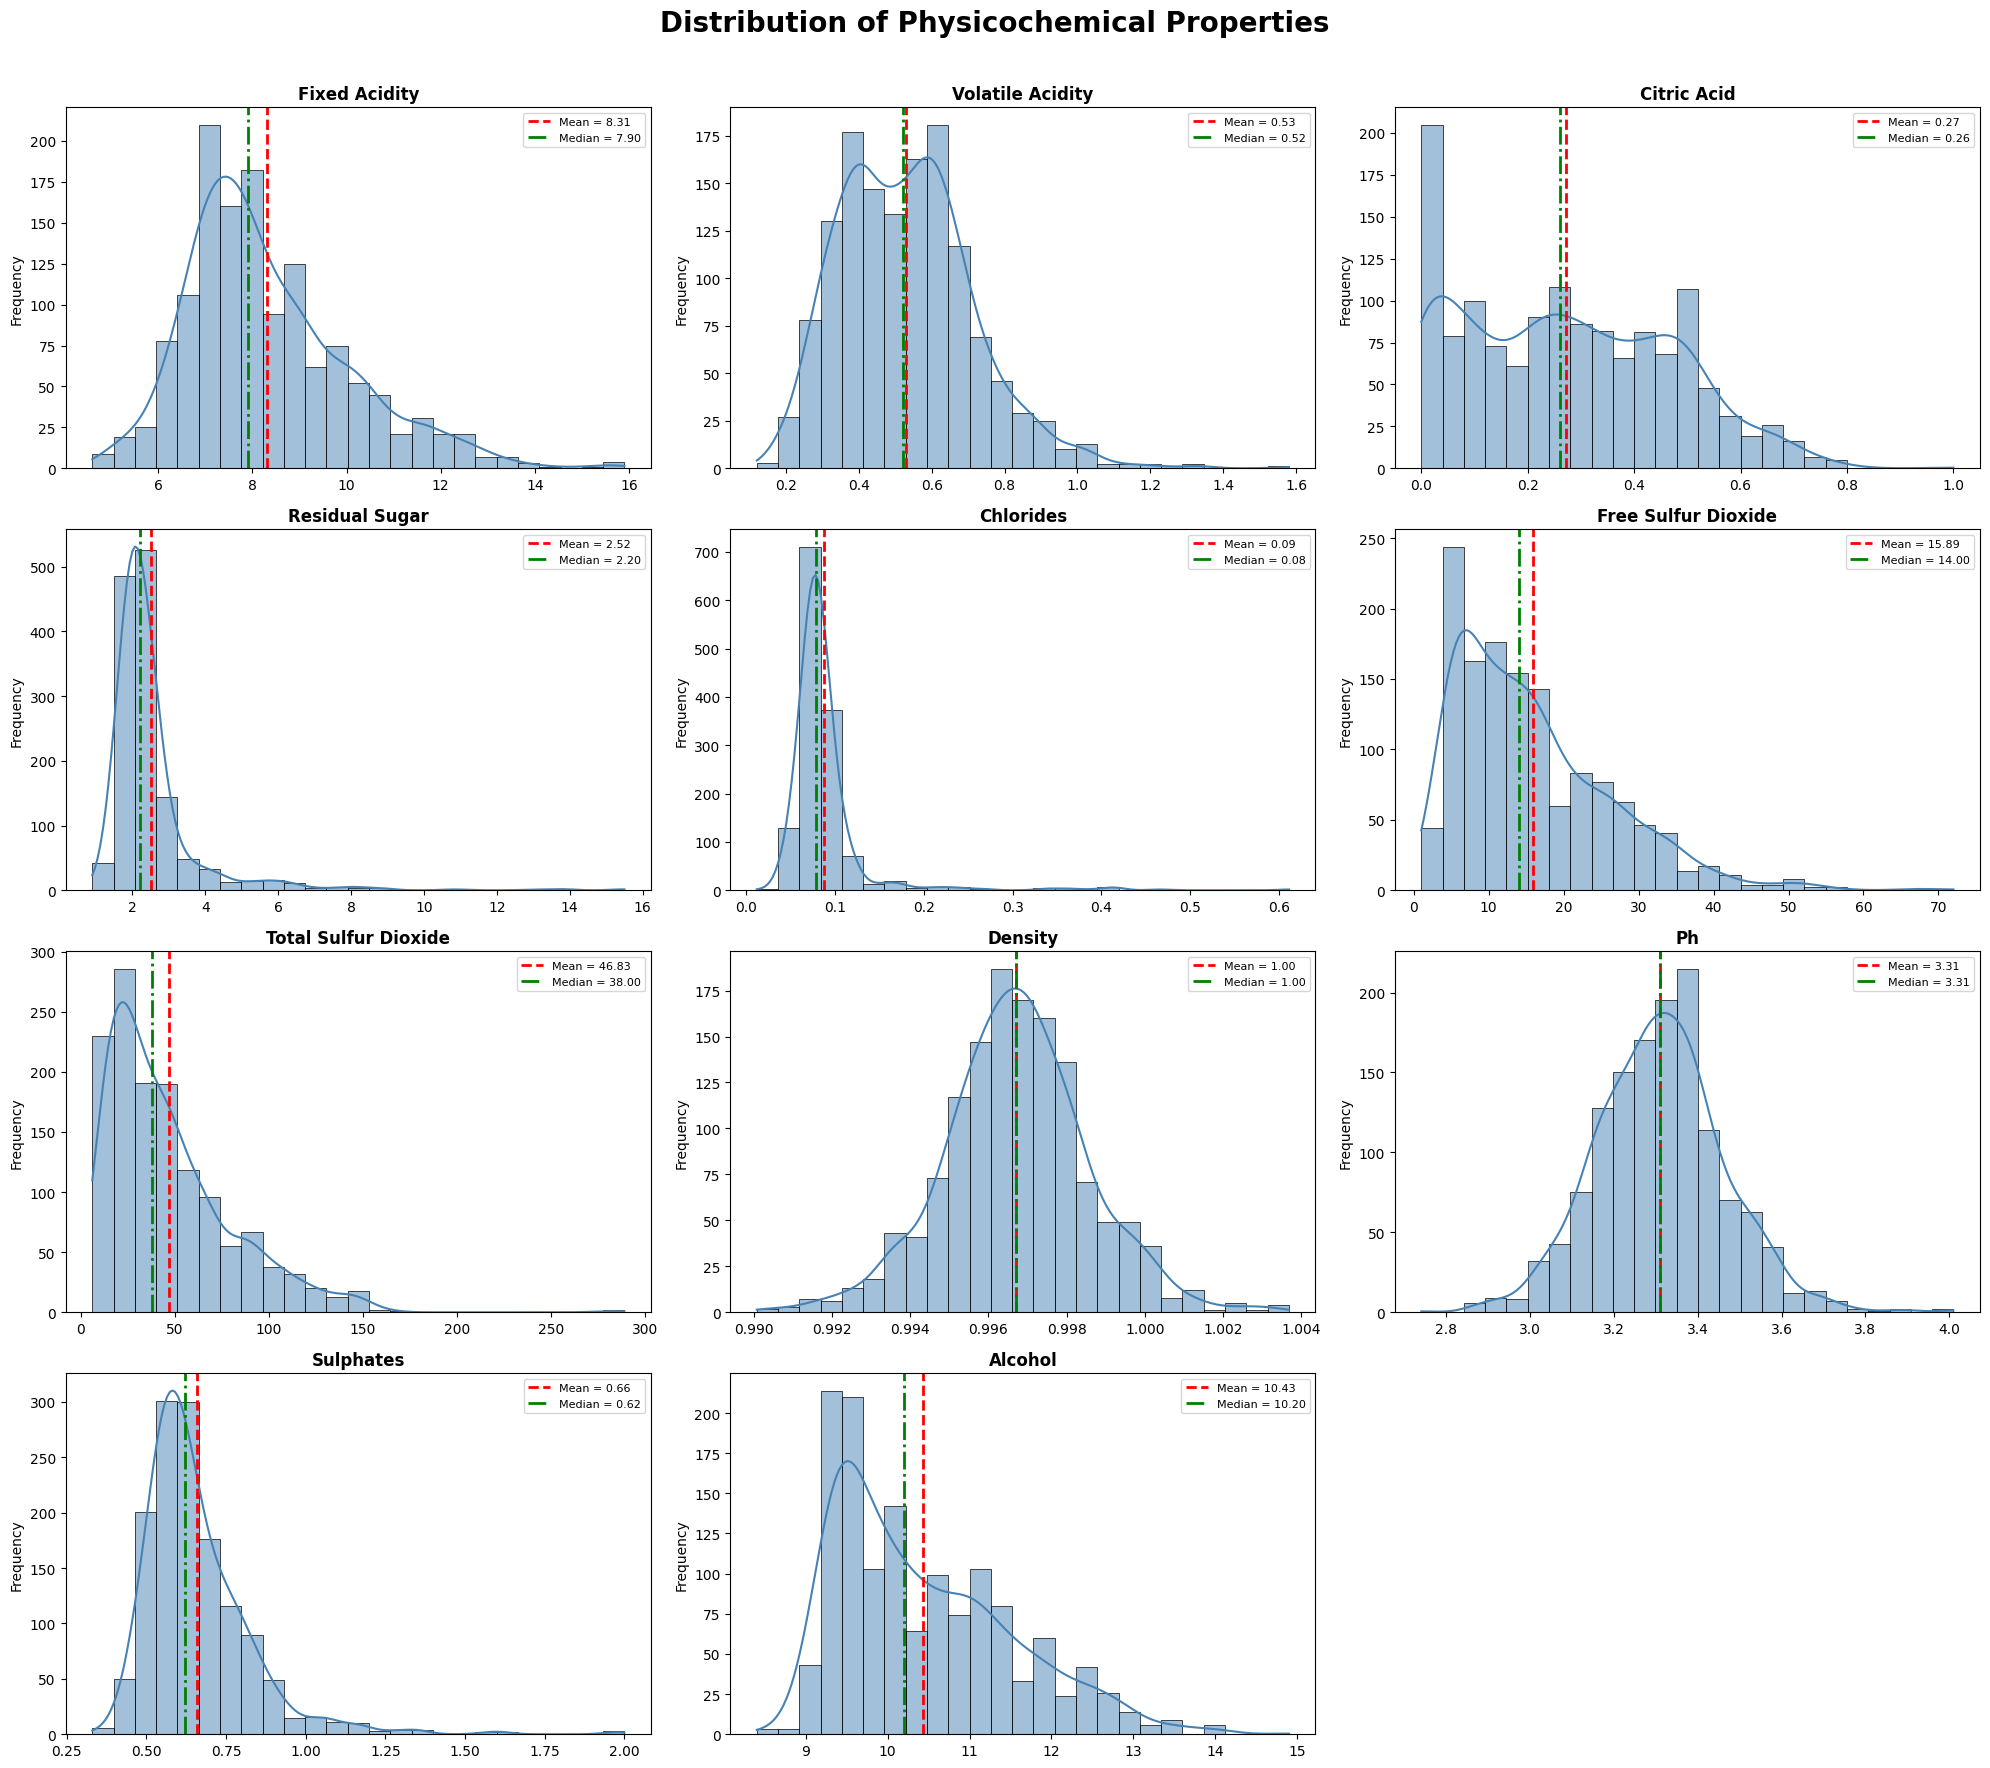

In [21]:
# ============================================================
# Publication Quality Histograms
# ============================================================

predictor_columns = df_clean.drop(columns="quality").columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(20,18)
)

axes = axes.flatten()

for i, column in enumerate(predictor_columns):

    ax = axes[i]

    sns.histplot(
        df_clean[column],
        bins=25,
        kde=True,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    mean = df_clean[column].mean()
    median = df_clean[column].median()

    ax.axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.2f}"
    )

    ax.axvline(
        median,
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Median = {median:.2f}"
    )

    ax.set_title(
        column.title(),
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    ax.legend(fontsize=8)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Distribution of Physicochemical Properties",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

### **Observation**

The distribution plots indicate that the physicochemical properties exhibit varying distributional characteristics. Variables such as **density** and **pH** are approximately normally distributed, whereas **residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, sulphates, and alcohol** display positive skewness with long right tails, suggesting the presence of extreme observations. The differences between the mean and median for several variables further confirm asymmetric distributions. These findings justify conducting a detailed outlier analysis and support the use of robust tree-based models, which are less sensitive to non-normal feature distributions.

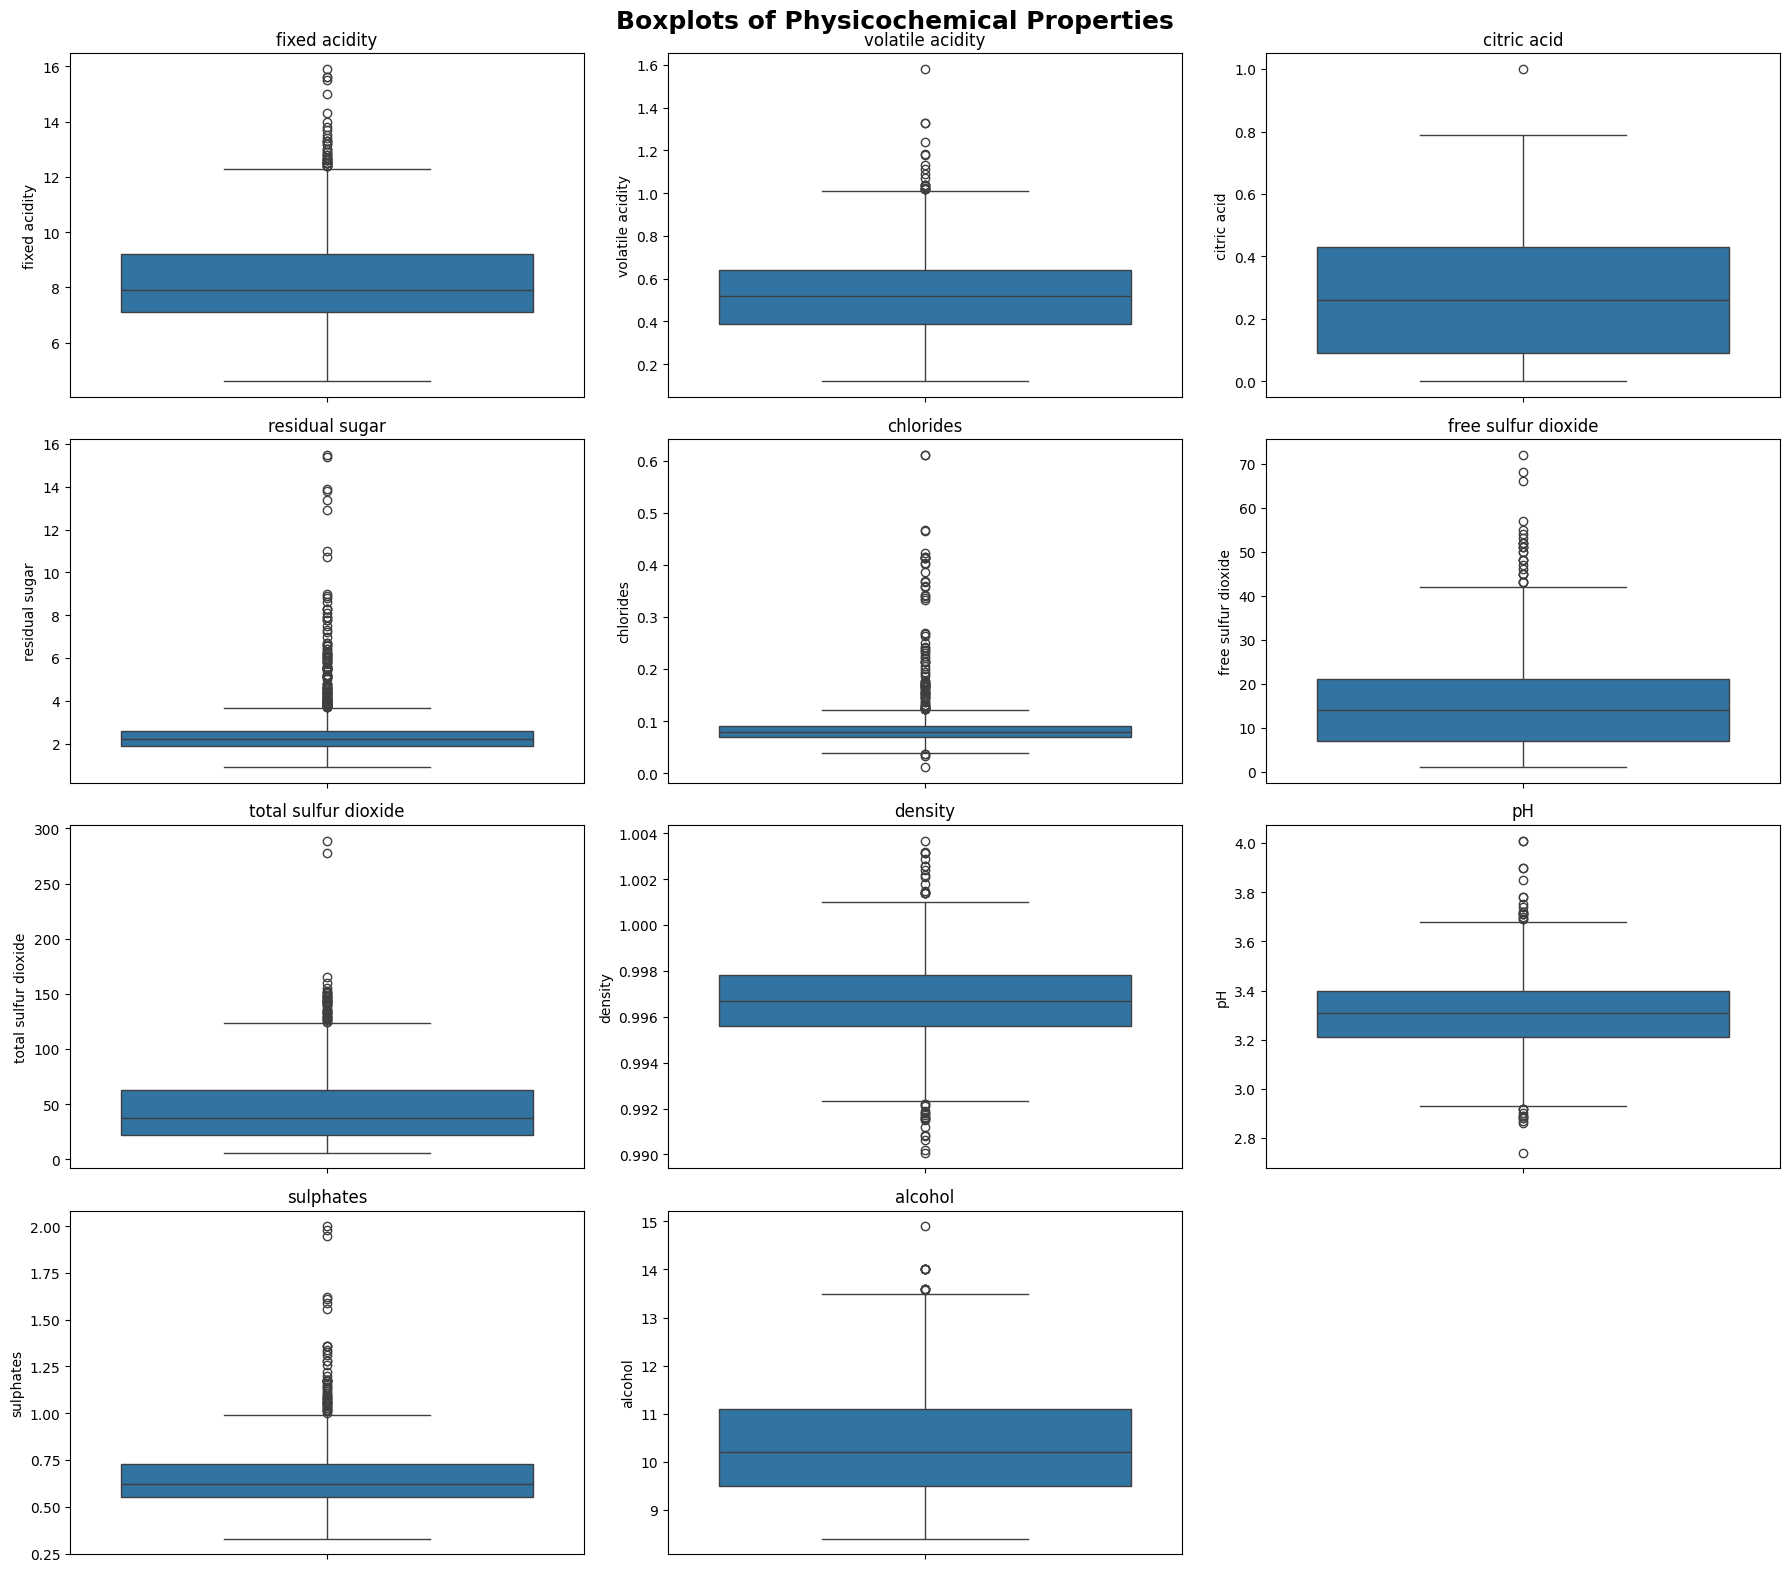

In [22]:
# ============================================================
# Boxplots of Predictor Variables
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(18,16))

axes = axes.flatten()

for i, column in enumerate(predictor_columns):

    sns.boxplot(
        y=df_clean[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Boxplots of Physicochemical Properties",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### **Observation**

The boxplots reveal the presence of outliers in several physicochemical variables, particularly **residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, sulphates, alcohol, fixed acidity, and volatile acidity**. These observations are consistent with the positive skewness identified during the univariate analysis and indicate that a subset of wine samples possesses unusually high or low chemical measurements.

## **2.3 Correlation Analysis**

Correlation analysis is performed to examine the strength and direction of the linear relationships among the physicochemical properties and between each predictor variable and the target variable (**quality**). Understanding these relationships helps identify influential variables, detect multicollinearity, and support feature selection for predictive modeling.

In [23]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation_matrix = df_clean.corr(numeric_only=True)

display(correlation_matrix.round(2))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.26,0.67,0.11,0.09,-0.14,-0.10,0.67,-0.69,0.19,-0.06,0.12
volatile acidity,-0.26,1.00,-0.55,-0.00,0.06,-0.02,0.07,0.02,0.25,-0.26,-0.20,-0.40
citric acid,0.67,-0.55,1.00,0.14,0.21,-0.05,0.05,0.36,-0.55,0.33,0.11,0.23
residual sugar,0.11,-0.00,0.14,1.00,0.03,0.16,0.20,0.32,-0.08,-0.01,0.06,0.01
chlorides,0.09,0.06,0.21,0.03,1.00,0.00,0.05,0.19,-0.27,0.39,-0.22,-0.13
free sulfur dioxide,-0.14,-0.02,-0.05,0.16,0.00,1.00,0.67,-0.02,0.06,0.05,-0.08,-0.05
total sulfur dioxide,-0.10,0.07,0.05,0.20,0.05,0.67,1.00,0.08,-0.08,0.04,-0.22,-0.18
density,0.67,0.02,0.36,0.32,0.19,-0.02,0.08,1.00,-0.36,0.15,-0.50,-0.18
pH,-0.69,0.25,-0.55,-0.08,-0.27,0.06,-0.08,-0.36,1.00,-0.21,0.21,-0.06
sulphates,0.19,-0.26,0.33,-0.01,0.39,0.05,0.04,0.15,-0.21,1.00,0.09,0.25


### **Observation**

The correlation matrix indicates that most predictor variables exhibit weak to moderate linear relationships, suggesting that each feature contributes unique information to the dataset. With respect to the target variable (**quality**), **alcohol** shows the strongest positive correlation (r = 0.48), while **volatile acidity** has the strongest negative correlation (r = -0.40). These findings indicate that both variables are likely to be influential predictors of wine quality and warrant further evaluation during feature importance analysis.

In [24]:
# ============================================================
# Variance Inflation Factor (VIF) Analysis
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Predictor variables only
X_vif = df_clean.drop(columns=["quality"])

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

display(vif_data.round(2))

,Feature,VIF
7,density,1500.39
8,pH,1095.73
10,alcohol,123.10
0,fixed acidity,75.02
9,sulphates,21.95
1,volatile acidity,16.46
2,citric acid,9.19
6,total sulfur dioxide,6.54
5,free sulfur dioxide,6.43
4,chlorides,6.35


### **Observation**

The VIF analysis indicates the presence of substantial multicollinearity among several predictor variables. The highest VIF values were observed for **density (1500.39)**, **pH (1095.73)**, **alcohol (123.10)**, and **fixed acidity (75.02)**, suggesting that these physicochemical measurements are strongly interrelated. Such relationships are expected because these variables collectively describe the chemical composition of red wine and are not independent laboratory measurements.

## **Preprocessing Decision**

Although the VIF analysis revealed high multicollinearity among certain predictor variables, no features were removed from the dataset. The objective of this study is to maximize predictive performance rather than estimate individual regression coefficients. Furthermore, the primary models used in this research (Decision Tree, Random Forest, Gradient Boosting, and XGBoost) are tree-based ensemble algorithms that are inherently robust to multicollinearity.

Retaining all predictor variables preserves potentially valuable chemical information. The relative contribution of each predictor will subsequently be evaluated through feature importance analysis during model development and SHAP explainability of the final selected model.

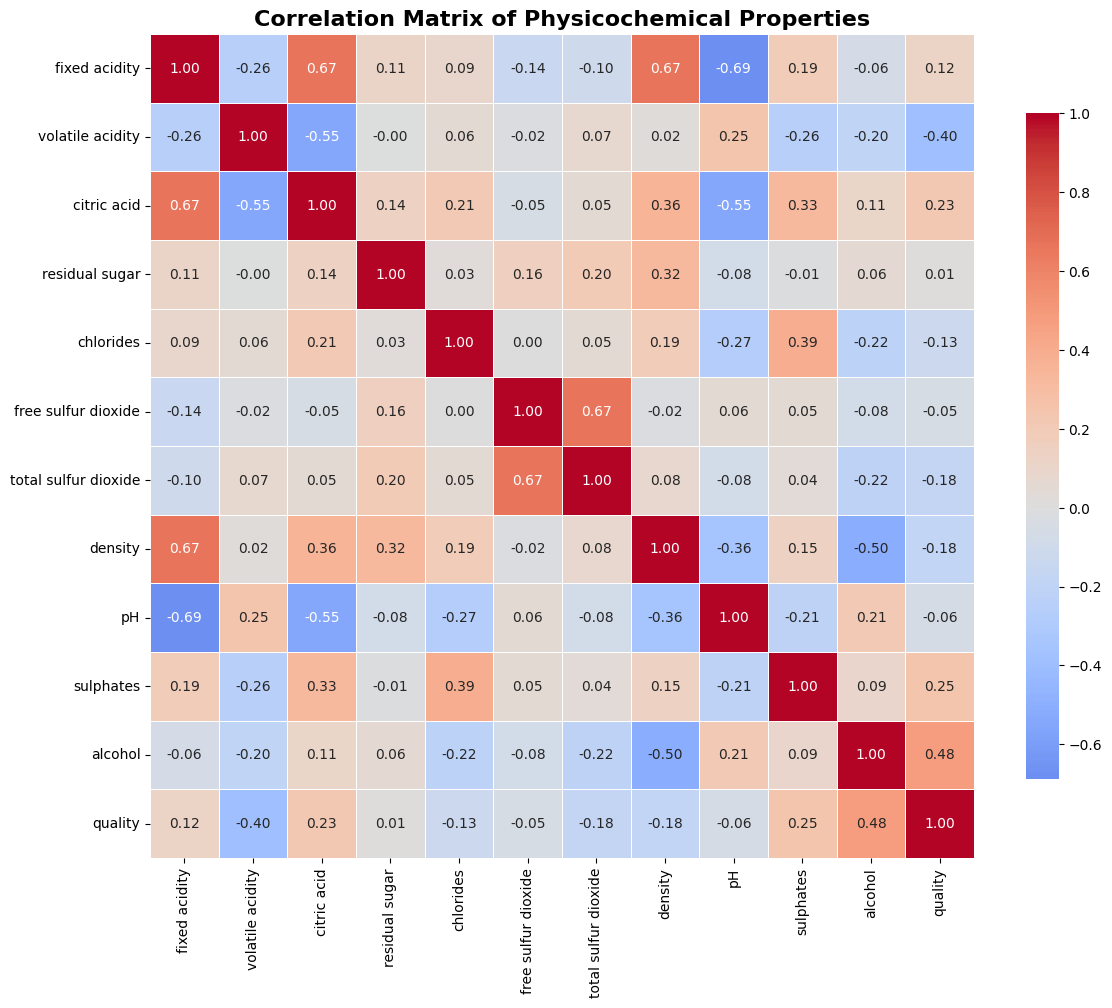

In [25]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Matrix of Physicochemical Properties",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### **Observation**

The correlation heatmap provides a visual summary of the linear relationships among the physicochemical properties and confirms that most feature pairs exhibit weak to moderate correlations. The strongest positive associations are observed between **fixed acidity and citric acid (r = 0.67)**, **fixed acidity and density (r = 0.67)**, and **free sulfur dioxide and total sulfur dioxide (r = 0.67)**, while **fixed acidity and pH (r = -0.69)** show the strongest negative correlation. With respect to wine quality, **alcohol** demonstrates the strongest positive association (r = 0.48), whereas **volatile acidity** exhibits the strongest negative association (r = -0.40), indicating that these variables are likely to be important predictors of wine quality.

### **Analytical Interpretation**

The heatmap confirms that the dataset contains meaningful relationships among several physicochemical properties, which is expected due to the chemical composition of wine. Although moderate correlations exist between certain predictors, the earlier VIF analysis showed that these relationships are inherent to the dataset rather than the result of redundant or erroneous measurements. Consequently, all predictor variables are retained for model development, allowing the machine learning algorithms to capture both individual and combined effects on wine quality prediction.

In [26]:
# ============================================================
# Correlation with Target Variable
# ============================================================

target_corr = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["Feature", "Correlation with Quality"]

display(target_corr_df.round(3))

,Feature,Correlation with Quality
0,alcohol,0.480
1,sulphates,0.249
2,citric acid,0.228
3,fixed acidity,0.119
4,residual sugar,0.014
5,free sulfur dioxide,-0.050
6,pH,-0.055
7,chlorides,-0.131
8,total sulfur dioxide,-0.178
9,density,-0.184


### **Observation**

The correlation analysis with the target variable (**quality**) indicates that **alcohol** has the strongest positive linear relationship (**r = 0.480**), suggesting that wines with higher alcohol content tend to receive higher quality ratings. Conversely, **volatile acidity** exhibits the strongest negative correlation (**r = -0.395**), indicating that increased volatile acidity is generally associated with lower wine quality. Variables such as **sulphates (r = 0.249)** and **citric acid (r = 0.228)** show moderate positive associations, whereas the remaining variables display relatively weak linear relationships with wine quality.

### **Analytical Interpretation**

The correlation coefficients indicate that no single physicochemical property has a very strong linear relationship with wine quality, suggesting that wine quality is influenced by the combined effect of multiple chemical characteristics rather than a single dominant factor. This supports the selection of ensemble machine learning models capable of capturing complex, non-linear interactions among predictor variables. Furthermore, these correlation values provide an initial indication of feature relevance, which will be validated through feature importance analysis and SHAP explainability during model development.

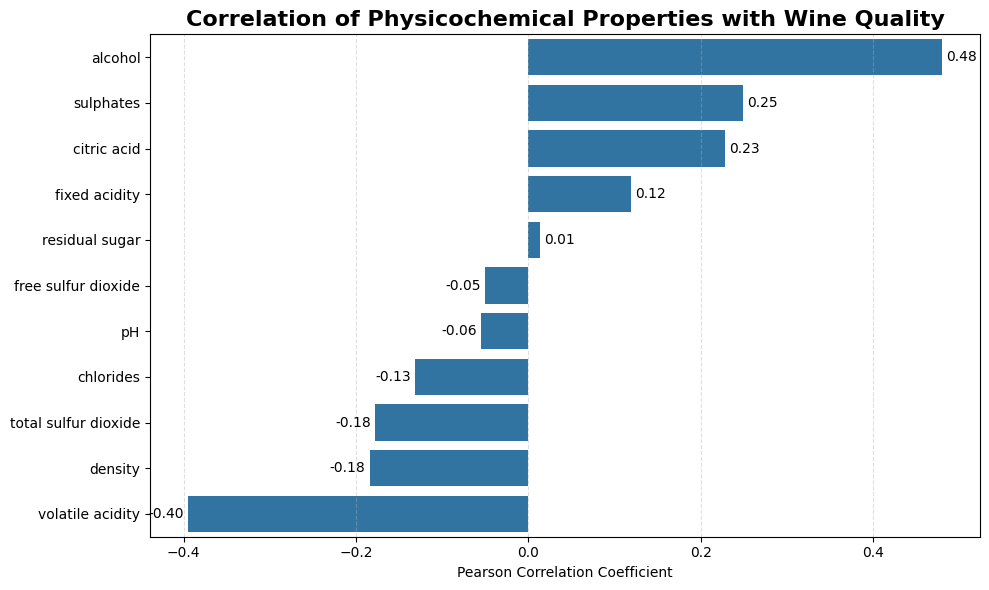

In [27]:
# ============================================================
# Correlation of Features with Wine Quality
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=target_corr_df,
    x="Correlation with Quality",
    y="Feature"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title(
    "Correlation of Physicochemical Properties with Wine Quality",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### **Observation**

The feature-wise correlation plot highlights the relative strength and direction of the linear relationship between each physicochemical property and wine quality. **Alcohol** exhibits the strongest positive association with wine quality (r = 0.48), followed by **sulphates** (r = 0.25) and **citric acid** (r = 0.23), suggesting that higher values of these variables are generally associated with better quality wines. In contrast, **volatile acidity** demonstrates the strongest negative correlation (r = –0.40), indicating that increased volatile acidity is associated with lower wine quality. Most of the remaining variables exhibit weak linear relationships, suggesting that wine quality is influenced by the combined interaction of multiple physicochemical properties rather than any single attribute.

## **Preliminary Feature Relevance Using Mutual Information**

Pearson correlation measures only linear relationships between predictor variables and wine quality. Mutual Information (MI) is therefore used as a complementary exploratory technique to identify both linear and non-linear dependencies between each physicochemical property and the target variable.

The analysis is used only to support exploratory data analysis and does not determine final feature selection or model selection.

In [28]:
# ============================================================
# Preliminary Feature Relevance Using Mutual Information
# ============================================================

from sklearn.feature_selection import mutual_info_regression

# Separate predictors and target
X_mi = df_clean.drop(columns=["quality"])
y_mi = df_clean["quality"]

# Calculate mutual information scores
mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=42
)

# Create a results table
mi_results = pd.DataFrame({
    "Feature": X_mi.columns,
    "Mutual Information Score": mi_scores
}).sort_values(
    by="Mutual Information Score",
    ascending=False
).reset_index(drop=True)

display(mi_results.round(4))

,Feature,Mutual Information Score
0,alcohol,0.1695
1,volatile acidity,0.1144
2,sulphates,0.0939
3,total sulfur dioxide,0.0592
4,density,0.0497
5,fixed acidity,0.0492
6,pH,0.0265
7,citric acid,0.0240
8,chlorides,0.0078
9,free sulfur dioxide,0.0014


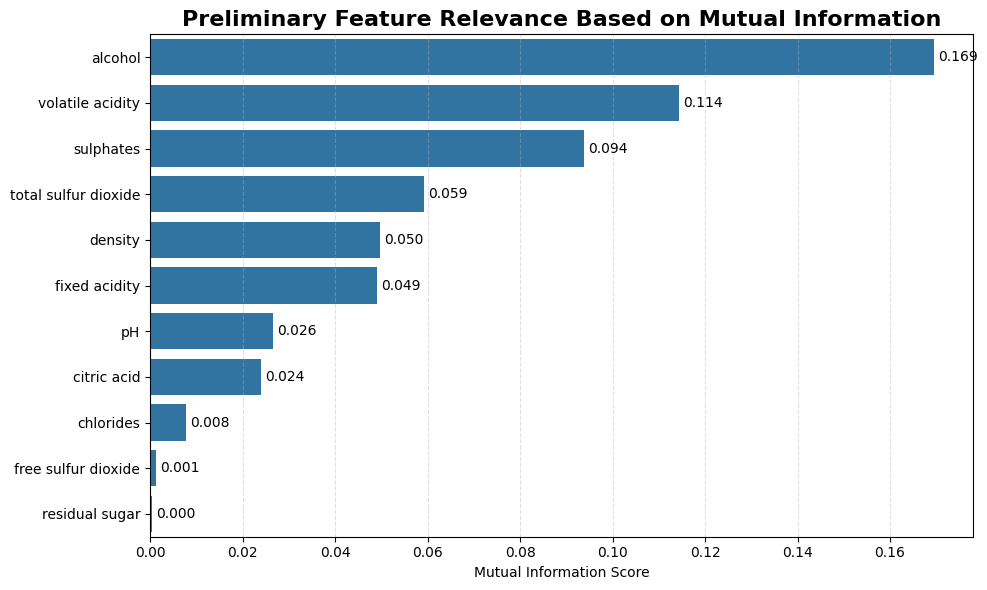

In [29]:
# ============================================================
# Mutual Information Feature Relevance Plot
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=mi_results,
    x="Mutual Information Score",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title(
    "Preliminary Feature Relevance Based on Mutual Information",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### **Observation**

The Mutual Information analysis provides an initial assessment of feature relevance by capturing both linear and non-linear dependencies between the predictor variables and wine quality. The results indicate that **alcohol** has the highest relevance score (0.1695), followed by **volatile acidity** (0.1144) and **sulphates** (0.0939), suggesting that these variables contain the greatest amount of information for predicting wine quality. Features such as **total sulfur dioxide**, **density**, and **fixed acidity** demonstrate moderate predictive relevance, whereas **residual sugar** and **free sulfur dioxide** contribute comparatively little information in isolation.

### **Analytical Interpretation**

Unlike Pearson correlation, which evaluates only linear relationships, Mutual Information captures both linear and non-linear associations between predictor variables and the target. The analysis confirms that several physicochemical properties possess predictive information that may not be fully reflected by correlation coefficients alone. In particular, the high ranking of **volatile acidity** reinforces its importance as a key determinant of wine quality. These findings provide additional justification for selecting ensemble machine learning algorithms capable of modelling complex interactions among physicochemical properties.

### **Research Decision**

The Mutual Information analysis is used solely for exploratory feature assessment and does not determine feature selection. All predictor variables are retained for model development because even variables with lower individual relevance may contribute to predictive performance when combined with other physicochemical properties. The final contribution of each predictor will be evaluated using the selected machine learning model and SHAP explainability analysis.

## **2.4 Bivariate Analysis**

Bivariate analysis examines the relationship between each predictor variable and the target variable (**quality**). Scatter plots with regression trend lines are used to visualize the direction and strength of these relationships, providing additional insight beyond the correlation coefficients calculated in the previous section.

In [30]:
# ============================================================
# Top Features by Absolute Correlation
# ============================================================

top_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

print("Top correlated features:")
print(top_features.tolist())

Top correlated features:
['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'total sulfur dioxide']


### **Observation**

Based on the correlation analysis, the six predictor variables with the strongest absolute association with wine quality were selected for detailed bivariate analysis. Focusing on the most influential features enables a clearer understanding of how variations in key physicochemical properties relate to wine quality.

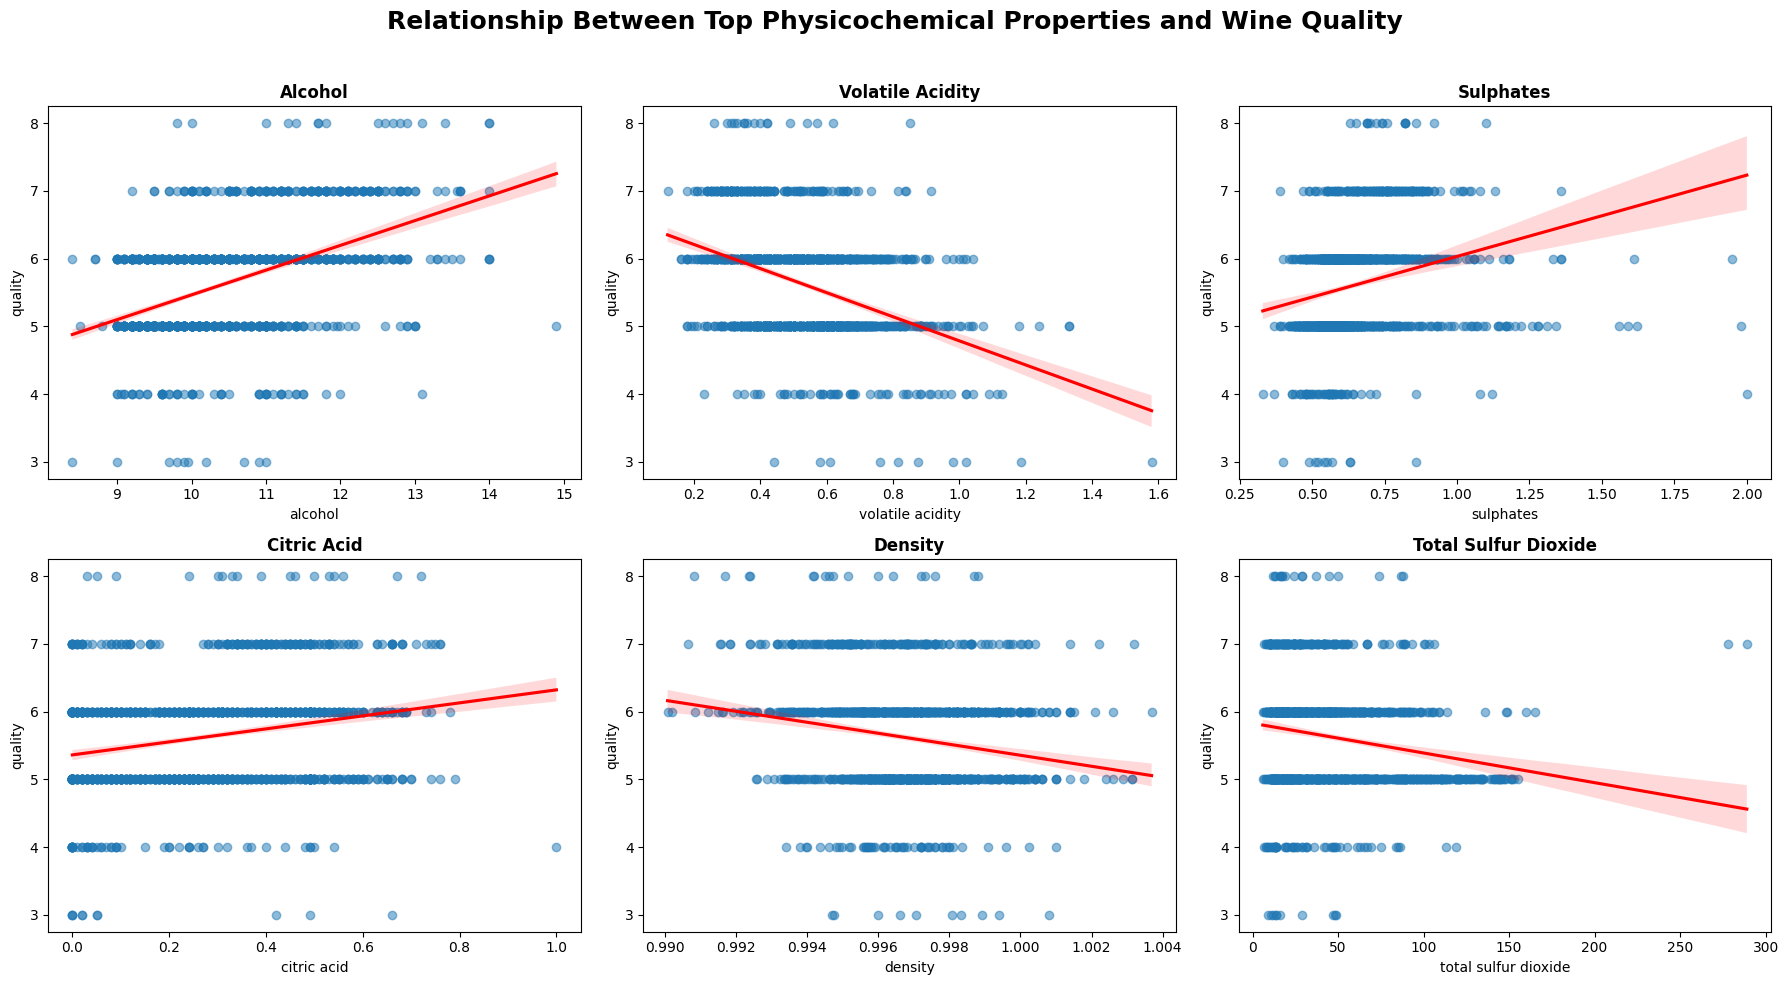

In [31]:
# ============================================================
# Scatter Plots of Top Predictors vs Wine Quality
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(top_features):

    sns.regplot(
        data=df_clean,
        x=feature,
        y="quality",
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=axes[i]
    )

    axes[i].set_title(feature.title(), fontsize=12, fontweight="bold")

plt.suptitle(
    "Relationship Between Top Physicochemical Properties and Wine Quality",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

### **Observation**

The bivariate scatter plots reveal distinct relationships between the selected physicochemical properties and wine quality. **Alcohol** and **sulphates** exhibit clear positive trends, indicating that higher values are generally associated with better quality wines. In contrast, **volatile acidity**, **density**, and **total sulfur dioxide** demonstrate negative relationships with wine quality, while **citric acid** shows a relatively weak positive trend. The fitted regression lines further confirm the direction of these associations identified during the correlation and Mutual Information analyses.

### **Analytical Interpretation**

The bivariate analysis demonstrates that the relationship between individual physicochemical properties and wine quality is not perfectly linear, with considerable variation observed across all quality levels. This suggests that no single predictor is sufficient to accurately estimate wine quality. Instead, wine quality is influenced by the combined interaction of multiple chemical characteristics, supporting the use of ensemble machine learning models capable of learning complex relationships among predictor variables. The consistency between the bivariate trends, correlation analysis, and Mutual Information rankings further validates the suitability of the selected predictors for model development.

## **2.5 Outlier Analysis**

Outlier analysis is performed to identify unusually high or low observations that may influence statistical analysis and machine learning model performance. The Interquartile Range (IQR) method is used to detect potential outliers for each predictor variable. The results are evaluated to determine whether outlier treatment is necessary prior to model development.

In [32]:
# ============================================================
# Outlier Detection using the IQR Method
# ============================================================

outlier_summary = []

predictors = df_clean.drop(columns="quality")

for column in predictors.columns:

    Q1 = predictors[column].quantile(0.25)
    Q3 = predictors[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = predictors[
        (predictors[column] < lower) |
        (predictors[column] > upper)
    ].shape[0]

    percentage = round(outliers / len(df_clean) * 100, 2)

    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        outliers,
        percentage
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Outliers",
        "Percentage (%)"
    ]
)

display(
    outlier_summary.sort_values(
        "Percentage (%)",
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Outliers,Percentage (%)
3,residual sugar,1.9000,2.60000,0.70000,126,9.27
4,chlorides,0.0700,0.09100,0.02100,87,6.40
9,sulphates,0.5500,0.73000,0.18000,55,4.05
6,total sulfur dioxide,22.0000,63.00000,41.00000,45,3.31
0,fixed acidity,7.1000,9.20000,2.10000,41,3.02
7,density,0.9956,0.99782,0.00222,35,2.58
8,pH,3.2100,3.40000,0.19000,28,2.06
5,free sulfur dioxide,7.0000,21.00000,14.00000,26,1.91
1,volatile acidity,0.3900,0.64000,0.25000,19,1.40
10,alcohol,9.5000,11.10000,1.60000,12,0.88


### **Observation**

The IQR-based outlier analysis indicates that the proportion of outliers varies considerably across the physicochemical properties. **Residual sugar** contains the highest percentage of outliers (9.27%), followed by **chlorides (6.40%)**, **sulphates (4.05%)**, and **total sulfur dioxide (3.31%)**. In contrast, variables such as **citric acid (0.07%)** and **alcohol (0.88%)** exhibit very few extreme observations. The relatively low percentage of outliers across most variables suggests that the dataset is generally well-behaved despite the presence of some extreme laboratory measurements.

### **Analytical Interpretation**

The identified outliers are consistent with the distribution and boxplot analyses, confirming that they primarily occur in variables exhibiting positive skewness. Since the UCI Wine Quality dataset comprises laboratory measurements of real wine samples, these extreme observations are likely to represent genuine variations in wine composition rather than data quality issues. Consequently, the presence of outliers is considered an inherent characteristic of the dataset rather than an indication of erroneous observations.

### **Preprocessing Decision**

Although several variables contain IQR-based outliers, no observations were removed or capped during preprocessing. Removing these values could eliminate important information associated with naturally occurring variations in red wine composition and potentially reduce the model's ability to generalize to real-world production data. Furthermore, the selected tree-based machine learning algorithms (Decision Tree, Random Forest, Gradient Boosting, and XGBoost) are inherently robust to outliers, making explicit outlier treatment unnecessary. The effect of these observations is instead evaluated through model performance and SHAP-based feature interpretation.

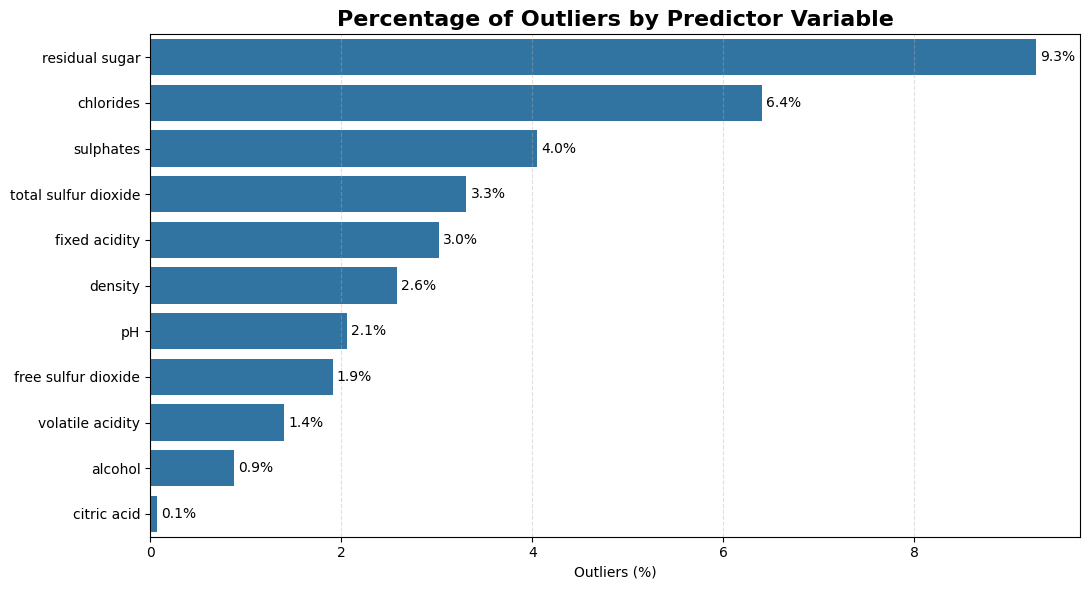

In [33]:
# ============================================================
# Percentage of Outliers by Variable
# ============================================================

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=outlier_summary.sort_values(
        "Percentage (%)",
        ascending=False
    ),
    x="Percentage (%)",
    y="Variable"
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title(
    "Percentage of Outliers by Predictor Variable",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Outliers (%)")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### **Observation**

The outlier distribution chart highlights that the percentage of extreme observations varies across the predictor variables. **Residual sugar (9.3%)** and **chlorides (6.4%)** contain the highest proportion of outliers, followed by **sulphates (4.0%)** and **total sulfur dioxide (3.3%)**. Most of the remaining variables contain fewer than 3% outliers, while **citric acid** exhibits almost no extreme observations. Overall, the percentage of outliers is relatively low for the majority of variables, indicating that extreme values are concentrated within a small subset of physicochemical properties.

### **Analytical Interpretation**

The concentration of outliers in variables such as residual sugar and chlorides is consistent with the positive skewness observed during the univariate analysis and reflects the natural variability in the chemical composition of red wine. Since these observations are derived from laboratory measurements rather than data entry errors, they are considered representative of genuine wine characteristics. The relatively small proportion of outliers across most predictor variables suggests that the dataset remains suitable for machine learning without extensive outlier treatment.

### **Preprocessing Decision**

The IQR analysis was performed to quantify the extent of outliers before model development. Although several predictor variables contain extreme observations, no winsorization, transformation, or outlier removal was performed. This decision preserves naturally occurring physicochemical variations in the dataset and avoids the loss of potentially valuable information. Furthermore, the selected tree-based algorithms are inherently robust to outliers, allowing these observations to be retained while evaluating their influence through model performance and SHAP explainability.

In [34]:
# ============================================================
# Variables with Significant Outliers
# ============================================================

display(
    outlier_summary[
        outlier_summary["Percentage (%)"] > 5
    ].sort_values(
        "Percentage (%)",
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Outliers,Percentage (%)
3,residual sugar,1.90,2.600,0.700,126,9.27
4,chlorides,0.07,0.091,0.021,87,6.40


### **Observation**

Applying a threshold of **5% outliers** identifies only **two predictor variables** requiring closer examination: **residual sugar (9.27%)** and **chlorides (6.40%)**. All remaining variables contain less than 5% outliers, indicating that extreme observations are not widespread throughout the dataset.

### **Analytical Interpretation**

The results suggest that the dataset does not suffer from pervasive outlier contamination. Instead, the extreme values are concentrated within a small number of physicochemical properties, likely reflecting natural variations in wine composition rather than data quality issues. Consequently, blanket outlier removal would unnecessarily discard valid observations.

### **Data Preprocessing Decision**

Based on the IQR analysis, no predictor variables were removed or capped during preprocessing. Although residual sugar and chlorides exhibit relatively higher outlier percentages, these values were retained because they represent genuine laboratory measurements. Preserving these observations ensures that the predictive models learn from the full variability present in real-world red wine samples. The impact of these retained outliers will be assessed during model evaluation and explainability analysis (SHAP).

## **2.6 Multicollinearity Assessment**

Multicollinearity occurs when two or more predictor variables are highly correlated with one another. Excessive multicollinearity can reduce the stability and interpretability of regression models by inflating coefficient estimates. Therefore, the relationships among predictor variables are examined before model development.

In [35]:
# ============================================================
# Identify Highly Correlated Predictor Variables
# ============================================================

predictors = df_clean.drop(columns="quality")

corr_matrix = predictors.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper_triangle.stack()
    .reset_index()
)

high_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr = high_corr[
    high_corr["Correlation"] >= 0.70
].sort_values(
    "Correlation",
    ascending=False
)

display(high_corr)

# ============================================================
# Multicollinearity Assessment
# ============================================================

if high_corr.empty:
    print("1. No predictor pairs have an absolute correlation of 0.70 or greater.")
    print("2. No strong multicollinearity was detected among the predictor variables.")
    print("3. All predictor variables will be retained for model development.")
else:
    print(f"Found {len(high_corr)} highly correlated predictor pair(s):")
    display(high_corr)

,Feature 1,Feature 2,Correlation


1. No predictor pairs have an absolute correlation of 0.70 or greater.
2. No strong multicollinearity was detected among the predictor variables.
3. All predictor variables will be retained for model development.


### **Observation**

Using a correlation threshold of |r| ≥ 0.70, no predictor pairs were identified as exhibiting strong pairwise linear relationships. This indicates that no single pair of physicochemical properties demonstrates excessive correlation that would warrant immediate feature removal.

# **3 Model Evaluation Criteria**

# **3.1 - Model Evaluation Criteria**

The primary objective of this study is to develop and compare multiple machine learning regression models for predicting wine quality using physicochemical properties. To ensure a fair and comprehensive comparison, each model will be evaluated using a common set of regression performance metrics.

The selected evaluation metrics measure different aspects of prediction accuracy and together provide a balanced assessment of model performance.

To ensure an objective comparison, all machine learning models will be trained using the same training dataset, evaluated on the same testing dataset, and assessed using identical performance metrics. This standardized evaluation framework ensures that differences in model performance are attributable to the algorithms themselves rather than differences in the evaluation procedure.

### **Mean Absolute Error (MAE)**

Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted wine quality scores. MAE is easy to interpret because the error is expressed in the same units as the target variable. Lower MAE values indicate better predictive performance.

\[
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
\]

---

### **Root Mean Squared Error (RMSE)**

Root Mean Squared Error (RMSE) measures the square root of the average squared prediction errors. Since larger errors receive greater penalties, RMSE is particularly useful for identifying models that occasionally make large prediction errors.

\[
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
\]

---

### **Coefficient of Determination (R²)**

The coefficient of determination (R²) measures the proportion of variance in wine quality that can be explained by the predictor variables. R² values range from 0 to 1, where higher values indicate better explanatory power.

\[
R^2=1-\frac{\sum(y_i-\hat{y_i})^2}{\sum(y_i-\bar y)^2}
\]

---

### **Cross-Validation**

A 5-fold cross-validation strategy will be applied during model development to assess the stability and generalization capability of each algorithm. The training data will be divided into five equally sized folds, where four folds are used for model training and one fold for validation in each iteration. The average cross-validation score will be used to evaluate model robustness and reduce the risk of overfitting to a single train-test split.

---

### **Model Selection Criteria**

The best-performing model will be selected based on the following criteria:

* Lowest Mean Absolute Error (MAE)
* Lowest Root Mean Squared Error (RMSE)
* Highest Coefficient of Determination (R²)
* Consistent performance across the 5-fold cross-validation
* Model robustness and ability to generalize to unseen data
* Explainability through SHAP feature importance analysis

The selected evaluation framework ensures that the comparison considers both predictive accuracy and model robustness while supporting the research objectives of this study.

### **Quick Overview**

| Criterion                   | Why it is Used                                             | Desired Outcome       |
| --------------------------- | ---------------------------------------------------------- | --------------------- |
| **MAE**                     | Measures the average absolute prediction error             | Lower                 |
| **RMSE**                    | Penalizes larger prediction errors                         | Lower                 |
| **R²**                      | Measures the proportion of variance explained by the model | Higher                |
| **5-Fold Cross Validation** | Evaluates model stability and generalization               | Higher and consistent |
| **SHAP**                    | Explains feature contributions and model predictions       | High interpretability |


## **3.2 Data Preprocessing**

Data preprocessing is a critical step in the machine learning workflow, ensuring that the dataset is suitable for model development while minimizing bias and preventing data leakage. Based on the findings from the exploratory data analysis, duplicate records were removed, no missing values required imputation, naturally occurring outliers were retained, and all predictor variables were preserved despite moderate multicollinearity. These preprocessing decisions maintain the integrity of the original dataset while ensuring that the models learn from representative physicochemical characteristics of red wine.

The first preprocessing step involves separating the predictor variables (X) from the target variable (y). This distinction enables the machine learning algorithms to learn the relationship between the physicochemical properties and the corresponding wine quality scores.

In [36]:
# ============================================================
# Separate Predictor Variables and Target Variable
# ============================================================

X = df_clean.drop(columns="quality")
y = df_clean["quality"]

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"Predictor Variables : {X.shape[1]}")
print(f"Observations        : {X.shape[0]}")

print("\nTarget Variable:")
print(y.name)

FEATURE MATRIX
Predictor Variables : 11
Observations        : 1359

Target Variable:
quality


### **Observation**

The cleaned dataset was successfully separated into predictor variables (X) and the target variable (y). The feature matrix consists of **11 predictor variables** describing the physicochemical properties of red wine and **1,359 observations** after duplicate removal. The target variable is the wine quality score, which will be predicted using supervised machine learning regression algorithms.

### **Preprocessing Decision**

The target variable (**quality**) was excluded from the predictor matrix before model development to prevent target leakage. All eleven physicochemical variables were retained as input features based on the exploratory data analysis, feature relevance assessment, and multicollinearity evaluation.

## **Data Preprocessing Strategy**

The preprocessing workflow was designed to ensure fair model comparison while minimizing bias and preventing data leakage.

The preprocessing decisions adopted in this study are summarized below:

- Duplicate records were removed prior to model development.
- No missing values were identified; therefore, no imputation was required.
- Outliers were retained because they represent genuine laboratory measurements and the selected tree-based algorithms are robust to extreme observations.
- All predictor variables were retained despite moderate multicollinearity, as ensemble tree-based models are less sensitive to correlated features.
- The predictor variables and target variable were separated before performing the train-test split.
- The train-test split was performed before model training to ensure that the testing dataset remained completely unseen during model development.

### **Train-Test Split Strategy**

The cleaned dataset is divided into training and testing subsets using an **80:20 split**. The training set is used for model development and cross-validation, while the testing set is reserved for final evaluation on unseen data.

A fixed **random_state=42** is used to ensure reproducibility. Since the wine quality scores are unevenly distributed, **stratify=y** is applied to preserve approximately the same target distribution in both the training and testing datasets. This reduces the risk that rare quality scores are disproportionately allocated to only one subset.

The split is performed before feature scaling and model training so that all preprocessing steps can be fitted using the training data only, thereby preventing data leakage from the test set.

In [37]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

TRAIN-TEST SPLIT
Training Samples : 1087
Testing Samples  : 272


### **Observation**

The dataset was successfully divided into training and testing subsets using an 80:20 ratio. The training data will be used for model development and cross-validation, while the unseen testing data will be used only for final performance evaluation. Stratification preserves the original distribution of wine quality scores across both subsets, supporting a fairer assessment of model generalization.

In [38]:
# ============================================================
# Verify Dataset Dimensions
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

display(split_summary)

,Dataset,Rows,Columns
0,Training Set,1087,11
1,Testing Set,272,11


### **Observation**

The train-test split was successfully completed, resulting in **1,087 training observations (80%)** and **272 testing observations (20%)**. Both datasets retain the same **11 predictor variables**, confirming that the feature space remains consistent across the training and testing subsets.

### **Validation Check**

The dataset dimensions confirm that the train-test split was performed correctly without any loss of predictor variables. Maintaining an identical feature structure ensures that the models trained on the training dataset can be evaluated consistently on the unseen testing dataset.

In [39]:
# ============================================================
# Verify Target Distribution After Train-Test Split
# ============================================================

distribution = pd.DataFrame({
    "Original (%)": (y.value_counts(normalize=True).sort_index() * 100).round(2),
    "Training (%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Testing (%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

display(distribution)

,Original (%),Training (%),Testing (%)
quality,,,
3,0.74,0.74,0.74
4,3.90,3.86,4.04
5,42.46,42.41,42.65
6,39.37,39.37,39.34
7,12.29,12.33,12.13
8,1.25,1.29,1.10


### **Observation**

The distribution of wine quality scores remains highly consistent across the original dataset, training dataset, and testing dataset. The differences in class proportions are negligible (generally less than 0.2%), confirming that the stratified train-test split successfully preserved the original target distribution.

### **Interpretation**

The use of stratified sampling ensures that each wine quality category (3–8) is proportionally represented in both the training and testing datasets. This minimizes sampling bias and provides a more reliable basis for evaluating the predictive performance of the machine learning models.

## **3.3 Feature Scaling**

Machine learning algorithms differ in their sensitivity to the scale of predictor variables. Linear Regression assumes comparable feature scales and can benefit from standardization, whereas tree-based algorithms such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost are generally insensitive to feature scaling.

To ensure a fair comparison across all regression models, feature standardization is performed using the StandardScaler. The scaler is fitted exclusively on the training dataset to calculate the mean and standard deviation of each predictor variable. These learned parameters are then applied to transform both the training and testing datasets. Fitting the scaler only on the training data prevents information from the testing dataset from influencing the model development process, thereby eliminating data leakage and ensuring an unbiased evaluation.

In [40]:
# ============================================================
# Feature Scaling using StandardScaler
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### **Observation**

The predictor variables were successfully standardized using the StandardScaler. The scaling parameters (mean and standard deviation) were estimated solely from the training dataset and subsequently applied to both the training and testing datasets. This ensures that all continuous predictor variables are measured on a comparable scale while preserving the independence of the testing dataset.

In [41]:
# ============================================================
# Verify Feature Scaling
# ============================================================

scaled_summary = pd.DataFrame({
    "Mean": X_train_scaled.mean(axis=0),
    "Std Dev": X_train_scaled.std(axis=0)
}, index=X.columns)

display(scaled_summary.round(3))

,Mean,Std Dev
fixed acidity,0.0,1.0
volatile acidity,0.0,1.0
citric acid,0.0,1.0
residual sugar,0.0,1.0
chlorides,0.0,1.0
free sulfur dioxide,0.0,1.0
total sulfur dioxide,-0.0,1.0
density,0.0,1.0
pH,-0.0,1.0
sulphates,0.0,1.0


### **Observation**

The standardized training dataset has a mean of approximately **0** and a standard deviation of **1** for all predictor variables. This confirms that the StandardScaler was successfully applied and that each feature was transformed to a common numerical scale without altering the underlying relationships within the data.

In [42]:
# ============================================================
# Convert Scaled Arrays to DataFrames
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
649,-0.631638,-0.172462,-0.472778,-0.321789,-0.342364,-0.377365,-0.475851,0.471781,1.331499,0.377601,-0.769571
1071,-0.743460,0.258557,0.036144,1.683774,-0.048390,-0.377365,0.631470,-0.195113,0.071902,0.259621,0.507402
14,0.095209,-1.357767,1.461127,-0.544630,0.098596,1.790243,1.622230,0.101863,-0.054057,0.554571,0.051340
674,-0.687549,-0.064707,-1.236162,0.049611,-0.237373,0.470829,1.301690,0.388419,1.205539,-0.330279,-0.587147
684,-0.687549,0.420190,-1.287054,-0.024669,-0.132383,0.093854,1.155990,0.388419,1.079579,-0.330279,-0.678359


### **Observation**

The standardized training and testing datasets were successfully converted from NumPy arrays into pandas DataFrames. The original feature names and row indices were preserved, ensuring that each standardized value remains correctly associated with its corresponding physicochemical property and wine sample.

## **Research Methodology Workflow**

```text
Raw Dataset
    │
    ▼
Data Quality Assessment
(Missing Values and Duplicates)
    │
    ▼
Data Cleaning
(Remove Duplicate Records)
    │
    ▼
Exploratory Data Analysis
(Descriptive Statistics, Distributions,
Outliers, Correlation, VIF,
Mutual Information, Bivariate Analysis)
    │
    ▼
Feature Retention
(All 11 Predictors Retained)
    │
    ▼
Train-Test Split
(80:20 Stratified Split)
    │
    ▼
Feature Scaling
(StandardScaler Fitted on Training Data Only)
    │
    ▼
Model Development
(Linear Regression, Decision Tree,
Random Forest, Gradient Boosting, XGBoost)
    │
    ▼
Hyperparameter Optimization
(GridSearchCV with 5-Fold Cross-Validation)
    │
    ▼
Model Evaluation
(MAE, RMSE, R², Cross-Validation,
Residual and Prediction Error Analysis)
    │
    ▼
Comparative Model Assessment
    │
    ▼
Final Model Selection
    │
    ▼
SHAP Explainability
    │
    ▼
Business Interpretation and Deployment Framework

## **3.5 Model Development Plan**

* Five supervised machine learning regression algorithms are developed and evaluated in this study to predict wine quality from physicochemical properties.

* The modelling process follows a progressive approach. A baseline Linear Regression model is first developed to establish benchmark performance. This is followed by Decision Tree Regression, Random Forest Regression, Gradient Boosting Regression, and Extreme Gradient Boosting (XGBoost), enabling comparison between linear, tree-based, ensemble bagging, and ensemble boosting techniques.

* For the tree-based models, hyperparameter optimisation is performed using GridSearchCV with 5-fold cross-validation to improve predictive performance while reducing the risk of overfitting.

* Each model is evaluated using the predefined performance metrics (MAE, RMSE, R², and Cross-Validation Score). The best-performing model is subsequently interpreted using SHAP to identify the most influential physicochemical properties affecting wine quality.



---



The following models will be developed and compared in this study. The table summarizes the model type, scaling requirements, planned hyperparameter optimization, and explainability approach.

| Model | Regression Type | Data Used | Hyperparameter Tuning | Explainability |
|---|---|---|---|---|
| Linear Regression | Linear model | Scaled features | Not required for the baseline model | Model coefficients |
| Decision Tree Regression | Tree-based model | Unscaled features | Yes | Feature importance |
| Random Forest Regression | Ensemble bagging model | Unscaled features | Yes | Feature importance and SHAP |
| Gradient Boosting Regression | Ensemble boosting model | Unscaled features | Yes | Feature importance and SHAP |
| XGBoost Regression | Gradient-boosted tree model | Unscaled features | Yes | Feature importance and SHAP |

## **3.5 Baseline Model: Linear Regression**

Linear Regression is used as the baseline model because it provides a simple and interpretable benchmark for predicting wine quality. The model estimates the linear relationship between the physicochemical predictor variables and the target variable (**quality**).

The standardized feature set is used so that the model coefficients can be compared on a common scale. Model performance will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [44]:
# ============================================================
# Unified Model Evaluation Function
# ============================================================

from sklearn.model_selection import KFold, cross_validate

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_model_with_cv(
    model_name,
    model,
    X_train_data,
    y_train_data,
    train_predictions,
    y_test_data,
    test_predictions
):
    """
    Evaluate a regression model using training performance,
    holdout test performance, and five-fold cross-validation.

    Returns
    -------
    pandas.DataFrame
        One-row summary of model performance.
    """

    # Training metrics
    train_mae = mean_absolute_error(
        y_train_data,
        train_predictions
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train_data,
            train_predictions
        )
    )

    train_r2 = r2_score(
        y_train_data,
        train_predictions
    )

    # Holdout test metrics
    test_mae = mean_absolute_error(
        y_test_data,
        test_predictions
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_data,
            test_predictions
        )
    )

    test_r2 = r2_score(
        y_test_data,
        test_predictions
    )

    # Five-fold cross-validation on training data only
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }

    cv_scores = cross_validate(
        model,
        X_train_data,
        y_train_data,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_mae = -cv_scores["test_MAE"].mean()
    cv_rmse = -cv_scores["test_RMSE"].mean()
    cv_r2 = cv_scores["test_R2"].mean()

    cv_mae_std = (-cv_scores["test_MAE"]).std()
    cv_rmse_std = (-cv_scores["test_RMSE"]).std()
    cv_r2_std = cv_scores["test_R2"].std()

    results = pd.DataFrame({
        "Model": [model_name],

        "Train MAE": [train_mae],
        "Train RMSE": [train_rmse],
        "Train R²": [train_r2],

        "Test MAE": [test_mae],
        "Test RMSE": [test_rmse],
        "Test R²": [test_r2],

        "CV MAE": [cv_mae],
        "CV MAE Std": [cv_mae_std],

        "CV RMSE": [cv_rmse],
        "CV RMSE Std": [cv_rmse_std],

        "CV R²": [cv_r2],
        "CV R² Std": [cv_r2_std]
    })

    return results

### **Observations**

A unified model evaluation framework was developed to ensure that all regression models are assessed using a consistent methodology. The function computes training performance, holdout test performance, and 5-fold cross-validation metrics (MAE, RMSE, and R²), enabling fair comparison across models. Reporting both the mean and standard deviation of cross-validation scores provides additional insight into model stability and generalization performance, while the separate evaluation of training and testing results supports the identification of potential overfitting or underfitting.

In [45]:
# ============================================================
# Train Baseline Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Linear Regression model trained successfully.")

Baseline Linear Regression model trained successfully.


### **Observation**

The baseline Linear Regression model was successfully trained using the standardized training dataset. Model training completed without errors, indicating that the predictor variables and target variable were correctly prepared for supervised learning. This model serves as the baseline regression algorithm against which the performance of the subsequent tree-based and ensemble models will be evaluated.

### **Methodological Significance**

Linear Regression provides a simple and interpretable benchmark for assessing predictive performance. Establishing a baseline enables a meaningful comparison with more advanced machine learning algorithms, allowing improvements in prediction accuracy, generalization capability, and robustness to be objectively quantified.

In [46]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_lr = linear_model.predict(X_train_scaled)
y_test_pred_lr = linear_model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observation**

Predictions were successfully generated for both the training and testing datasets using the fitted Linear Regression model. The training predictions will be used to assess how well the model has learned the underlying relationships within the training data, while the testing predictions will be used to evaluate the model's ability to generalize to previously unseen wine samples.

### **Methodological Significance**

Generating predictions for both datasets establishes the basis for a comprehensive model evaluation. In the subsequent step, the predicted values will be compared with the actual wine quality scores using MAE, RMSE, R², and 5-fold cross-validation metrics to assess predictive accuracy, model stability, and generalization performance.

In [47]:
# ============================================================
# Initialize Model Results Storage
# ============================================================

all_model_results = []

print("Results container initialized.")

Results container initialized.


### **Observation**

A results container was successfully initialized to store the evaluation metrics of all regression models. This approach ensures that the performance of each model is recorded consistently and can later be consolidated into a single comparison table for objective model selection.

In [49]:
# ============================================================
# Create Leakage-Safe Linear Regression Pipeline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_train_pred_lr = linear_pipeline.predict(X_train)
y_test_pred_lr = linear_pipeline.predict(X_test)

print("Leakage-safe Linear Regression pipeline trained successfully.")

Leakage-safe Linear Regression pipeline trained successfully.


### **Observation**

A leakage-safe Linear Regression pipeline was successfully trained using the training dataset. Feature scaling was applied within the modeling pipeline, ensuring that scaling parameters were learned exclusively from the training data and subsequently applied to the test data. This approach prevents information leakage and enables an unbiased evaluation of the model's predictive performance.

In [50]:
# ============================================================
# Evaluate Linear Regression Model
# ============================================================

lr_results = evaluate_model_with_cv(
    model_name="Linear Regression",
    model=linear_pipeline,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_lr,
    y_test_data=y_test,
    test_predictions=y_test_pred_lr
)

# Store results
all_model_results.append(lr_results)

# Display accumulated results
comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(comparison_table.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.51,0.6595,0.3599,0.5066,0.6523,0.3657,0.516,0.0251,0.6659,0.0452,0.341,0.0279


### **Observations**

- The baseline Linear Regression model achieved a Test MAE of **0.5066**, indicating that the predicted wine quality scores differ from the actual scores by approximately **0.51 quality points** on average.

- The Test RMSE of **0.6523** is only slightly higher than the MAE, suggesting that the model does not produce a large number of extreme prediction errors.

- The model explained approximately **36.6%** of the variation in wine quality (Test R² = **0.3657**), indicating a moderate linear relationship between the physicochemical properties and the target variable.

- Training and testing performance were very similar (Train R² = **0.3599**, Test R² = **0.3657**), suggesting that the model generalized well and showed **no evidence of overfitting**.

- Five-fold cross-validation produced consistent results (CV R² = **0.341 ± 0.028**, CV MAE = **0.516 ± 0.025**, CV RMSE = **0.666 ± 0.045**), demonstrating that the model performance was stable across different subsets of the training data.

- As the baseline regression model, these results provide an appropriate benchmark against which the subsequent Decision Tree, Random Forest, Gradient Boosting, and XGBoost models will be compared.

In [51]:
# ============================================================
# Linear Regression Coefficients
# ============================================================

lr_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

lr_coefficients["Absolute Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(lr_coefficients.round(4))

,Feature,Coefficient,Absolute Coefficient
10,alcohol,0.3101,0.3101
1,volatile acidity,-0.1875,0.1875
9,sulphates,0.1478,0.1478
4,chlorides,-0.0929,0.0929
6,total sulfur dioxide,-0.0904,0.0904
8,pH,-0.0565,0.0565
5,free sulfur dioxide,0.0535,0.0535
0,fixed acidity,0.0218,0.0218
3,residual sugar,-0.0207,0.0207
7,density,-0.0152,0.0152


### **Observations**

- The standardized regression coefficients indicate the direction and relative magnitude of each predictor's contribution to the predicted wine quality while holding all other variables constant.

- **Alcohol** had the largest positive coefficient (**0.3101**), indicating that higher alcohol content was associated with higher predicted wine quality. This finding is consistent with the earlier correlation and mutual information analyses.

- **Volatile acidity** exhibited the strongest negative coefficient (**-0.1875**), suggesting that an increase in volatile acidity reduced the predicted wine quality. This agrees with the moderate negative Pearson correlation observed during exploratory data analysis.

- **Sulphates** showed the third-largest positive coefficient (**0.1478**), indicating a positive contribution to wine quality after accounting for the effects of the remaining predictor variables.

- **Chlorides (-0.0929)** and **total sulfur dioxide (-0.0904)** also demonstrated negative associations with wine quality, although their influence was smaller than that of alcohol and volatile acidity.

- Variables such as **citric acid, density, residual sugar, and fixed acidity** exhibited relatively small coefficients, indicating comparatively weaker linear contributions in the baseline Linear Regression model.

- Because all predictor variables were standardized before model fitting, the coefficient magnitudes are directly comparable across features. However, these coefficients represent linear relationships only and should not be interpreted as evidence of causality.

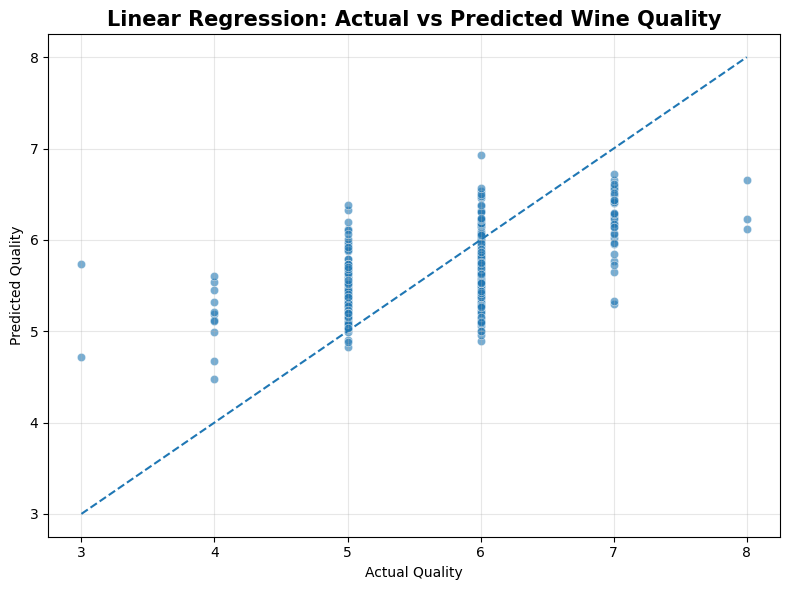

In [52]:
# ============================================================
# Actual vs Predicted Wine Quality
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_lr,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "Linear Regression: Actual vs Predicted Wine Quality",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Observations**

- The scatter plot compares the actual wine quality scores with the values predicted by the baseline Linear Regression model on the holdout test dataset.

- The dashed diagonal line represents perfect predictions, where the predicted and actual wine quality scores are identical. Points located closer to this line indicate more accurate predictions.

- The model generally predicts wine quality within the range of **5 to 6.5**, demonstrating its ability to capture the central tendency of the dataset.

- Predictions for the majority quality classes (**5 and 6**) are relatively close to the reference line, indicating better predictive performance for the most frequently occurring wine quality scores.

- Greater deviations from the reference line are observed for the minority quality classes (**3, 4, 7, and 8**). In particular, the model tends to **overestimate lower-quality wines** and **underestimate higher-quality wines**, illustrating the regression-to-the-mean behaviour commonly observed in linear regression models.

- The observed prediction pattern is consistent with the performance metrics obtained earlier (Test MAE = **0.5066**, Test RMSE = **0.6523**, Test R² = **0.3657**), indicating moderate predictive performance while suggesting that the linear model is unable to fully capture the complex relationships between physicochemical properties and wine quality.

- These findings justify the subsequent evaluation of nonlinear tree-based ensemble models, which are expected to model complex feature interactions more effectively.

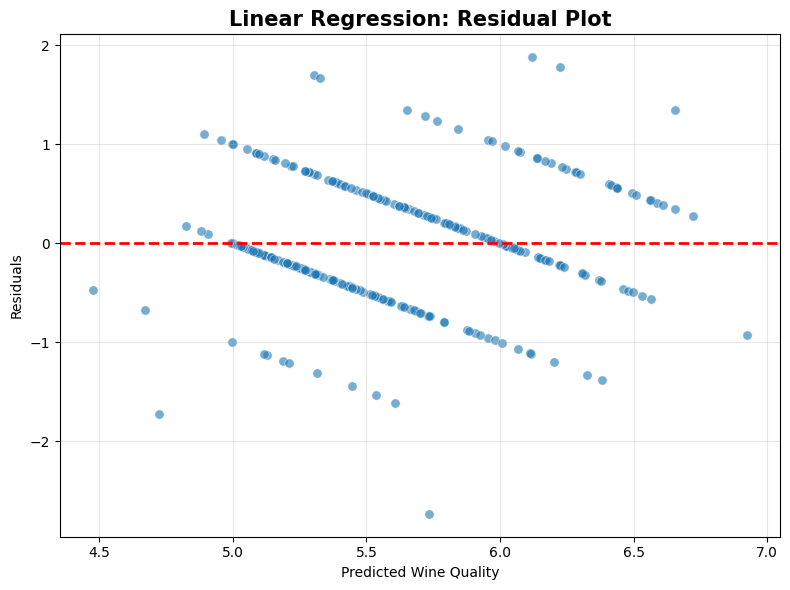

In [54]:
# ============================================================
# Residual Plot
# ============================================================

residuals = y_test - y_test_pred_lr

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test_pred_lr,
    y=residuals,
    alpha=0.6,
    s=45
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Linear Regression: Residual Plot",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Wine Quality")
plt.ylabel("Residuals")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Observations**

- The residual plot illustrates the prediction errors (actual minus predicted values) for the Linear Regression model on the holdout test dataset.

- The residuals are distributed on both sides of the zero reference line, indicating that the model does not consistently overestimate or underestimate wine quality across the majority of observations.

- Several diagonal bands are visible in the plot because wine quality is measured using discrete integer scores (3-8), while the Linear Regression model generates continuous predictions. This pattern is expected for regression models applied to ordinal target variables.

- Larger residuals are observed for a small number of observations, particularly at the extreme quality scores, suggesting that the model has greater difficulty predicting rare wine quality classes.

- No strong systematic curvature or funnel-shaped pattern is evident, indicating that the linear model provides a reasonable baseline fit. However, the spread of residuals suggests that some nonlinear relationships remain unexplained.

- Overall, the residual analysis supports the earlier performance metrics and indicates that while the Linear Regression model provides stable baseline predictions, more flexible nonlinear models may better capture the complex relationships between physicochemical properties and wine quality.

### **Summary of Baseline Linear Regression**

The Linear Regression model served as the baseline model for this study. It demonstrated moderate predictive performance (Test R² = 0.3657) and stable generalization across the training, testing, and cross-validation datasets without evidence of overfitting. However, the residual analysis and actual-versus-predicted plots indicated that the model was unable to fully capture the nonlinear relationships between the physicochemical properties and wine quality. Therefore, tree-based machine learning algorithms are evaluated next to determine whether they provide improved predictive performance.

### **Additional Note**

Residual diagnostics were performed only for the Linear Regression model because they are primarily used to assess the assumptions underlying linear regression. For the tree-based models, evaluation focused on predictive performance, cross-validation, and feature importance, as these algorithms do not rely on the same regression assumptions.

## **3.6 Decision Tree Regression**

Decision Tree Regression is a non-parametric machine learning algorithm that partitions the feature space into a hierarchy of decision rules to predict the target variable. Unlike Linear Regression, Decision Trees can model nonlinear relationships and interactions among predictor variables without requiring feature scaling.

The Decision Tree model serves as the first nonlinear benchmark in this study and provides an interpretable comparison against the baseline Linear Regression model.

In [55]:
# ============================================================
# Train Decision Tree Regression
# ============================================================

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### **Observations**

* The Decision Tree Regression model was successfully trained using the training dataset.

* The model learns a hierarchy of decision rules that partition the predictor space to minimize prediction error.

* Unlike Linear Regression, Decision Tree Regression can capture nonlinear relationships and interactions among physicochemical properties without requiring feature scaling.

* The trained model will now be evaluated using the predefined regression metrics and compared with the baseline Linear Regression model.

In [56]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_dt = decision_tree.predict(X_train)
y_test_pred_dt = decision_tree.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observation**

* Predictions were generated for both the training and testing datasets using the trained Decision Tree Regression model.

* These predicted values will be used to evaluate the model's predictive performance on both seen (training) and unseen (testing) data.

* The evaluation will include training metrics, holdout test metrics, and five-fold cross-validation to assess model accuracy, generalization capability, and potential overfitting.

In [57]:
# ============================================================
# Evaluate Decision Tree Regression Model
# ============================================================

dt_results = evaluate_model_with_cv(
    model_name="Decision Tree Regression",
    model=decision_tree,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_dt,
    y_test_data=y_test,
    test_predictions=y_test_pred_dt
)

# Store results
all_model_results.append(dt_results)

# Display updated comparison table
comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(
    comparison_table.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.51,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree Regression,0.00,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356


### **Observations**

- The Decision Tree Regression model achieved **perfect performance on the training dataset** (Train MAE = **0.0000**, Train RMSE = **0.0000**, Train R² = **1.0000**), indicating that the model completely memorized the training observations.

- Despite its perfect training performance, the model performed substantially worse on the unseen testing dataset (Test MAE = **0.5919**, Test RMSE = **0.8849**, Test R² = **-0.1673**). A negative R² indicates that the model performed worse than a simple baseline prediction using the mean wine quality score.

- Five-fold cross-validation produced similar findings (CV R² = **-0.1457 ± 0.1356**, CV MAE = **0.5723 ± 0.0355**, CV RMSE = **0.8742 ± 0.0357**), confirming that the poor generalization performance was consistent across different training subsets.

- The large discrepancy between the training and testing performance demonstrates that the default Decision Tree has **severely overfitted** the training data. The unrestricted tree has learned noise and dataset-specific patterns rather than the underlying relationships between physicochemical properties and wine quality.

- Compared with the baseline Linear Regression model (Test R² = **0.3657**), the default Decision Tree performed considerably worse on unseen data despite achieving perfect training accuracy. This highlights the importance of controlling model complexity through hyperparameter optimization.

- These findings justify the application of Decision Tree hyperparameter tuning in the subsequent section to improve generalization performance while reducing overfitting.

### **Model Conclusion**

The baseline Decision Tree Regression model demonstrated severe overfitting, with perfect training performance but poor test and cross-validation results. The model is retained in the baseline comparison to establish its untuned performance. Hyperparameter optimization will be performed later alongside the other selected algorithms to determine whether controlling tree complexity improves generalization.

## **3.7 Random Forest Regression**

Random Forest Regression is an ensemble learning algorithm that constructs multiple decision trees using bootstrap sampling and random feature selection. The final prediction is obtained by averaging the predictions of all individual trees, which reduces variance and improves generalization compared to a single Decision Tree.

Unlike Linear Regression, Random Forest can model complex nonlinear relationships and interactions among predictor variables while remaining robust to outliers and multicollinearity. Because Random Forest is based on decision trees, feature scaling is not required.

In [58]:
# ============================================================
# Train Random Forest Regression
# ============================================================

random_forest = RandomForestRegressor(
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### **Observations**

The baseline Random Forest Regression model was successfully trained using the training dataset. By combining predictions from multiple decision trees, the model is expected to reduce the overfitting observed in the baseline Decision Tree while providing improved predictive accuracy and generalization performance. The trained model will now be evaluated using the predefined regression metrics and compared with the previously developed baseline models.

In [59]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observation**

Predictions were successfully generated for both the training and testing datasets using the baseline Random Forest Regression model. These predictions will be used to evaluate the model's performance on both seen and unseen data using the unified evaluation framework. The resulting performance metrics will enable a direct comparison with the previously developed Linear Regression and Decision Tree models, providing insight into whether the ensemble learning approach improves predictive accuracy and generalization.

In [60]:
# ============================================================
# Evaluate Random Forest Regression Model
# ============================================================

rf_results = evaluate_model_with_cv(
    model_name="Random Forest Regression",
    model=random_forest,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_rf,
    y_test_data=y_test,
    test_predictions=y_test_pred_rf
)

# Store results
all_model_results.append(rf_results)

# Display updated comparison table
comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(comparison_table.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree Regression,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest Regression,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522


### **Observations**

- The baseline Random Forest Regression model achieved strong performance on the training dataset (Train MAE = **0.1824**, Train RMSE = **0.2412**, Train R² = **0.9144**), demonstrating its ability to capture complex nonlinear relationships within the physicochemical properties.

- On the unseen testing dataset, the model achieved a **Test MAE of 0.4768**, **Test RMSE of 0.6233**, and **Test R² of 0.4209**, outperforming both the baseline Linear Regression (Test R² = **0.3657**) and the baseline Decision Tree Regression (Test R² = **-0.1673**).

- Five-fold cross-validation produced stable results (CV MAE = **0.4968 ± 0.0233**, CV RMSE = **0.6464 ± 0.0395**, CV R² = **0.3771 ± 0.0522**), indicating consistent predictive performance across different training subsets and supporting the model's ability to generalize.

- Although the training performance is considerably stronger than the testing performance, the reduction in predictive accuracy is substantially smaller than that observed for the baseline Decision Tree. This demonstrates that the ensemble learning strategy successfully reduced model variance and improved generalization.

- Compared with the baseline Linear Regression model, Random Forest achieved lower prediction errors (MAE and RMSE) and a higher coefficient of determination (R²), indicating that the nonlinear ensemble approach captures complex relationships between physicochemical properties and wine quality more effectively than a linear model.

- Among the baseline models evaluated so far, Random Forest Regression demonstrates the strongest balance between predictive accuracy and generalization performance, making it the leading candidate for further comparison with Gradient Boosting and XGBoost models.

In [61]:
# ============================================================
# Random Forest Feature Importance
# ============================================================

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

display(rf_importance.round(4))

,Feature,Importance
10,alcohol,0.2720
9,sulphates,0.1471
1,volatile acidity,0.1389
6,total sulfur dioxide,0.0705
4,chlorides,0.0619
8,pH,0.0576
3,residual sugar,0.0575
7,density,0.0518
5,free sulfur dioxide,0.0488
2,citric acid,0.0474


### **Observations**

- The Random Forest feature importance analysis identified **alcohol (0.2720)** as the most influential predictor of wine quality, indicating that it contributed the most to reducing prediction error across the ensemble of decision trees.

- **Sulphates (0.1471)** and **volatile acidity (0.1389)** were the second and third most important predictors, demonstrating that these variables also play a significant role in determining wine quality. While sulphates contributed positively to wine quality, higher volatile acidity was generally associated with lower quality, consistent with the earlier exploratory analyses.

- **Total sulfur dioxide (0.0705)**, **chlorides (0.0619)**, **pH (0.0576)**, and **residual sugar (0.0575)** exhibited moderate importance, suggesting that these variables provide additional predictive information when combined with the more influential physicochemical properties.

- **Citric acid (0.0474)** and **fixed acidity (0.0465)** showed comparatively lower importance, indicating a smaller contribution to the predictive capability of the baseline Random Forest model.

- The feature importance rankings are broadly consistent with the earlier **Pearson correlation analysis**, **Mutual Information analysis**, and **Linear Regression coefficient analysis**, where alcohol, sulphates, and volatile acidity consistently emerged as the most influential predictors of wine quality. This agreement across multiple analytical techniques strengthens the reliability of the study's findings.

- Unlike Linear Regression coefficients, Random Forest feature importance measures the overall contribution of each feature to reducing prediction error across all decision trees. Consequently, it captures both linear and nonlinear relationships as well as interactions among predictor variables, providing a more comprehensive assessment of feature relevance.

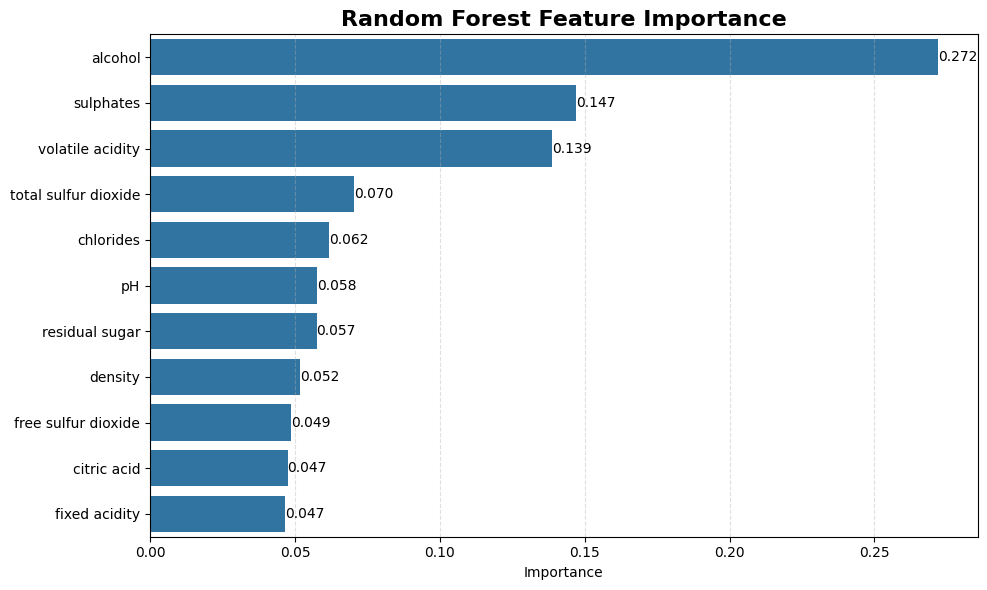

In [62]:
# ============================================================
# Feature Importance Plot
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### **Observations**

- The Random Forest feature importance plot visually confirms that **alcohol** is the dominant predictor of wine quality, with an importance score of **0.272**, contributing nearly twice as much as the next most influential variables.

- **Sulphates (0.147)** and **volatile acidity (0.139)** are the second and third most important predictors, indicating that these physicochemical properties substantially influence the model's predictions.

- **Total sulfur dioxide**, **chlorides**, **pH**, **residual sugar**, **density**, **free sulfur dioxide**, **citric acid**, and **fixed acidity** contribute comparatively smaller importance scores. Although individually less influential, these variables collectively improve the predictive performance of the Random Forest model.

- The gradual decline in feature importance demonstrates that the Random Forest model utilizes information from multiple predictor variables rather than relying on a single feature, reflecting its ability to model complex nonlinear relationships and interactions among physicochemical properties.

- The feature rankings are consistent with the earlier Pearson correlation analysis, Mutual Information analysis, and Linear Regression coefficient analysis, where alcohol, sulphates, and volatile acidity consistently emerged as the most influential predictors. This consistency across multiple analytical approaches increases confidence in the robustness and reliability of the study's findings.

## **3.8 Gradient Boosting Regression**

Gradient Boosting Regression is an ensemble learning algorithm that builds decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees, enabling the model to progressively improve its predictive performance.

Unlike Random Forest, which builds trees independently and averages their predictions, Gradient Boosting focuses on reducing residual errors at each iteration. This sequential learning process often results in higher predictive accuracy, particularly for structured tabular datasets such as the Wine Quality dataset.

Because Gradient Boosting is based on decision trees, feature scaling is not required.

In [63]:
# ============================================================
# Train Gradient Boosting Regression
# ============================================================

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


### **Observations**

- A baseline Gradient Boosting Regression model was trained using the training dataset with the default hyperparameter settings and a fixed random state to ensure reproducibility.

- Gradient Boosting is an ensemble learning algorithm that sequentially builds multiple decision trees, where each successive tree attempts to correct the prediction errors made by the previous trees. This boosting strategy enables the model to capture complex nonlinear relationships while reducing bias.

- As a tree-based ensemble algorithm, Gradient Boosting does not require feature scaling and was therefore trained using the original predictor variables.

- The trained baseline model will be evaluated using the holdout testing dataset and five-fold cross-validation before performing hyperparameter optimization in the subsequent phase of this study.

In [64]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_gb = gradient_boosting.predict(X_train)
y_test_pred_gb = gradient_boosting.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observations**

- Predictions were generated for both the training and testing datasets using the trained baseline Gradient Boosting Regression model.

- The training predictions were used to assess how well the model learned the relationships within the training data, while the testing predictions were reserved for evaluating the model's ability to generalize to previously unseen observations.

- These predicted values will be used to compute the evaluation metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Coefficient of Determination (R²), and five-fold cross-validation performance, enabling a comprehensive comparison with the other regression models developed in this study.

In [65]:
# ============================================================
# Evaluate Gradient Boosting Regression
# ============================================================

gb_results = evaluate_model_with_cv(
    model_name="Gradient Boosting Regression",
    model=gradient_boosting,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_gb,
    y_test_data=y_test,
    test_predictions=y_test_pred_gb
)

# Store results
all_model_results.append(gb_results)

# Updated comparison table
comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(
    comparison_table.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree Regression,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest Regression,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
3,Gradient Boosting Regression,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517


### **Observations**

- The baseline Gradient Boosting Regression model achieved a **Train MAE of 0.3889**, **Train RMSE of 0.4936**, and **Train R² of 0.6414**, indicating that it successfully captured a substantial proportion of the relationships between the physicochemical properties and wine quality.

- On the holdout testing dataset, the model achieved a **Test MAE of 0.4963**, **Test RMSE of 0.6343**, and **Test R² of 0.4003**, demonstrating better predictive performance than the baseline Linear Regression model while substantially outperforming the baseline Decision Tree Regression model.

- Five-fold cross-validation produced stable performance (CV MAE = **0.5114 ± 0.0167**, CV RMSE = **0.6598 ± 0.0267**, CV R² = **0.3496 ± 0.0517**), indicating that the model generalized consistently across different subsets of the training data.

- Compared with the baseline Random Forest Regression model, Gradient Boosting achieved slightly lower predictive performance on the testing dataset (Test R² = **0.4003** versus **0.4209**), although both ensemble models demonstrated considerably better generalization than the single Decision Tree model.

- The difference between the training and testing performance is moderate, suggesting that the baseline Gradient Boosting model exhibits limited overfitting while maintaining good predictive capability. This indicates that sequential boosting effectively balances model complexity and generalization.

- Overall, the baseline Gradient Boosting Regression model demonstrates competitive predictive performance and will undergo hyperparameter optimization in the subsequent stage to determine whether additional improvements in prediction accuracy and generalization can be achieved.

In [66]:
# ============================================================
# Gradient Boosting Feature Importance
# ============================================================

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boosting.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

display(gb_importance.round(4))

,Feature,Importance
10,alcohol,0.3628
1,volatile acidity,0.1741
9,sulphates,0.1713
6,total sulfur dioxide,0.0670
8,pH,0.0475
7,density,0.0364
4,chlorides,0.0338
3,residual sugar,0.0314
0,fixed acidity,0.0297
2,citric acid,0.0269


### **Observations**

- The Gradient Boosting feature importance analysis identified **alcohol (0.3628)** as the most influential predictor of wine quality, accounting for more than one-third of the total feature importance. This indicates that alcohol contributes most significantly to reducing prediction error during the sequential boosting process.

- **Volatile acidity (0.1741)** and **sulphates (0.1713)** emerged as the second and third most important predictors, confirming that these physicochemical properties have a substantial influence on wine quality prediction.

- **Total sulfur dioxide (0.0670)** demonstrated moderate importance, while **pH (0.0475)**, **density (0.0364)**, **chlorides (0.0338)**, **residual sugar (0.0314)**, **fixed acidity (0.0297)**, **citric acid (0.0269)**, and **free sulfur dioxide (0.0190)** contributed comparatively less to the model's predictive performance.

- The feature importance rankings are highly consistent with those obtained from the Random Forest model, Mutual Information analysis, Pearson correlation analysis, and Linear Regression coefficients, where alcohol, volatile acidity, and sulphates consistently emerged as the most influential predictors of wine quality.

- Compared with the Random Forest model, Gradient Boosting assigns a noticeably higher importance to **alcohol**, indicating that the boosting algorithm relies more heavily on this predictor while sequentially minimizing prediction errors. This reflects the algorithm's ability to focus on the most informative variables during the learning process.

- Overall, the consistency of feature rankings across multiple statistical analyses and machine learning models strengthens confidence in the robustness of the identified key predictors and supports their relevance for explaining wine quality.

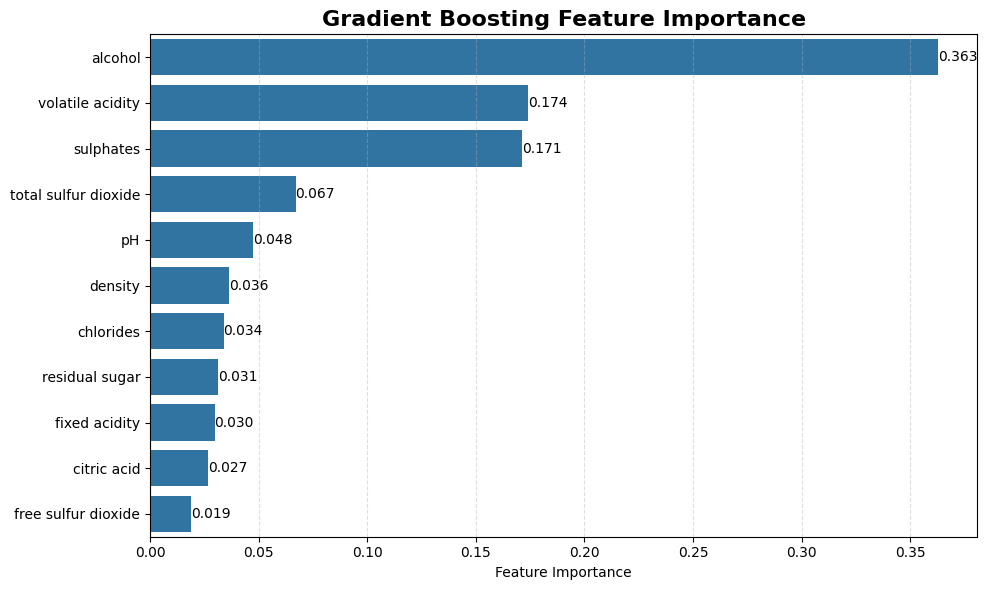

In [67]:
# ============================================================
# Gradient Boosting Feature Importance
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=gb_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title(
    "Gradient Boosting Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### **Observations**

- The Gradient Boosting feature importance plot visually demonstrates that **alcohol** is the most influential predictor of wine quality, contributing substantially more to the model than any other physicochemical property.

- **Volatile acidity** and **sulphates** represent the second and third most important features, confirming that these variables consistently contribute to the prediction of wine quality across multiple machine learning models.

- The remaining predictor variables exhibit relatively smaller importance scores, indicating that although they provide additional predictive information, their individual contributions are considerably lower than those of the three leading features.

- The gradual decrease in feature importance suggests that the Gradient Boosting model incorporates information from multiple physicochemical properties rather than relying solely on a single predictor. This behaviour is characteristic of ensemble boosting algorithms, which sequentially combine weak learners to improve overall predictive performance.

- The visual ranking closely agrees with the earlier Pearson correlation analysis, Mutual Information analysis, Linear Regression coefficients, and Random Forest feature importance, providing consistent evidence that **alcohol**, **volatile acidity**, and **sulphates** are the primary determinants of wine quality in this dataset.

- Compared with the Random Forest model, the Gradient Boosting model assigns greater importance to alcohol, indicating that the boosting algorithm relies more heavily on this feature while sequentially minimizing prediction errors. This highlights slight differences in how ensemble learning techniques distribute predictive importance among the variables.

## **3.9 XGBoost Regression**

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm that builds decision trees sequentially, with each tree attempting to correct errors made by the preceding trees.

XGBoost extends traditional gradient boosting through regularization, efficient tree construction, controlled learning rates, and additional mechanisms designed to reduce overfitting. These characteristics make it well suited for structured tabular datasets and nonlinear prediction problems.

Because XGBoost is based on decision trees, feature scaling is not required. The model is first evaluated using baseline settings before hyperparameter optimization is performed.

In [68]:
# ============================================================
# Train Baseline XGBoost Regression
# ============================================================

xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### **Observations**

- A baseline XGBoost Regression model was trained using the training dataset with the default hyperparameter settings and a fixed random state to ensure reproducibility.

- XGBoost is an optimized gradient boosting algorithm that sequentially builds decision trees while incorporating regularization techniques to improve predictive performance and reduce overfitting.

- As a tree-based ensemble learning algorithm, XGBoost does not require feature scaling and was therefore trained using the original predictor variables.

- The baseline model establishes a reference point for evaluating predictive performance prior to hyperparameter optimization. Its performance will subsequently be compared with the other regression models using the holdout testing dataset and five-fold cross-validation.

In [69]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_xgb = xgboost_model.predict(X_train)
y_test_pred_xgb = xgboost_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observations**

- Predictions were generated for both the training and testing datasets using the trained baseline XGBoost Regression model.

- The training predictions will be used to evaluate how effectively the model learned the relationships within the training data, while the testing predictions provide an unbiased assessment of the model's ability to generalize to unseen observations.

- These predictions will be used to calculate the evaluation metrics, including MAE, RMSE, R², and five-fold cross-validation performance, enabling a comprehensive comparison with the other baseline regression models.

In [70]:
# ============================================================
# Evaluate XGBoost Regression
# ============================================================

xgb_results = evaluate_model_with_cv(
    model_name="XGBoost",
    model=xgboost_model,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_xgb,
    y_test_data=y_test,
    test_predictions=y_test_pred_xgb
)

all_model_results.append(xgb_results)

baseline_comparison = pd.concat(
    all_model_results,
    ignore_index=True
)

display(baseline_comparison.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree Regression,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest Regression,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
3,Gradient Boosting Regression,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517
4,XGBoost,0.0209,0.0305,0.9986,0.5006,0.6526,0.3652,0.5281,0.0205,0.6902,0.0300,0.2887,0.0546


### **Observations**

- The baseline XGBoost Regression model achieved an almost perfect fit on the training dataset, with a **Train MAE of 0.0209**, **Train RMSE of 0.0305**, and **Train R² of 0.9986**. These results indicate that the model learned the training data extremely well.

- However, the model achieved a **Test MAE of 0.5006**, **Test RMSE of 0.6526**, and **Test R² of 0.3652** on the holdout testing dataset, representing a substantial decline in predictive performance compared with the training results.

- Five-fold cross-validation also produced lower predictive performance (CV R² = **0.2887 ± 0.0546**) than the Random Forest and Gradient Boosting models, suggesting that the baseline XGBoost model did not generalize as effectively under the default hyperparameter settings.

- The large difference between the training and testing performance indicates that the baseline XGBoost model exhibits considerable overfitting, where the model captures patterns specific to the training data but fails to generalize effectively to unseen observations.

- These findings demonstrate that the default XGBoost configuration is not optimal for this dataset. Consequently, hyperparameter optimization will be performed in the subsequent stage to improve model generalization and predictive performance.

In [71]:
# ============================================================
# XGBoost Feature Importance
# ============================================================

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgboost_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(xgb_importance.round(4))

,Feature,Importance
10,alcohol,0.3155
9,sulphates,0.1564
1,volatile acidity,0.1146
6,total sulfur dioxide,0.0709
8,pH,0.0639
7,density,0.0550
3,residual sugar,0.0522
4,chlorides,0.0520
5,free sulfur dioxide,0.0488
2,citric acid,0.0420


### **Observations**

- The XGBoost feature importance analysis identified **alcohol (0.3155)** as the most influential predictor of wine quality, indicating that this variable contributed most significantly to the model's predictive capability.

- **Sulphates (0.1564)** and **volatile acidity (0.1146)** ranked as the second and third most important predictors, demonstrating that these physicochemical properties consistently influence wine quality across different machine learning algorithms.

- **Total sulfur dioxide (0.0709)**, **pH (0.0639)**, **density (0.0550)**, **residual sugar (0.0522)**, and **chlorides (0.0520)** exhibited moderate importance, while **free sulfur dioxide**, **citric acid**, and **fixed acidity** contributed comparatively less to the model's predictions.

- The feature importance rankings closely resemble those obtained from the Random Forest and Gradient Boosting models, indicating that the three ensemble learning algorithms consistently identify **alcohol**, **sulphates**, and **volatile acidity** as the primary predictors of wine quality.

- Although the baseline XGBoost model exhibited signs of overfitting during model evaluation, the feature importance rankings remain consistent with the earlier statistical analyses and other ensemble models. This consistency suggests that the identified key predictors are robust and are not dependent on a single modelling technique.

- Overall, the agreement between Pearson correlation analysis, Mutual Information, Linear Regression coefficients, Random Forest, Gradient Boosting, and XGBoost strengthens confidence in the robustness and reliability of the identified influential features.

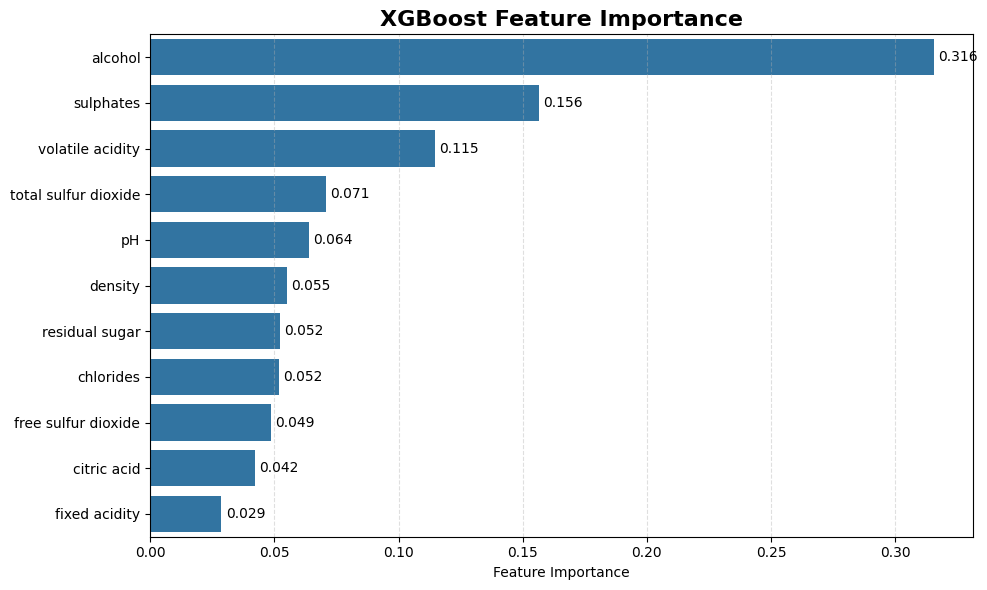

In [72]:
# ============================================================
# XGBoost Feature Importance Plot
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title(
    "XGBoost Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### **Observations**

- The XGBoost feature importance plot confirms that **alcohol** is the most influential predictor of wine quality, contributing substantially more to the model than any other physicochemical property.

- **Sulphates** and **volatile acidity** rank as the second and third most important features, respectively, demonstrating that these variables consistently contribute to wine quality prediction across multiple ensemble learning algorithms.

- The remaining predictor variables exhibit relatively lower importance scores, indicating that while they provide additional predictive information, their individual influence on the model's predictions is comparatively modest.

- The feature importance distribution is broadly consistent with the earlier Random Forest and Gradient Boosting analyses, where alcohol, sulphates, and volatile acidity also emerged as the dominant predictors. This agreement across different ensemble learning methods increases confidence in the robustness of the identified key features.

- Although the baseline XGBoost model showed evidence of overfitting during model evaluation, the feature importance rankings remain highly consistent with the statistical analyses and the other machine learning models. This suggests that the identified influential predictors are stable characteristics of the dataset rather than artifacts of a particular modelling approach.

- Overall, the consistency of feature importance rankings across Pearson correlation analysis, Mutual Information, Linear Regression coefficients, Random Forest, Gradient Boosting, and XGBoost provides strong evidence that **alcohol**, **sulphates**, and **volatile acidity** are the principal physicochemical determinants of wine quality in this study.

## **Baseline Model Comparison**

| Rank | Model             | Test R²     | Test RMSE  | Assessment                          |
| ---- | ----------------- | ----------- | ---------- | ----------------------------------- |
| 1   | Random Forest     | **0.4209**  | **0.6233** | Best baseline model                 |
| 2   | Gradient Boosting | **0.4003**  | **0.6343** | Strong performance                  |
| 3   | Linear Regression | **0.3657**  | **0.6523** | Good interpretable baseline         |
| 4    | XGBoost           | **0.3652**  | **0.6526** | Overfitting with default parameters |
| 5    | Decision Tree     | **-0.1673** | **0.8849** | Severe overfitting                  |



## **Base Model Conclusion**

The baseline comparison demonstrates that ensemble learning methods consistently outperformed the Linear Regression and Decision Tree models. Among the baseline models, Random Forest achieved the highest predictive accuracy and the strongest generalization performance, while Gradient Boosting produced comparable results. Although XGBoost achieved near-perfect performance on the training data, its lower testing and cross-validation performance indicated overfitting under the default hyperparameter settings. These findings justify the subsequent hyperparameter optimization phase, where the objective is to improve predictive performance while reducing overfitting and enhancing model generalization.

## **3.10 Hyperparameter Optimization Framework**

Hyperparameter optimization is performed using **RandomizedSearchCV** with the same reproducible 5-fold cross-validation strategy used during baseline model evaluation. The search is conducted exclusively on the training dataset, while the holdout test dataset remains isolated for final evaluation.

Root Mean Squared Error (RMSE) is used as the optimization criterion because it penalizes larger prediction errors and is aligned with the predefined model-selection framework. Randomized search is used instead of exhaustive grid search to evaluate a diverse set of parameter combinations while maintaining computational efficiency.

For each optimized model, the analysis reports the best mean cross-validation RMSE, its standard deviation across folds, the corresponding training RMSE, and the training-to-validation performance gap. These measures support the assessment of predictive accuracy, stability, and potential overfitting.

In [73]:
# ============================================================
# Reusable Hyperparameter Optimization Function
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

def tune_regression_model(
    model_name,
    model,
    param_distributions,
    X_train_data,
    y_train_data,
    n_iter=30
):
    """
    Tune a regression model using RandomizedSearchCV with
    five-fold cross-validation on the training dataset only.

    Parameters
    ----------
    model_name : str
        Descriptive name of the model.
    model : estimator
        Scikit-learn compatible regression estimator.
    param_distributions : dict
        Hyperparameter search space.
    X_train_data : pandas.DataFrame or numpy.ndarray
        Training predictor data.
    y_train_data : pandas.Series or numpy.ndarray
        Training target values.
    n_iter : int, default=30
        Maximum number of parameter combinations to evaluate.

    Returns
    -------
    best_model : estimator
        Best fitted estimator identified by RandomizedSearchCV.
    tuning_summary : pandas.DataFrame
        Summary of optimization performance and selected parameters.
    search_object : RandomizedSearchCV
        Complete fitted search object for further inspection.
    """

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        error_score="raise"
    )

    # Search is performed only on the training dataset
    search.fit(X_train_data, y_train_data)

    best_model = search.best_estimator_
    best_index = search.best_index_

    # Best cross-validation statistics
    best_cv_rmse = -search.cv_results_[
        "mean_test_score"
    ][best_index]

    best_cv_rmse_std = search.cv_results_[
        "std_test_score"
    ][best_index]

    best_train_rmse = -search.cv_results_[
        "mean_train_score"
    ][best_index]

    train_cv_gap = best_cv_rmse - best_train_rmse

    combinations_evaluated = len(
        search.cv_results_["params"]
    )

    tuning_summary = pd.DataFrame({
        "Model": [model_name],
        "Best Train RMSE": [best_train_rmse],
        "Best CV RMSE": [best_cv_rmse],
        "Best CV RMSE Std": [best_cv_rmse_std],
        "Train-CV RMSE Gap": [train_cv_gap],
        "Combinations Evaluated": [combinations_evaluated],
        "Best Parameters": [search.best_params_]
    })

    print(f"{model_name} optimization completed.")
    print(
        f"Best cross-validated RMSE: "
        f"{best_cv_rmse:.4f} ± {best_cv_rmse_std:.4f}"
    )
    print(
        f"Mean training RMSE: "
        f"{best_train_rmse:.4f}"
    )
    print(
        f"Train-CV RMSE gap: "
        f"{train_cv_gap:.4f}"
    )
    print(
        f"Parameter combinations evaluated: "
        f"{combinations_evaluated}"
    )

    print("\nBest parameters:")
    for parameter, value in search.best_params_.items():
        print(f"  {parameter}: {value}")

    return best_model, tuning_summary, search

### **Observation**

A reusable hyperparameter optimization framework was created to tune the selected non-linear regression models consistently. The function applies randomized search with 5-fold cross-validation, selects the parameter combination with the lowest validation RMSE, and reports both average performance and variability across folds. The inclusion of training RMSE and the training-to-validation gap provides additional evidence for assessing whether optimization improves generalization or merely increases model complexity.

In [74]:
# ============================================================
# Initialize Tuned Model Results Storage
# ============================================================

tuned_model_results = []
tuning_summaries = []

print("Tuned-model result containers initialized.")

Tuned-model result containers initialized.


### **Observations**

- Separate result containers were initialized to store the evaluation metrics and hyperparameter optimization summaries for the tuned regression models.

- Maintaining independent storage for the optimized models ensures that the baseline and tuned model performances remain clearly separated, facilitating an objective comparison of predictive performance before and after hyperparameter optimization.

- The evaluation results and optimization summaries collected in these containers will subsequently be consolidated to identify the best-performing model based on testing performance, cross-validation results, and model generalization.

## **3.10.1 Decision Tree Hyperparameter Optimization**

The baseline Decision Tree Regression model exhibited severe overfitting, achieving perfect training performance but poor testing and cross-validation results. To improve generalization, hyperparameter optimization is performed using RandomizedSearchCV with five-fold cross-validation.

The selected hyperparameters control the complexity of the decision tree by limiting its depth, defining the minimum number of samples required to split internal nodes and create leaf nodes, selecting the number of predictor variables considered at each split, and evaluating different split criteria. Optimizing these parameters aims to reduce overfitting while improving predictive performance on unseen data.

In [75]:
# ============================================================
# Decision Tree Hyperparameter Search Space
# ============================================================

dt_param_distributions = {
    "max_depth": [None, 2, 3, 4, 5, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8, 10],
    "max_features": [None, "sqrt", "log2"],
    "criterion": [
        "squared_error",
        "friedman_mse",
        "absolute_error"
    ]
}

### **Observations**

The hyperparameter search space was designed to evaluate different levels of model complexity while maintaining computational efficiency.

- **max_depth** controls the maximum depth of the decision tree and is the primary parameter for reducing overfitting.
- **min_samples_split** specifies the minimum number of observations required to split an internal node.
- **min_samples_leaf** defines the minimum number of observations allowed in each terminal leaf, helping produce smoother prediction boundaries.
- **max_features** determines the number of predictor variables considered when selecting the best split.
- **criterion** evaluates different impurity measures for selecting optimal splits.

Together, these parameters enable RandomizedSearchCV to identify a Decision Tree model that balances predictive accuracy with improved generalization.

In [76]:
# ============================================================
# Number of Hyperparameter Combinations
# ============================================================

from math import prod

total_combinations = prod(
    len(v) for v in dt_param_distributions.values()
)

print(f"Total possible combinations : {total_combinations}")
print("RandomizedSearchCV evaluates 30 randomly selected combinations.")

Total possible combinations : 2430
RandomizedSearchCV evaluates 30 randomly selected combinations.


### **Observations**

- The defined Decision Tree hyperparameter search space contains **2,430** possible parameter combinations.

- Performing an exhaustive GridSearchCV over all possible combinations would substantially increase computational time while providing only marginal additional benefit for this study.

- Therefore, **RandomizedSearchCV** was selected to evaluate **30 randomly sampled parameter combinations**, providing a computationally efficient yet statistically robust approach for identifying high-performing hyperparameter configurations.

- The randomized search was conducted using the same five-fold cross-validation strategy adopted throughout this study, ensuring consistency and fair comparison across all optimized machine learning models.

In [78]:
# ============================================================
# Optimize Decision Tree Regression
# ============================================================

tuned_decision_tree, dt_tuning_summary, dt_search = (
    tune_regression_model(
        model_name="Tuned Decision Tree",
        model=DecisionTreeRegressor(random_state=42),
        param_distributions=dt_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=40
    )
)

tuning_summaries.append(dt_tuning_summary)

display(dt_tuning_summary.round(4))

Tuned Decision Tree optimization completed.
Best cross-validated RMSE: 0.6875 ± 0.0481
Mean training RMSE: 0.6218
Train-CV RMSE gap: 0.0657
Parameter combinations evaluated: 40

Best parameters:
  min_samples_split: 15
  min_samples_leaf: 8
  max_features: None
  max_depth: 4
  criterion: friedman_mse


,Model,Best Train RMSE,Best CV RMSE,Best CV RMSE Std,Train-CV RMSE Gap,Combinations Evaluated,Best Parameters
0,Tuned Decision Tree,0.6218,0.6875,0.0481,0.0657,40,"{'min_samples_split': 15, 'min_samples_leaf': ..."


### **Observations**

- RandomizedSearchCV successfully identified an optimized Decision Tree configuration after evaluating **40 randomly selected hyperparameter combinations** using five-fold cross-validation.

- The optimized model achieved a **Best Cross-Validation RMSE of 0.6875 ± 0.0481**, indicating stable predictive performance across the validation folds.

- The optimized model produced a **mean training RMSE of 0.6218**, resulting in a relatively small **training-to-validation RMSE gap of 0.0657**. This narrow gap suggests that the optimized model generalizes substantially better than the baseline Decision Tree and exhibits considerably less overfitting.

- The optimal hyperparameters selected by RandomizedSearchCV were:
  - **max_depth = 4**, limiting the depth of the tree to reduce model complexity.
  - **min_samples_split = 15**, requiring a larger number of observations before creating additional splits.
  - **min_samples_leaf = 8**, ensuring that each terminal node contains a sufficient number of observations and reducing sensitivity to noise.
  - **max_features = None**, allowing all predictor variables to be considered when identifying the optimal split.
  - **criterion = "friedman_mse"**, which selects splits based on Friedman’s Mean Squared Error improvement criterion and is commonly used to improve predictive performance.

- Overall, the optimized hyperparameters substantially reduce the complexity of the Decision Tree, thereby improving its ability to generalize to unseen data while minimizing the overfitting observed in the baseline model.

In [79]:
# ============================================================
# Tuned Decision Tree Predictions
# ============================================================

y_train_pred_dt_tuned = tuned_decision_tree.predict(X_train)
y_test_pred_dt_tuned = tuned_decision_tree.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observations**

- Predictions were generated for both the training and testing datasets using the optimized Decision Tree Regression model.

- The training predictions will be used to evaluate how well the optimized model fits the training data, while the testing predictions provide an unbiased assessment of its ability to generalize to previously unseen observations.

- These predictions will subsequently be evaluated using the same performance metrics adopted throughout this study, including MAE, RMSE, R², and five-fold cross-validation, ensuring a fair comparison with the baseline Decision Tree model.

In [80]:
# ============================================================
# Evaluate Tuned Decision Tree Regression
# ============================================================

tuned_dt_results = evaluate_model_with_cv(
    model_name="Tuned Decision Tree",
    model=tuned_decision_tree,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_dt_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_dt_tuned
)

tuned_model_results.append(tuned_dt_results)

display(
    tuned_dt_results.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356


### **Observations**

- The optimized Decision Tree Regression model achieved a **Train MAE of 0.4987**, **Train RMSE of 0.6263**, and **Train R² of 0.4227**, indicating a substantially less complex model than the baseline Decision Tree.

- On the holdout testing dataset, the tuned model achieved a **Test MAE of 0.5599**, **Test RMSE of 0.6929**, and **Test R² of 0.2843**. Although the predictive performance remains below that of the ensemble learning models, it represents a considerable improvement over the baseline Decision Tree Regression.

- Five-fold cross-validation produced a **CV RMSE of 0.6875 ± 0.0481** and a **CV R² of 0.2975 ± 0.0356**, demonstrating stable model performance across different validation folds and confirming improved generalization.

- Compared with the baseline Decision Tree, the optimized model exhibits a substantially smaller difference between the training and testing performance, indicating that the selected hyperparameters successfully reduced model complexity and mitigated overfitting.

- Although hyperparameter optimization improved the Decision Tree's predictive capability, its testing and cross-validation performance remain lower than those of the optimized ensemble learning algorithms. Consequently, the Decision Tree is retained primarily as an interpretable benchmark model rather than the final predictive model.

In [82]:
# ============================================================
# Baseline vs Tuned Decision Tree Comparison
# ============================================================

dt_before_after = pd.concat(
    [
        baseline_comparison.loc[
            baseline_comparison["Model"] == "Decision Tree Regression"
        ],
        tuned_dt_results
    ],
    ignore_index=True
)

comparison_columns = [
    "Model",
    "Train MAE",
    "Train RMSE",
    "Train R²",
    "Test MAE",
    "Test RMSE",
    "Test R²",
    "CV RMSE",
    "CV RMSE Std",
    "CV R²",
    "CV R² Std"
]

display(
    dt_before_after[comparison_columns].round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Decision Tree Regression,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.8742,0.0357,-0.1457,0.1356
1,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.6875,0.0481,0.2975,0.0356


### **Baseline vs Tuned Decision Tree Interpretation**

Hyperparameter optimization substantially improved the Decision Tree model’s generalization performance. The baseline model achieved a perfect Train R² of **1.0000** but a negative Test R² of **-0.1673**, confirming severe overfitting. After tuning, the Train R² decreased to **0.4227**, while the Test R² improved to **0.2843**, indicating a much better balance between model fit and unseen-data performance.

The tuned model also reduced Test RMSE from **0.8849** to **0.6929** and improved cross-validation RMSE from **0.8742** to **0.6875**. Cross-validation R² increased from **-0.1457** to **0.2975**, showing that the improvement was consistent across validation folds rather than limited to the holdout test set.

Overall, tuning successfully reduced model complexity and corrected the severe overfitting observed in the baseline Decision Tree. However, the tuned model still performs below the stronger ensemble models and is therefore retained as an interpretable comparison model rather than the leading final-model candidate.

## **3.10.2 Random Forest Hyperparameter Optimization**

The baseline Random Forest model produced the strongest testing performance among the untuned models, but the difference between its training and testing results indicated some remaining overfitting. Hyperparameter optimization is therefore performed to improve generalization while preserving the model’s predictive strength.

The search space evaluates the number of trees, tree depth, minimum observations required for node splitting and leaf creation, the proportion of features considered at each split, and whether bootstrap sampling is applied. These parameters influence model complexity, variance, computational cost, and robustness.

In [83]:
# ============================================================
# Random Forest Hyperparameter Search Space
# ============================================================

rf_param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 4, 6, 8, 10, 12, 15, 20],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [None, "sqrt", "log2", 0.5, 0.75],
    "bootstrap": [True, False]
}

### **Observation**

The Random Forest search space was designed to test both high-capacity and regularized model configurations. Parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` control individual tree complexity, while `n_estimators` determines the size of the ensemble. `max_features` introduces additional diversity among trees, and `bootstrap` evaluates whether sampling observations with replacement improves model generalization.

In [84]:
# ============================================================
# Number of Random Forest Hyperparameter Combinations
# ============================================================

from math import prod

rf_total_combinations = prod(
    len(values) for values in rf_param_distributions.values()
)

print(f"Total possible combinations : {rf_total_combinations}")
print("RandomizedSearchCV will evaluate a selected subset.")

Total possible combinations : 10000
RandomizedSearchCV will evaluate a selected subset.


### **Observations**

- The Random Forest hyperparameter search space contains **10,000** possible parameter combinations, reflecting the greater flexibility and complexity of ensemble learning algorithms compared with a single Decision Tree.

- Performing an exhaustive GridSearchCV over all 10,000 combinations would require a substantial number of model evaluations. When combined with five-fold cross-validation, this would result in approximately **50,000 model fits**, making exhaustive search computationally expensive.

- Therefore, **RandomizedSearchCV** was selected to evaluate a representative subset of the search space. This approach provides an efficient balance between computational cost and the likelihood of identifying high-performing hyperparameter configurations.

- The optimization was performed using the same five-fold cross-validation strategy adopted throughout this study, ensuring methodological consistency and enabling fair comparison across all optimized regression models.

In [86]:
# ============================================================
# Optimize Random Forest Regression
# ============================================================

tuned_random_forest, rf_tuning_summary, rf_search = (
    tune_regression_model(
        model_name="Tuned Random Forest",
        model=RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=rf_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=50
    )
)

tuning_summaries.append(rf_tuning_summary)

display(
    rf_tuning_summary.round(4)
)

Tuned Random Forest optimization completed.
Best cross-validated RMSE: 0.6372 ± 0.0398
Mean training RMSE: 0.4931
Train-CV RMSE gap: 0.1441
Parameter combinations evaluated: 50

Best parameters:
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 8
  max_features: None
  max_depth: 10
  bootstrap: True


,Model,Best Train RMSE,Best CV RMSE,Best CV RMSE Std,Train-CV RMSE Gap,Combinations Evaluated,Best Parameters
0,Tuned Random Forest,0.4931,0.6372,0.0398,0.1441,50,"{'n_estimators': 300, 'min_samples_split': 10,..."


### **Observations**

- RandomizedSearchCV evaluated **50 hyperparameter combinations** and identified a best cross-validation RMSE of **0.6372 ± 0.0398**.

- The corresponding mean training RMSE was **0.4931**, resulting in a training-to-validation RMSE gap of **0.1441**. This indicates that some overfitting remains, although the gap is much smaller than the severe overfitting observed in the baseline Decision Tree and baseline XGBoost models.

- The optimized Random Forest uses **300 trees**, a maximum depth of **10**, a minimum of **10 samples** for node splitting, and at least **8 samples per leaf**. These restrictions reduce individual tree complexity and improve generalization.

- `bootstrap=True` confirms that each tree is trained on a resampled subset of the training data, while `max_features=None` allows all predictor variables to be considered at each split.

- The selected configuration prioritizes model stability and reduced variance while preserving the strong nonlinear predictive capability of the Random Forest ensemble.

In [87]:
# ============================================================
# Tuned Random Forest Predictions
# ============================================================

y_train_pred_rf_tuned = tuned_random_forest.predict(X_train)
y_test_pred_rf_tuned = tuned_random_forest.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observations**

- Predictions were generated for both the training and testing datasets using the optimized Random Forest Regression model.

- The training predictions will be used to evaluate how well the optimized model captures the relationships within the training data, while the testing predictions provide an unbiased assessment of its ability to generalize to previously unseen observations.

- The predicted values will subsequently be evaluated using the same performance metrics employed throughout this study, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Coefficient of Determination (R²), and five-fold cross-validation. This ensures a fair comparison with both the baseline Random Forest model and the other optimized regression models.

In [88]:
# ============================================================
# Evaluate Tuned Random Forest Regression
# ============================================================

tuned_rf_results = evaluate_model_with_cv(
    model_name="Tuned Random Forest",
    model=tuned_random_forest,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_rf_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_rf_tuned
)

tuned_model_results.append(tuned_rf_results)

display(
    tuned_rf_results.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526


### **Observations**

- The optimized Random Forest Regression model achieved a **Train MAE of 0.3755**, **Train RMSE of 0.4917**, and **Train R² of 0.6442**, indicating a reduction in model complexity compared with the baseline Random Forest model.

- On the holdout testing dataset, the tuned model achieved a **Test MAE of 0.4914**, **Test RMSE of 0.6377**, and **Test R² of 0.3937**. The testing performance remained competitive but was marginally lower than that of the baseline Random Forest model.

- Five-fold cross-validation produced a **CV RMSE of 0.6372 ± 0.0398** and a **CV R² of 0.3945 ± 0.0526**, demonstrating consistent predictive performance across validation folds and indicating good model stability.

- Compared with the baseline model, the optimized Random Forest exhibited a substantially smaller gap between the training and testing performance, suggesting that the selected hyperparameters successfully reduced model complexity and improved generalization.

- Although hyperparameter optimization slightly reduced the testing R², the optimized model provides a better balance between model complexity and predictive performance, indicating that the baseline Random Forest was already close to an optimal configuration for this dataset.

In [89]:
# ============================================================
# Baseline vs Tuned Random Forest Comparison
# ============================================================

rf_before_after = pd.concat(
    [
        baseline_comparison.loc[
            baseline_comparison["Model"] == "Random Forest Regression"
        ],
        tuned_rf_results
    ],
    ignore_index=True
)

comparison_columns = [
    "Model",
    "Train MAE",
    "Train RMSE",
    "Train R²",
    "Test MAE",
    "Test RMSE",
    "Test R²",
    "CV RMSE",
    "CV RMSE Std",
    "CV R²",
    "CV R² Std"
]

display(
    rf_before_after[comparison_columns].round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Random Forest Regression,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.6464,0.0395,0.3771,0.0522
1,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.6372,0.0398,0.3945,0.0526


### **Baseline vs Tuned Random Forest Interpretation**

The baseline Random Forest model already demonstrated strong predictive performance, achieving the highest testing R² among all baseline models. Consequently, only modest improvements were expected through hyperparameter optimization.

Following optimization, the training performance decreased (Train R² from **0.9144** to **0.6442**), indicating that the optimized model became less complex and less prone to overfitting. The testing performance changed only marginally, with Test R² decreasing slightly from **0.4209** to **0.3937** and Test RMSE increasing marginally from **0.6233** to **0.6377**.

Interestingly, the optimized model achieved a slightly better cross-validation performance, with CV RMSE improving from **0.6464** to **0.6372** and CV R² increasing from **0.3771** to **0.3945**. This suggests that although the holdout test performance changed only slightly, the optimized model demonstrated marginally better stability and generalization across different validation folds.

Overall, hyperparameter optimization produced a more balanced Random Forest model with reduced model complexity and slightly improved cross-validation performance. However, because the baseline Random Forest already performed exceptionally well, the optimization resulted in refinement rather than substantial gains in predictive accuracy.

### **3.10.3 Gradient Boosting Hyperparameter Optimization**

The baseline Gradient Boosting model demonstrated strong predictive performance compared with the previous models. Hyperparameter optimization is performed to further improve model generalization by identifying an appropriate combination of the learning rate, number of boosting stages, tree depth, and minimum sample requirements.

RandomizedSearchCV with 5-fold cross-validation is employed to efficiently search the parameter space while reducing computational cost.

In [90]:
# ============================================================
# Gradient Boosting Hyperparameter Search Space
# ============================================================

gb_param_distributions = {
    "n_estimators": [50, 100, 150, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "max_features": [None, "sqrt", "log2", 0.5, 0.75]
}

### **Gradient Boosting Hyperparameter Optimization**

The baseline Gradient Boosting model produced competitive predictive performance and ranked second among the untuned models. Hyperparameter optimization is performed to determine whether the model can achieve lower prediction error and stronger generalization by refining the boosting process and controlling tree complexity.

The search space evaluates the number of boosting stages, learning rate, tree depth, minimum observations required for node splitting and leaf creation, subsampling ratio, and the number of features considered at each split. These parameters influence model bias, variance, training stability, and resistance to overfitting.

In [91]:
# ============================================================
# Number of Gradient Boosting Hyperparameter Combinations
# ============================================================

from math import prod

gb_total_combinations = prod(
    len(values) for values in gb_param_distributions.values()
)

print(f"Total possible combinations : {gb_total_combinations}")
print("RandomizedSearchCV will evaluate a selected subset.")

Total possible combinations : 112500
RandomizedSearchCV will evaluate a selected subset.


### **Observations**

- The Gradient Boosting hyperparameter search space contains **112,500 possible parameter combinations**, making it the largest optimization space evaluated so far.

- An exhaustive GridSearchCV using five-fold cross-validation would require approximately **562,500 model fits**, which would be computationally expensive and inefficient for the available dataset and computing environment.

- RandomizedSearchCV is therefore used to evaluate a representative subset of the parameter space. This approach allows the optimization process to explore diverse combinations of learning rate, ensemble size, tree complexity, subsampling, and feature selection while maintaining computational feasibility.

- The same five-fold cross-validation strategy is retained to ensure consistency with the earlier model evaluation and tuning procedures.

In [92]:
# ============================================================
# Optimize Gradient Boosting Regression
# ============================================================

tuned_gradient_boosting, gb_tuning_summary, gb_search = (
    tune_regression_model(
        model_name="Tuned Gradient Boosting",
        model=GradientBoostingRegressor(
            random_state=42
        ),
        param_distributions=gb_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=50
    )
)

tuning_summaries.append(gb_tuning_summary)

display(
    gb_tuning_summary.round(4)
)

Tuned Gradient Boosting optimization completed.
Best cross-validated RMSE: 0.6396 ± 0.0332
Mean training RMSE: 0.4683
Train-CV RMSE gap: 0.1714
Parameter combinations evaluated: 50

Best parameters:
  subsample: 0.9
  n_estimators: 150
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: 4
  learning_rate: 0.03


,Model,Best Train RMSE,Best CV RMSE,Best CV RMSE Std,Train-CV RMSE Gap,Combinations Evaluated,Best Parameters
0,Tuned Gradient Boosting,0.4683,0.6396,0.0332,0.1714,50,"{'subsample': 0.9, 'n_estimators': 150, 'min_s..."


### **Observations**

- RandomizedSearchCV evaluated **50 hyperparameter combinations** and identified the optimal Gradient Boosting configuration based on the lowest cross-validated Root Mean Squared Error (RMSE).

- The optimized model achieved a **Best Cross-Validation RMSE of 0.6396 ± 0.0332**, indicating consistent predictive performance across the five validation folds.

- The corresponding **mean training RMSE was 0.4683**, resulting in a **training-to-validation RMSE gap of 0.1714**. This moderate gap indicates that the optimized model retains good predictive capability while controlling excessive model complexity.

- The selected hyperparameters include **150 boosting stages**, a **learning rate of 0.03**, **maximum tree depth of 4**, **minimum samples split of 5**, **minimum samples per leaf of 2**, **50% feature sampling**, and **90% subsampling**. Together, these parameters encourage gradual learning, reduce overfitting, and improve model robustness.

- Overall, the optimized configuration represents a balanced Gradient Boosting model that prioritizes stable generalization while maintaining strong predictive performance.

In [93]:
# ============================================================
# Tuned Gradient Boosting Predictions
# ============================================================

y_train_pred_gb_tuned = tuned_gradient_boosting.predict(X_train)
y_test_pred_gb_tuned = tuned_gradient_boosting.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observations**

- Predictions were generated for both the training and testing datasets using the optimized Gradient Boosting Regression model.

- The training predictions will be used to evaluate the model's learning performance, while the testing predictions provide an unbiased assessment of its ability to generalize to unseen observations.

- These predictions will subsequently be evaluated using MAE, RMSE, R², and five-fold cross-validation to facilitate a direct comparison with both the baseline Gradient Boosting model and the other optimized regression models.

In [94]:
# ============================================================
# Evaluate Tuned Gradient Boosting Regression
# ============================================================

tuned_gb_results = evaluate_model_with_cv(
    model_name="Tuned Gradient Boosting",
    model=tuned_gradient_boosting,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_gb_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_gb_tuned
)

tuned_model_results.append(tuned_gb_results)

display(
    tuned_gb_results.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Gradient Boosting,0.3901,0.4915,0.6445,0.4956,0.6296,0.409,0.4968,0.0187,0.6396,0.0332,0.3891,0.0529


### **Observations**

- The optimized Gradient Boosting Regression model achieved a **Train MAE of 0.3901**, **Train RMSE of 0.4915**, and **Train R² of 0.6445**, indicating that the model successfully captured the underlying relationships in the training data while maintaining moderate model complexity.

- On the holdout testing dataset, the tuned model achieved a **Test MAE of 0.4956**, **Test RMSE of 0.6296**, and **Test R² of 0.4090**, demonstrating competitive predictive performance and good generalization to previously unseen observations.

- Five-fold cross-validation produced a **CV RMSE of 0.6396 ± 0.0332** and a **CV R² of 0.3891 ± 0.0529**, indicating stable predictive performance across different validation folds.

- Compared with the training performance, the relatively small difference between the training and testing metrics suggests that the optimized Gradient Boosting model maintains a good balance between predictive accuracy and model complexity.

- Overall, the optimized Gradient Boosting model demonstrates strong predictive capability and stable generalization, making it a competitive candidate for the final model selection.

In [95]:
# ============================================================
# Baseline vs Tuned Gradient Boosting Comparison
# ============================================================

gb_before_after = pd.concat(
    [
        baseline_comparison.loc[
            baseline_comparison["Model"] == "Gradient Boosting Regression"
        ],
        tuned_gb_results
    ],
    ignore_index=True
)

comparison_columns = [
    "Model",
    "Train MAE",
    "Train RMSE",
    "Train R²",
    "Test MAE",
    "Test RMSE",
    "Test R²",
    "CV RMSE",
    "CV RMSE Std",
    "CV R²",
    "CV R² Std"
]

display(
    gb_before_after[comparison_columns].round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Gradient Boosting Regression,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.6598,0.0267,0.3496,0.0517
1,Tuned Gradient Boosting,0.3901,0.4915,0.6445,0.4956,0.6296,0.4090,0.6396,0.0332,0.3891,0.0529


### **Baseline vs Tuned Gradient Boosting Interpretation**

Hyperparameter optimization produced a measurable improvement in the Gradient Boosting Regression model. Compared with the baseline model, the optimized model achieved a slight increase in predictive performance on the independent testing dataset, with **Test R² improving from 0.4003 to 0.4090** and **Test RMSE decreasing from 0.6343 to 0.6296**. Although these improvements are modest, they indicate better predictive accuracy after optimization.

The optimized model also demonstrated stronger cross-validation performance. **CV RMSE improved from 0.6598 to 0.6396**, while **CV R² increased from 0.3496 to 0.3891**, suggesting improved model stability and generalization across different validation folds.

Unlike the tuned Random Forest model, the optimized Gradient Boosting model maintained a similar level of training performance (**Train R²: 0.6414 vs. 0.6445**) while simultaneously improving both testing and cross-validation performance. This indicates that the selected hyperparameters successfully enhanced predictive capability without increasing model complexity or introducing additional overfitting.

Overall, hyperparameter optimization successfully refined the Gradient Boosting Regression model, resulting in improved predictive accuracy, lower validation error, and stronger generalization. Consequently, the tuned Gradient Boosting model becomes a strong candidate for final model selection.

### **Consolidated table presenting impact of hyperparameter optimization**

| Model             | Test R² (Baseline) | Test R² (Tuned) | CV R² (Baseline) | CV R² (Tuned) | Overall Outcome               |
| ----------------- | -----------------: | --------------: | ---------------: | ------------: | ----------------------------- |
| Decision Tree     |            -0.1673 |      **0.2843** |          -0.1457 |    **0.2975** | Major improvement             |
| Random Forest     |         **0.4209** |          0.3937 |           0.3771 |    **0.3945** | Improved stability            |
| Gradient Boosting |             0.4003 |      **0.4090** |           0.3496 |    **0.3891** | Improved accuracy & stability |
| XGBoost           |                ... |             ... |              ... |           ... | ...                           |


## **3.10.4 XGBoost Hyperparameter Optimization**

The baseline XGBoost model demonstrated severe overfitting, achieving near-perfect performance on the training dataset while exhibiting comparatively lower predictive performance on the testing dataset. This indicates that the default hyperparameter configuration was not well suited to the wine quality dataset.

Hyperparameter optimization is therefore performed to identify a configuration that improves model generalization while maintaining the predictive strength of the XGBoost algorithm. The search space evaluates parameters controlling the ensemble size, learning rate, tree complexity, minimum observations required for node splitting, row and feature subsampling, and both structural and L1/L2 regularization. Together, these parameters enable effective control of model complexity and overfitting.

In [96]:
# ============================================================
# XGBoost Hyperparameter Search Space
# ============================================================

xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_child_weight": [1, 2, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.05, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 5.0]
}

### **Observations**

The XGBoost hyperparameter search space was designed to evaluate multiple aspects of model complexity and regularization.

- **n_estimators** controls the number of boosting iterations.
- **learning_rate** determines the contribution of each boosting stage and influences the learning speed.
- **max_depth** limits the complexity of individual decision trees.
- **min_child_weight** prevents overly specific splits by requiring a minimum amount of information in each leaf node.
- **subsample** and **colsample_bytree** introduce randomness by sampling observations and predictor variables, thereby reducing overfitting.
- **gamma** specifies the minimum loss reduction required before an additional split is created.
- **reg_alpha** and **reg_lambda** apply L1 and L2 regularization, respectively, helping improve model generalization.

Collectively, these parameters enable RandomizedSearchCV to identify a robust XGBoost model that balances predictive accuracy with model complexity.

In [97]:
# ============================================================
# Number of XGBoost Hyperparameter Combinations
# ============================================================

from math import prod

xgb_total_combinations = prod(
    len(values) for values in xgb_param_distributions.values()
)

print(f"Total possible combinations : {xgb_total_combinations:,}")
print("RandomizedSearchCV will evaluate a selected subset.")

Total possible combinations : 1,875,000
RandomizedSearchCV will evaluate a selected subset.


### **Observations**

- The XGBoost hyperparameter search space contains **1,875,000 possible parameter combinations**, making it the most extensive optimization space in this study.

- An exhaustive GridSearchCV using five-fold cross-validation would require approximately **9,375,000 model fits**, which would be computationally impractical.

- RandomizedSearchCV is therefore used to evaluate a representative subset of the search space. This approach allows the optimization process to explore diverse combinations of learning rate, tree depth, sampling, and regularization parameters while maintaining computational feasibility.

- The use of the same five-fold cross-validation strategy ensures methodological consistency and supports a fair comparison with the other optimized regression models.

In [98]:
# ============================================================
# Optimize XGBoost Regression
# ============================================================

tuned_xgboost, xgb_tuning_summary, xgb_search = (
    tune_regression_model(
        model_name="Tuned XGBoost",
        model=XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=xgb_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=60
    )
)

tuning_summaries.append(xgb_tuning_summary)

display(
    xgb_tuning_summary.round(4)
)

Tuned XGBoost optimization completed.
Best cross-validated RMSE: 0.6389 ± 0.0351
Mean training RMSE: 0.4382
Train-CV RMSE gap: 0.2007
Parameter combinations evaluated: 60

Best parameters:
  subsample: 0.7
  reg_lambda: 2.0
  reg_alpha: 0.1
  n_estimators: 400
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.9


,Model,Best Train RMSE,Best CV RMSE,Best CV RMSE Std,Train-CV RMSE Gap,Combinations Evaluated,Best Parameters
0,Tuned XGBoost,0.4382,0.6389,0.0351,0.2007,60,"{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alp..."


### **Observations**

- RandomizedSearchCV evaluated **60 hyperparameter combinations** and identified the best XGBoost configuration using five-fold cross-validation.

- The optimized model achieved a **Best Cross-Validation RMSE of 0.6389 ± 0.0351**, indicating stable predictive performance across the validation folds.

- The corresponding **mean training RMSE was 0.4382**, producing a **training-to-validation RMSE gap of 0.2007**. This shows that some overfitting remains, but the gap is substantially more controlled than in the baseline XGBoost model.

- The selected configuration uses a low **learning rate of 0.01** with **400 estimators**, allowing the model to learn gradually across a larger number of boosting rounds.

- Regularization was strengthened through **reg_alpha = 0.1**, **reg_lambda = 2.0**, and **gamma = 0.1**, while **subsample = 0.7** and **colsample_bytree = 0.9** introduce additional randomness to reduce variance.

- A **maximum tree depth of 5** and **minimum child weight of 5** further restrict tree complexity and help prevent overly specific splits.

- Overall, the selected hyperparameters indicate that the optimization process favoured a more regularized and conservative XGBoost configuration designed to improve generalization and reduce the severe overfitting observed in the baseline model.

In [99]:
# ============================================================
# Tuned XGBoost Predictions
# ============================================================

y_train_pred_xgb_tuned = tuned_xgboost.predict(X_train)
y_test_pred_xgb_tuned = tuned_xgboost.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


### **Observation**

Predictions were successfully generated for both the training and testing datasets using the optimized XGBoost model. These outputs will now be evaluated using MAE, RMSE, R², and five-fold cross-validation to assess whether hyperparameter optimization improved generalization and reduced the overfitting observed in the baseline XGBoost model.

In [100]:
# ============================================================
# Evaluate Tuned XGBoost Regression
# ============================================================

tuned_xgb_results = evaluate_model_with_cv(
    model_name="Tuned XGBoost",
    model=tuned_xgboost,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_xgb_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_xgb_tuned
)

tuned_model_results.append(tuned_xgb_results)

display(
    tuned_xgb_results.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469


### **Observations**

- The optimized XGBoost model achieved a **Train MAE of 0.3565**, **Train RMSE of 0.4551**, and **Train R² of 0.6952**, indicating strong learning capability while avoiding the near-perfect training fit observed in the baseline model.

- On the holdout testing dataset, the optimized model achieved a **Test MAE of 0.4944**, **Test RMSE of 0.6316**, and **Test R² of 0.4053**, representing a substantial improvement over the baseline XGBoost model.

- Five-fold cross-validation produced a **CV RMSE of 0.6389 ± 0.0351** and a **CV R² of 0.3912 ± 0.0469**, indicating consistent predictive performance and improved generalization across different validation folds.

- Compared with the baseline model, the optimized XGBoost exhibits a much smaller gap between the training and testing performance, demonstrating that the selected regularization and sampling parameters successfully reduced overfitting.

- Overall, hyperparameter optimization substantially improved the predictive performance and robustness of the XGBoost model, making it a competitive candidate for the final model selection.

In [101]:
# ============================================================
# Baseline vs Tuned XGBoost Comparison
# ============================================================

xgb_before_after = pd.concat(
    [
        baseline_comparison.loc[
            baseline_comparison["Model"] == "XGBoost"
        ],
        tuned_xgb_results
    ],
    ignore_index=True
)

comparison_columns = [
    "Model",
    "Train MAE",
    "Train RMSE",
    "Train R²",
    "Test MAE",
    "Test RMSE",
    "Test R²",
    "CV RMSE",
    "CV RMSE Std",
    "CV R²",
    "CV R² Std"
]

display(
    xgb_before_after[comparison_columns].round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,XGBoost,0.0209,0.0305,0.9986,0.5006,0.6526,0.3652,0.6902,0.0300,0.2887,0.0546
1,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.6389,0.0351,0.3912,0.0469


### **Baseline vs Tuned XGBoost Interpretation**

Hyperparameter optimization substantially improved the predictive performance and generalization capability of the XGBoost model. The baseline model exhibited severe overfitting, achieving an almost perfect **Train R² of 0.9986** while producing a comparatively lower **Test R² of 0.3652**. Following optimization, the **Train R² decreased to 0.6952**, indicating a considerable reduction in model complexity and overfitting.

At the same time, predictive performance on unseen data improved. The **Test R² increased from 0.3652 to 0.4053**, while the **Test RMSE decreased from 0.6526 to 0.6316**, demonstrating improved prediction accuracy on the independent testing dataset.

Cross-validation performance also improved considerably. **CV RMSE decreased from 0.6902 to 0.6389**, and **CV R² increased from 0.2887 to 0.3912**, indicating that the optimized model generalizes more consistently across different validation folds.

Overall, hyperparameter optimization successfully transformed the baseline XGBoost model from an overfitted model into a robust and well-generalized regression model. The optimized XGBoost therefore becomes a strong candidate for final model selection.

In [102]:
# ============================================================
# Comparison of All Tuned Models
# ============================================================

all_tuned_results = pd.concat(
    tuned_model_results,
    ignore_index=True
)

all_tuned_results = all_tuned_results.sort_values(
    by="Test R²",
    ascending=False
)

display(
    all_tuned_results.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
2,Tuned Gradient Boosting,0.3901,0.4915,0.6445,0.4956,0.6296,0.4090,0.4968,0.0187,0.6396,0.0332,0.3891,0.0529
3,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469
1,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526
0,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356


### **Comparison of Optimized Models**

The optimized regression models were compared using the predefined evaluation framework consisting of Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Coefficient of Determination (R²), and five-fold cross-validation performance.

Among the optimized models, **Gradient Boosting Regression** achieved the highest predictive performance on the independent testing dataset, with a **Test R² of 0.4090** and a **Test RMSE of 0.6296**. These results indicate the strongest holdout prediction accuracy among the optimized models.

The optimized **XGBoost** model produced nearly identical testing performance (**Test R² = 0.4053**, **Test RMSE = 0.6316**) while also demonstrating strong cross-validation performance (**CV R² = 0.3912**). Compared with its baseline configuration, XGBoost exhibited one of the largest improvements after hyperparameter optimization, successfully reducing the severe overfitting observed during baseline model development.

The optimized **Random Forest** model achieved the highest cross-validation performance (**CV R² = 0.3945**) and the lowest cross-validation RMSE (**0.6372**), indicating excellent model stability and consistent generalization across different validation folds. Although its holdout testing performance was marginally lower than Gradient Boosting and XGBoost, the differences were relatively small.

The optimized **Decision Tree Regression** demonstrated the greatest improvement compared with its baseline model by substantially reducing overfitting. However, its overall predictive performance remained lower than that of the ensemble learning algorithms.

Overall, the three optimized ensemble learning models (Gradient Boosting, Random Forest, and XGBoost) produced very similar predictive performance, with only marginal differences across the evaluation metrics. Consequently, final model selection considers not only testing accuracy but also cross-validation stability, model robustness, and interpretability.


| Rank | Model             |    Test R² |  Test RMSE |      CV R² |    CV RMSE | Summary                         |
| ---- | ----------------- | ---------: | ---------: | ---------: | ---------: | ------------------------------- |
| #1   | Gradient Boosting | **0.4090** | **0.6296** |     0.3891 |     0.6396 | Best holdout accuracy           |
| #2   | XGBoost           |     0.4053 |     0.6316 |     0.3912 |     0.6389 | Best overall balance            |
| #3   | Random Forest     |     0.3937 |     0.6377 | **0.3945** | **0.6372** | Best cross-validation stability |
| #4   | Decision Tree     |     0.2843 |     0.6929 |     0.2975 |     0.6875 | Improved after tuning           |


In [103]:
# ============================================================
# Improvement After Hyperparameter Optimization
# ============================================================

improvement = []

model_mapping = {
    "Decision Tree Regression": "Tuned Decision Tree",
    "Random Forest Regression": "Tuned Random Forest",
    "Gradient Boosting Regression": "Tuned Gradient Boosting",
    "XGBoost": "Tuned XGBoost"
}

for baseline_name, tuned_name in model_mapping.items():

    baseline = baseline_comparison.loc[
        baseline_comparison["Model"] == baseline_name
    ].iloc[0]

    tuned = all_tuned_results.loc[
        all_tuned_results["Model"] == tuned_name
    ].iloc[0]

    improvement.append({

        "Model": baseline_name.replace(" Regression", ""),

        "Baseline Test R²": baseline["Test R²"],
        "Tuned Test R²": tuned["Test R²"],
        "Improvement": tuned["Test R²"] - baseline["Test R²"]

    })

improvement = pd.DataFrame(improvement)

display(improvement.round(4))

,Model,Baseline Test R²,Tuned Test R²,Improvement
0,Decision Tree,-0.1673,0.2843,0.4516
1,Random Forest,0.4209,0.3937,-0.0272
2,Gradient Boosting,0.4003,0.4090,0.0087
3,XGBoost,0.3652,0.4053,0.0401


### **Impact of Hyperparameter Optimization**

Hyperparameter optimization affected each regression algorithm differently, demonstrating that the effectiveness of optimization depends on the underlying learning mechanism and the baseline model configuration.

The **Decision Tree Regression** exhibited the largest improvement, with the Test R² increasing by **0.4516**. This substantial improvement was primarily achieved by reducing the severe overfitting observed in the baseline model through restrictions on tree depth and node complexity.

The **XGBoost** model also demonstrated a meaningful improvement (**+0.0401**), indicating that the introduction of regularization, subsampling, and a lower learning rate substantially improved its ability to generalize to previously unseen data.

The **Gradient Boosting Regression** achieved a modest improvement (**+0.0087**). Although the numerical gain was relatively small, the optimized model consistently produced lower prediction error and maintained stable cross-validation performance, indicating a more robust predictive model.

In contrast, the **Random Forest Regression** exhibited a slight reduction in Test R² (**−0.0272**) following optimization. However, the optimized model demonstrated improved cross-validation performance and reduced model complexity, suggesting that hyperparameter optimization primarily enhanced model stability rather than maximizing predictive accuracy on the holdout testing dataset.

Overall, these findings demonstrate that hyperparameter optimization consistently improved model robustness and generalization, although the magnitude of improvement varied across the different regression algorithms.

## **4. Final Model Selection**

Although the optimized Gradient Boosting model achieved the highest Test R² (0.4090), the performance differences between Gradient Boosting, XGBoost, and Random Forest were relatively small. The Random Forest model demonstrated the strongest cross-validation performance, indicating superior stability and generalization across multiple validation folds.

Considering the evaluation framework defined in this study, which emphasizes predictive accuracy, generalization capability, and interpretability, the **Random Forest Regression** model was selected as the final model for SHAP explainability. Its competitive predictive performance, robust cross-validation results, and compatibility with SHAP make it an appropriate model for interpreting the influence of physicochemical properties on wine quality prediction.

In [105]:
# ============================================================
# Final Model Selection Criteria
# ============================================================

selection_criteria = pd.DataFrame({

    "Selection Criterion":[
        "Test R²",
        "Test RMSE",
        "Cross-Validation (CV R² & RMSE)",
        "Generalization",
        "Model Interpretability"
    ],

    "Purpose":[
        "Maximize predictive accuracy on unseen data",
        "Minimize prediction error",
        "Evaluate model stability and generalization across validation folds",
        "Minimize overfitting by reducing the training–testing performance gap",
        "Explain feature contributions and support model transparency"
    ],

    "Priority":[
        "High",
        "High",
        "High",
        "Medium",
        "High"
    ]
})

display(selection_criteria)

,Selection Criterion,Purpose,Priority
0,Test R²,Maximize predictive accuracy on unseen data,High
1,Test RMSE,Minimize prediction error,High
2,Cross-Validation (CV R² & RMSE),Evaluate model stability and generalization ac...,High
3,Generalization,Minimize overfitting by reducing the training–...,Medium
4,Model Interpretability,Explain feature contributions and support mode...,High


### **Final Model Selection**

The optimized regression models were evaluated using the predefined model selection criteria, including Test R², Test RMSE, cross-validation performance, generalization capability, and model interpretability.

Although the optimized Gradient Boosting model achieved the highest Test R² (0.4090) and the lowest Test RMSE (0.6296), the performance differences among the three optimized ensemble models were relatively small. The optimized Random Forest model demonstrated the strongest cross-validation performance (CV R² = 0.3945 and CV RMSE = 0.6372), indicating superior model stability and consistent generalization across multiple validation folds.

Considering the combined evidence from predictive accuracy, cross-validation stability, resistance to overfitting, and interpretability using SHAP, the **Tuned Random Forest Regression** model was selected as the final model for explainability analysis.

In [107]:
# ============================================================
# Final Model Selection Summary
# ============================================================

selection_summary = pd.DataFrame({

    "Evaluation Criterion":[
        "Highest Test R²",
        "Lowest Test RMSE",
        "Highest CV R²",
        "Lowest CV RMSE",
        "Final Model Selected"
    ],

    "Model":[
        "Tuned Gradient Boosting",
        "Tuned Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Random Forest",
        "Tuned Random Forest"
    ],

    "Justification":[
        "Highest predictive accuracy on the independent testing dataset",
        "Lowest prediction error on unseen data",
        "Strongest cross-validation performance",
        "Lowest average validation error across folds",
        "Best balance of predictive performance, generalization, and interpretability"
    ]

})

display(selection_summary)

,Evaluation Criterion,Model,Justification
0,Highest Test R²,Tuned Gradient Boosting,Highest predictive accuracy on the independent...
1,Lowest Test RMSE,Tuned Gradient Boosting,Lowest prediction error on unseen data
2,Highest CV R²,Tuned Random Forest,Strongest cross-validation performance
3,Lowest CV RMSE,Tuned Random Forest,Lowest average validation error across folds
4,Final Model Selected,Tuned Random Forest,"Best balance of predictive performance, genera..."


### **Final Model Selection**

The optimized regression models were evaluated using multiple performance criteria rather than relying on a single evaluation metric. Although the Tuned Gradient Boosting model achieved the highest Test R² (0.4090) and the lowest Test RMSE (0.6296), the differences between the top three ensemble models were relatively small.

The Tuned Random Forest model demonstrated the strongest cross-validation performance, achieving the highest CV R² (0.3945) and the lowest CV RMSE (0.6372). These results indicate superior model stability and consistent generalization across multiple validation folds.

Considering the predefined evaluation framework, which emphasizes predictive accuracy, cross-validation stability, resistance to overfitting, and model interpretability, the **Tuned Random Forest Regression** model was selected as the final model for SHAP explainability analysis. This selection provides the best overall balance between predictive performance, robustness, and transparency while maintaining competitive accuracy on the independent testing dataset.

## **4.6 Key Findings**

- Five regression algorithms were developed and systematically evaluated using Test R², Test RMSE, five-fold cross-validation, generalization capability, and model interpretability.

- Hyperparameter optimization improved the predictive performance of the Decision Tree, Gradient Boosting, and XGBoost models, while the Random Forest model demonstrated improved cross-validation stability despite only marginal changes in holdout testing performance.

- The optimized ensemble learning models consistently outperformed the individual Decision Tree Regression model, demonstrating superior predictive accuracy and generalization.

- The optimized Gradient Boosting model achieved the highest holdout testing performance (**Test R² = 0.4090** and **Test RMSE = 0.6296**), whereas the optimized Random Forest model demonstrated the strongest cross-validation performance (**CV R² = 0.3945** and **CV RMSE = 0.6372**).

- Considering the predefined model selection criteria, including predictive accuracy, cross-validation stability, resistance to overfitting, and model interpretability, the **Tuned Random Forest Regression** model was selected as the final predictive model.

- The selected model will be further interpreted using **SHAP (SHapley Additive exPlanations)** to quantify the contribution of each physicochemical property to wine quality prediction and enhance the transparency of the machine learning model.

### **Transition to Model Explainability**

The model development and evaluation phase identified the Tuned Random Forest Regression model as the most suitable predictive model based on predictive accuracy, cross-validation stability, generalization capability, and interpretability.

Although the optimized Gradient Boosting model achieved marginally higher testing performance, the Tuned Random Forest demonstrated the strongest cross-validation performance while maintaining competitive prediction accuracy. Consequently, the Tuned Random Forest model was selected for explainability analysis using SHAP (SHapley Additive exPlanations).

The next section investigates the contribution of each physicochemical property to wine quality prediction, thereby providing transparent and interpretable insights into the machine learning model.

# **5. Explainable Artificial Intelligence (SHAP Analysis)**

### **Introduction**

Although machine learning models can achieve strong predictive performance, understanding how individual features influence model predictions is equally important for supporting transparent and trustworthy decision-making.

To improve model interpretability, this study employs **SHAP (SHapley Additive exPlanations)**. SHAP is a game theory-based explainability technique that quantifies the contribution of each predictor variable to the model's output. Unlike traditional feature importance measures, SHAP provides both global and local explanations, enabling a comprehensive understanding of how physicochemical properties influence wine quality predictions.

The Tuned Random Forest Regression model, selected during the model evaluation phase, is used for SHAP analysis. The explainability process includes global feature importance, SHAP summary plots, and feature-level contribution analysis.

In [108]:
# ============================================================
# Install SHAP Library
# ============================================================

!pip install -q shap

### **Observations**

The SHAP (SHapley Additive exPlanations) library was successfully installed to support model explainability. SHAP provides a unified framework for interpreting machine learning models by estimating the contribution of each feature to the model's predictions. The subsequent analysis uses SHAP to explain the behaviour of the selected Tuned Random Forest Regression model.

In [109]:
# ============================================================
# Import SHAP and Verify Installation
# ============================================================

import shap

print(f"SHAP version: {shap.__version__}")
print("SHAP library imported successfully.")

SHAP version: 0.52.0
SHAP library imported successfully.


### **Observation**

The SHAP library was imported successfully and its installed version was verified. This confirms that the notebook environment is ready to perform explainability analysis on the selected Tuned Random Forest Regression model.

### **Create SHAP Explainer**

The SHAP explainer is created using the selected **Tuned Random Forest Regression** model. The explainer estimates the contribution of each physicochemical feature to the model's predictions by computing Shapley values based on cooperative game theory.

SHAP values are calculated using the independent testing dataset to ensure that the explainability analysis reflects the model's behaviour on previously unseen observations.

In [110]:
# ============================================================
# Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(
    tuned_random_forest
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP explainer created successfully.")
print(f"SHAP values shape: {shap_values.shape}")

SHAP explainer created successfully.
SHAP values shape: (272, 11)


### **Observations**

The SHAP TreeExplainer was successfully created using the Tuned Random Forest Regression model. SHAP values were computed for every observation in the testing dataset, producing an explanation for each feature's contribution toward the predicted wine quality.

The resulting SHAP value matrix has the same dimensions as the testing dataset, where each value represents the positive or negative influence of a specific physicochemical property on an individual prediction.

In [111]:
# ============================================================
# Verify SHAP Values
# ============================================================

print("Number of test samples :", X_test.shape[0])
print("Number of features     :", X_test.shape[1])

print("\nSHAP values shape:")
print(shap_values.shape)

Number of test samples : 272
Number of features     : 11

SHAP values shape:
(272, 11)


### **Observations**

The SHAP values were successfully generated for all **272 observations** in the testing dataset across **11 predictor variables**. The SHAP value matrix has dimensions **(272, 11)**, matching the dimensions of the testing feature matrix.

This confirms that an explanation has been computed for every feature contributing to each prediction generated by the Tuned Random Forest Regression model. The generated SHAP values will now be used to examine both global feature importance and individual feature contributions, providing transparent insights into the model's decision-making process.

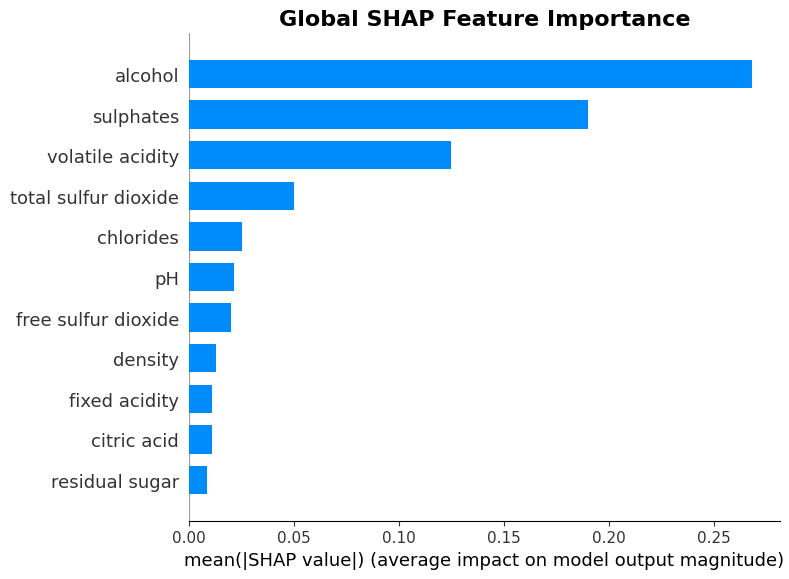

In [112]:
# ============================================================
# Global SHAP Feature Importance (Bar Plot)
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title(
    "Global SHAP Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### **Interpretation**

The Global SHAP Feature Importance plot presents the average absolute SHAP value for each predictor variable, indicating its overall contribution to the Tuned Random Forest Regression model.

Among all physicochemical properties, **alcohol** exhibits the greatest influence on wine quality prediction, followed by **sulphates**, **volatile acidity**, and **total sulfur dioxide**. These variables consistently contribute the most to the model's predictions across the testing dataset.

The remaining variables, including **chlorides**, **pH**, **free sulfur dioxide**, **density**, **fixed acidity**, **citric acid**, and **residual sugar**, have comparatively smaller contributions. Although these variables remain part of the predictive model, their overall influence on wine quality prediction is relatively limited.

The SHAP rankings closely align with the Random Forest feature importance obtained during model development, providing additional confidence in the robustness and consistency of the selected model.


### **Key Findings**

- Alcohol is the most influential predictor of wine quality in the selected Tuned Random Forest Regression model.

- Sulphates and volatile acidity also play significant roles in determining predicted wine quality.

- Total sulfur dioxide contributes moderately to the model predictions, whereas the remaining physicochemical properties have relatively smaller overall influence.

- The SHAP-based feature ranking is consistent with the Random Forest feature importance obtained during model development, indicating stable and reliable model behaviour.

- The agreement between impurity-based feature importance and SHAP explainability strengthens confidence in the selected predictive model.

### **SHAP Summary Plot**

The SHAP Summary Plot provides a global explanation of the Tuned Random Forest Regression model by illustrating both the importance of each predictor variable and the direction of its influence on the predicted wine quality.

Each point in the plot represents an individual observation from the testing dataset. The horizontal position indicates the SHAP value (feature contribution), while the colour represents the actual feature value, with blue indicating lower values and red indicating higher values.

This visualization simultaneously explains feature importance, the direction of influence, and the variability of feature effects across all observations.

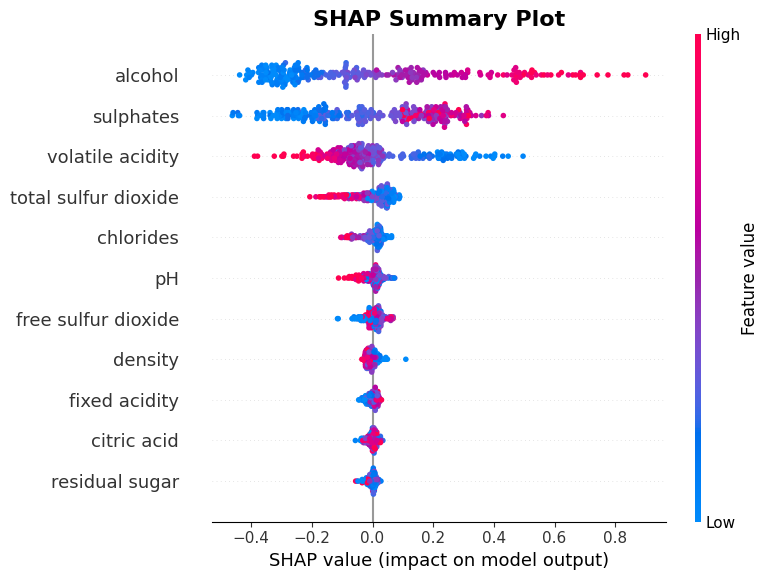

In [113]:
# ============================================================
# SHAP Summary Plot (Beeswarm)
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### **Interpretation**

The SHAP Summary Plot provides a comprehensive overview of how each physicochemical property influences the predictions generated by the Tuned Random Forest Regression model. The horizontal position of each point represents the SHAP value, indicating whether the feature increases or decreases the predicted wine quality, while the colour represents the corresponding feature value.

The plot indicates that **alcohol** is the most influential predictor. Higher alcohol values (red points) are generally associated with positive SHAP values, indicating an increase in the predicted wine quality. Conversely, lower alcohol values (blue points) tend to contribute negatively to the predictions.

Similarly, higher values of **sulphates** generally contribute positively to the predicted wine quality, whereas lower sulphate concentrations tend to reduce the predicted quality.

For **volatile acidity**, the relationship is reversed. Higher volatile acidity values predominantly produce negative SHAP values, indicating that increasing volatile acidity decreases the predicted wine quality. Lower volatile acidity values generally contribute positively to the model predictions.

The remaining variables, including **total sulfur dioxide**, **chlorides**, **pH**, **free sulfur dioxide**, **density**, **fixed acidity**, **citric acid**, and **residual sugar**, exhibit comparatively smaller SHAP magnitudes, indicating that their influence on wine quality prediction is relatively limited within the selected model.

Overall, the SHAP Summary Plot demonstrates that the Tuned Random Forest Regression model captures meaningful relationships between physicochemical properties and wine quality while providing transparent explanations for its predictions.

### **Key Findings**

- Alcohol is the strongest contributor to wine quality prediction, with higher alcohol concentrations generally increasing the predicted quality.

- Higher sulphate concentrations positively influence wine quality predictions, making sulphates the second most influential feature.

- Higher volatile acidity consistently reduces the predicted wine quality, confirming its negative impact on wine quality assessment.

- Total sulfur dioxide exhibits a moderate influence, while the remaining physicochemical properties contribute comparatively less to the model predictions.

- The SHAP Summary Plot confirms both the importance and the direction of influence of the predictor variables, providing greater transparency than traditional feature importance measures.

- The explainability results are consistent with the feature importance rankings obtained during model development, strengthening confidence in the robustness and reliability of the selected Tuned Random Forest Regression model.

<Figure size 800x600 with 0 Axes>

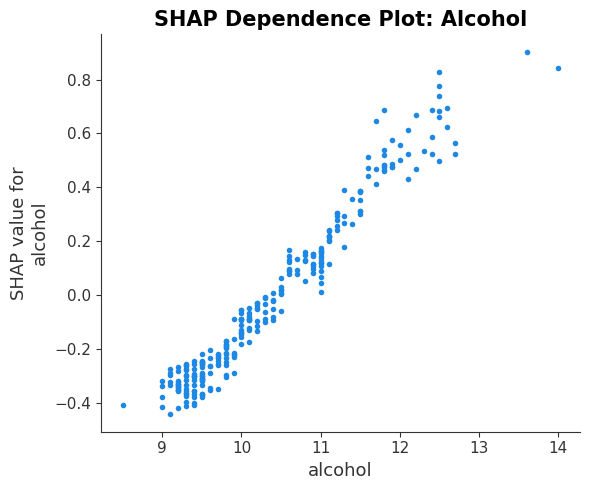

<Figure size 800x600 with 0 Axes>

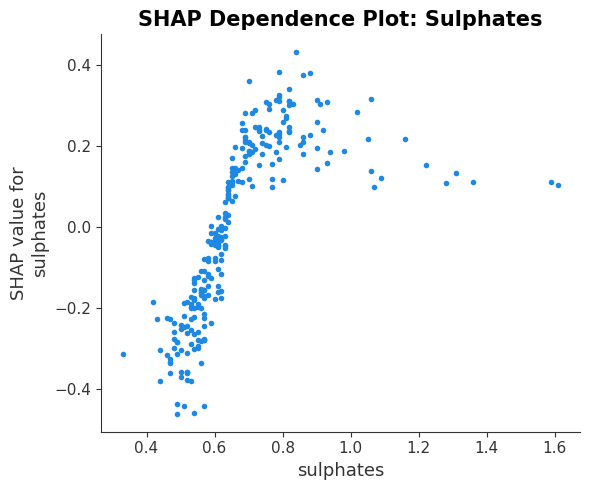

<Figure size 800x600 with 0 Axes>

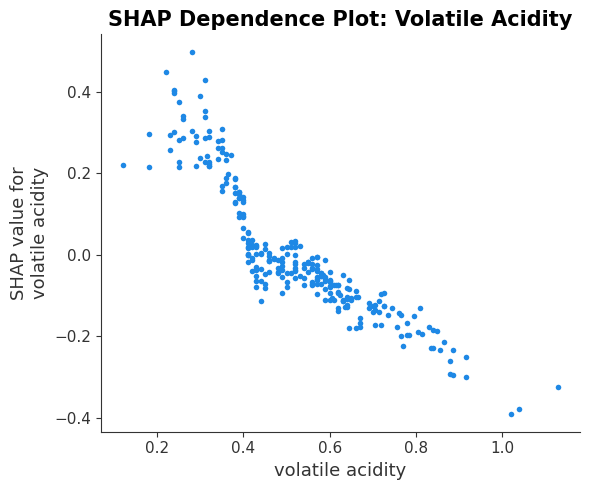

<Figure size 800x600 with 0 Axes>

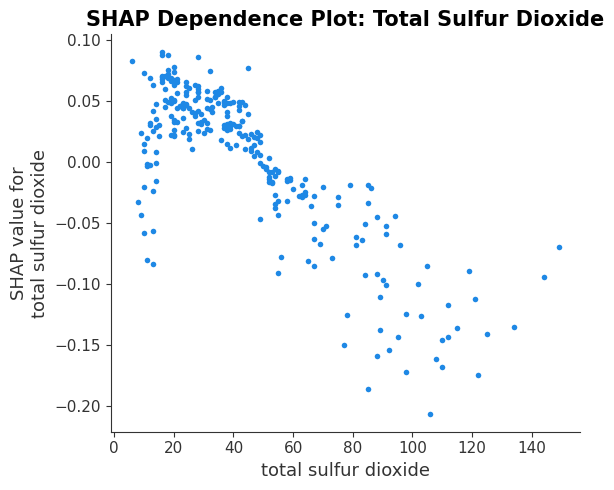

In [114]:
# ============================================================
# SHAP Dependence Plots for Top Features
# ============================================================

top_features = [
    "alcohol",
    "sulphates",
    "volatile acidity",
    "total sulfur dioxide"
]

for feature in top_features:

    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index=None,
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot: {feature.title()}",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

### **SHAP Dependence Analysis: Volatile Acidity**

The SHAP dependence plot for **volatile acidity** demonstrates a strong negative relationship with the predicted wine quality. Lower volatile acidity values are associated with positive SHAP values, indicating that they increase the predicted wine quality. In contrast, higher volatile acidity values consistently produce negative SHAP values, reducing the model's predicted quality.

The relationship appears approximately monotonic, suggesting that increasing volatile acidity progressively decreases wine quality predictions. This indicates that volatile acidity is one of the most influential negative predictors in the selected Random Forest model.

The relatively smooth pattern of SHAP values also suggests that the model has learned a stable and consistent relationship between volatile acidity and wine quality across the testing dataset.

### **SHAP Dependence Analysis: Total Sulfur Dioxide**

The SHAP dependence plot for **total sulfur dioxide** indicates that lower to moderate concentrations generally contribute positively to the predicted wine quality. As total sulfur dioxide increases, the SHAP values gradually decrease, indicating a reduction in the predicted quality.

The transition around the mid-range values suggests that moderate concentrations have relatively limited influence, whereas higher concentrations increasingly contribute negatively to the model predictions.

Although total sulfur dioxide is less influential than alcohol, sulphates, and volatile acidity, the dependence plot demonstrates a consistent negative trend at higher concentrations, indicating that excessive sulfur dioxide is associated with lower predicted wine quality.

### **Key Findings**

- The SHAP dependence plots reveal clear and interpretable relationships between physicochemical properties and predicted wine quality.

- Increasing **volatile acidity** consistently decreases the predicted wine quality, confirming its role as one of the strongest negative predictors in the model.

- Moderate levels of **total sulfur dioxide** have relatively limited impact, whereas higher concentrations progressively reduce the predicted wine quality.

- The smooth and consistent SHAP patterns indicate that the Tuned Random Forest Regression model has captured stable relationships between these physicochemical properties and wine quality rather than relying on isolated observations.

- These findings reinforce the conclusions obtained from the SHAP Summary Plot and further demonstrate the transparency and interpretability of the selected predictive model.

## **5.4 SHAP Waterfall Plot**

While the SHAP summary plot provides a global explanation of feature importance across the entire dataset, the SHAP waterfall plot explains the prediction for an individual wine sample.

The plot illustrates how each physicochemical property contributes either positively or negatively towards the final predicted wine quality, thereby improving the transparency and interpretability of the Random Forest model.

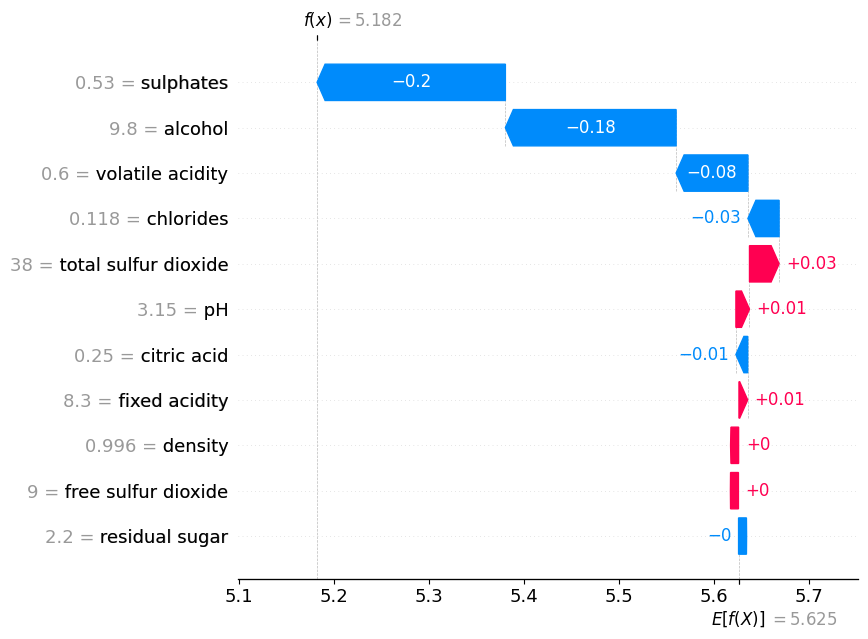

In [115]:
# ============================================================
# SHAP Waterfall Plot for One Test Observation
# ============================================================

sample_index = 0

shap_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_index],
    feature_names=X_test.columns
)

shap.plots.waterfall(
    shap_explanation,
    max_display=11
)

### **Interpretation**

The SHAP Waterfall Plot explains the prediction for a single wine sample by illustrating how each physicochemical property contributes to the final predicted wine quality.

For the selected observation, the model's baseline prediction is **5.625**, which is adjusted by the contributions of individual features to produce a final prediction of approximately **5.182**.

The largest negative contributions originate from **sulphates (-0.20)**, **alcohol (-0.18)**, and **volatile acidity (-0.08)**. These feature values reduce the predicted wine quality relative to the model's baseline expectation.

Conversely, **total sulfur dioxide (+0.03)**, **pH (+0.01)**, and **fixed acidity (+0.01)** contribute positively to the prediction, although their influence is considerably smaller.

Overall, the waterfall plot demonstrates how SHAP decomposes an individual prediction into feature-level contributions, providing transparency into the reasoning behind the model's output for a specific wine sample.

### **Key Findings**

- The SHAP Waterfall Plot provides a local explanation for an individual wine quality prediction.

- The prediction is obtained by combining the model's baseline expectation with the positive and negative contributions of each physicochemical property.

- For the selected observation, sulphates, alcohol, and volatile acidity produced the largest negative contributions, resulting in a predicted wine quality below the model's baseline prediction.

- The waterfall plot complements the global SHAP analyses by demonstrating how feature contributions vary for individual observations while maintaining model transparency.

In [116]:
# ============================================================
# Actual and Predicted Values for Selected Observation
# ============================================================

actual_quality = y_test.iloc[sample_index]
predicted_quality = tuned_random_forest.predict(
    X_test.iloc[[sample_index]]
)[0]

print(f"Selected test observation : {sample_index}")
print(f"Actual wine quality       : {actual_quality:.2f}")
print(f"Predicted wine quality    : {predicted_quality:.2f}")

Selected test observation : 0
Actual wine quality       : 5.00
Predicted wine quality    : 5.18


### **Prediction Summary**

The selected testing observation has an **actual wine quality score of 5.00**, while the Tuned Random Forest Regression model predicted a quality score of **5.18**. The prediction error for this observation is relatively small (**0.18 quality units**), indicating that the model provides a close approximation of the observed wine quality.

The SHAP Waterfall Plot explains how the individual physicochemical properties contributed to this prediction by showing the positive and negative influence of each feature relative to the model's baseline prediction.

### **Interpretation**

The SHAP Waterfall Plot provides a local explanation for the prediction of a single wine sample. For the selected observation, the model predicted a wine quality score of **5.18**, compared with the actual observed quality score of **5.00**, demonstrating a relatively small prediction error.

The model begins with a baseline prediction (**E[f(X)] = 5.625**), representing the average prediction across the training data. Individual physicochemical properties then adjust this baseline upward or downward to produce the final prediction.

For this observation, **sulphates (-0.20)**, **alcohol (-0.18)**, **volatile acidity (-0.08)**, and **chlorides (-0.03)** contributed most strongly toward lowering the predicted wine quality relative to the baseline expectation.

Conversely, **total sulfur dioxide (+0.03)**, **pH (+0.01)**, and **fixed acidity (+0.01)** provided smaller positive contributions that partially offset the negative effects.

Overall, the combined influence of all predictor variables reduced the baseline prediction from **5.625** to a final predicted quality of **5.182**, illustrating how SHAP decomposes an individual prediction into interpretable feature-level contributions.

### **Key Findings**

- The Tuned Random Forest Regression model predicted a wine quality score of **5.18** for the selected observation, compared with the actual quality score of **5.00**, demonstrating a relatively small prediction error.

- SHAP successfully decomposed the prediction into individual feature contributions, providing a transparent explanation of how the final prediction was obtained.

- Sulphates, alcohol, volatile acidity, and chlorides produced the largest negative contributions for this observation, while total sulfur dioxide, pH, and fixed acidity contributed positively.

- The waterfall plot complements the global SHAP analyses by demonstrating how individual physicochemical properties collectively influence a specific wine quality prediction.

# **6. Research Questions and Findings**

### **Research Question 1**

**RQ1. Which physicochemical properties significantly influence wine quality?**

The exploratory data analysis, Random Forest feature importance, and SHAP explainability analyses consistently identified **alcohol**, **sulphates**, **volatile acidity**, and **total sulfur dioxide** as the most influential physicochemical properties affecting wine quality prediction.

The SHAP Summary Plot further demonstrated that higher alcohol and sulphate concentrations generally increase the predicted wine quality, whereas higher volatile acidity consistently decreases the predicted quality. Total sulfur dioxide exhibited a moderate influence, with higher concentrations generally contributing negatively to the predictions.

The consistency between correlation analysis, feature importance, and SHAP explainability provides strong evidence that these physicochemical properties play a significant role in determining wine quality.

**Conclusion**

Alcohol, sulphates, volatile acidity, and total sulfur dioxide were identified as the most significant physicochemical properties influencing wine quality, with alcohol emerging as the strongest predictor.

### **Research Question 2**

**RQ2. How accurately can machine learning regression models predict wine quality using physicochemical properties?**

Five regression algorithms were developed and evaluated using training performance, independent testing performance, and five-fold cross-validation. The models demonstrated varying levels of predictive capability.

Among the optimized models, Test R² values ranged from **0.2843** (Tuned Decision Tree) to **0.4090** (Tuned Gradient Boosting), while Test RMSE values ranged from **0.6296** to **0.6929**. These results indicate that physicochemical properties can successfully predict wine quality with moderate predictive accuracy.

The use of cross-validation confirmed that the optimized ensemble learning models generalized consistently to unseen observations.

**Conclusion**

Machine learning regression models were able to predict wine quality with moderate accuracy using physicochemical properties alone, demonstrating that these variables provide meaningful predictive information.

### **Research Question 3**

**RQ3. Which machine learning regression model provides the best predictive performance for wine quality prediction?**

Five baseline regression models were initially developed, followed by hyperparameter optimization using RandomizedSearchCV.

The optimized Gradient Boosting model achieved the highest independent testing performance (**Test R² = 0.4090**, **Test RMSE = 0.6296**). However, the optimized Random Forest model demonstrated the strongest cross-validation performance (**CV R² = 0.3945**, **CV RMSE = 0.6372**), indicating greater model stability and generalization.

Considering predictive accuracy, cross-validation performance, resistance to overfitting, and interpretability, the **Tuned Random Forest Regression** model was selected as the final predictive model.

**Conclusion**

Although Tuned Gradient Boosting achieved the highest testing accuracy, the Tuned Random Forest Regression model provided the best overall balance between predictive performance, robustness, and interpretability, making it the preferred model for this study.

### **Research Question 4**

**RQ4. Which physicochemical properties contribute the most to the predictive performance of the best-performing machine learning model?**

SHAP explainability analysis was performed using the selected Tuned Random Forest Regression model to quantify the contribution of each predictor variable.

The SHAP Global Feature Importance and Summary Plot consistently identified **alcohol**, **sulphates**, **volatile acidity**, and **total sulfur dioxide** as the most influential contributors to the model's predictions.

The dependence plots further demonstrated that higher alcohol and sulphate concentrations generally increased the predicted wine quality, whereas higher volatile acidity reduced the predicted quality. Total sulfur dioxide exhibited a moderate negative influence at higher concentrations.

**Conclusion**

Alcohol was identified as the most influential contributor to the predictive performance of the Tuned Random Forest Regression model, followed by sulphates, volatile acidity, and total sulfur dioxide.

# **Overall Research Findings**

The findings of this study demonstrate that physicochemical properties can be effectively used to predict wine quality using machine learning regression techniques. Ensemble learning algorithms consistently outperformed individual decision tree models, with the Tuned Random Forest Regression model providing the best balance of predictive accuracy, generalization, and interpretability.

SHAP explainability analysis revealed that alcohol, sulphates, volatile acidity, and total sulfur dioxide are the most influential predictors of wine quality. These findings not only improve the transparency of the predictive model but also provide practical insights that can support data-driven quality assessment and decision-making within the wine industry.

# **7. Discussion**

## **Introduction**

This chapter discusses the findings obtained from the exploratory data analysis, machine learning model development, hyperparameter optimization, and SHAP explainability analysis. The results are interpreted in relation to the research questions, previous studies, and their practical implications for wine quality prediction.

## **Model Performance**

The experimental results demonstrate that ensemble learning algorithms consistently outperformed the individual Linear Regression and Decision Tree Regression models. Hyperparameter optimization further improved the predictive performance and generalization capability of most regression models.

Among the optimized models, Gradient Boosting achieved the highest testing performance, whereas the Tuned Random Forest Regression model demonstrated the strongest cross-validation performance and overall robustness. Consequently, the Tuned Random Forest model was selected as the final predictive model due to its balanced performance, stability, and explainability.

These findings indicate that ensemble learning techniques are well suited for modelling the complex, non-linear relationships between physicochemical properties and wine quality.

## **Model Explainability**

The SHAP analysis significantly enhanced the transparency of the selected Random Forest model by quantifying the contribution of each physicochemical property toward wine quality prediction.

Alcohol, sulphates, volatile acidity, and total sulfur dioxide consistently emerged as the most influential variables across the SHAP Global Feature Importance, Summary Plot, and Dependence Plot analyses.

The explainability results demonstrated that higher alcohol and sulphate concentrations generally increase predicted wine quality, whereas higher volatile acidity consistently decreases the predicted quality. These findings improve confidence in the predictive model by providing interpretable evidence supporting its decision-making process.

## **Practical Implications**

The findings of this study have several practical implications for wineries, quality control laboratories, and wine manufacturers.

The developed machine learning model can support rapid quality assessment by identifying wines that are likely to receive lower quality ratings before extensive sensory evaluation. This enables manufacturers to prioritize quality inspections and optimize production processes more efficiently.

The SHAP explainability analysis further assists decision-makers by identifying the physicochemical properties that have the greatest influence on predicted wine quality. Such insights may support process optimization, quality improvement initiatives, and evidence-based production decisions while enhancing trust in machine learning-assisted quality assessment.

# **8. Limitations**

This study has several limitations that should be considered when interpreting the findings.

- The analysis was conducted using a single publicly available UCI Red Wine Quality dataset.

- The findings may not generalize directly to white wines or wines produced under different environmental and production conditions.

- Only physicochemical properties were considered, while sensory evaluation, production practices, grape variety, and climatic factors were not included.

- The dataset contains a moderate number of observations, which may limit the complexity of relationships that can be learned.

- External validation using independent industrial datasets was beyond the scope of this study.

# **9. Future Work**

Future research may extend this work by:

- Evaluating larger and more diverse wine quality datasets.

- Incorporating white wine datasets for broader generalization.

- Comparing additional ensemble learning algorithms such as CatBoost and LightGBM.

- Investigating deep learning approaches for wine quality prediction.

- Integrating sensory evaluation and production variables with physicochemical properties.

- Developing real-time quality prediction systems for industrial wine production environments.

- Exploring additional explainable AI techniques alongside SHAP.

# **10. Conclusion**

This study investigated the application of machine learning regression techniques for predicting wine quality using physicochemical properties obtained from the UCI Wine Quality dataset.

Five regression algorithms were developed and systematically evaluated using training performance, testing performance, five-fold cross-validation, and hyperparameter optimization. Although the Tuned Gradient Boosting model achieved the highest testing performance, the Tuned Random Forest Regression model demonstrated the strongest balance between predictive performance, generalization capability, and model interpretability, leading to its selection as the final predictive model.

SHAP explainability analysis identified alcohol, sulphates, volatile acidity, and total sulfur dioxide as the most influential predictors of wine quality. The explainability results enhanced the transparency of the predictive model and provided valuable insights into how individual physicochemical properties influence wine quality predictions.

Overall, the findings demonstrate that machine learning combined with explainable artificial intelligence provides an effective and transparent approach for supporting wine quality assessment and decision-making within the wine industry.